In [1]:
import pandas as pd
import numpy as np

In [2]:
movies = pd.read_csv('./data/movie_tags_cleaned.csv')
ratings = pd.read_csv('./data/ratings_cleaned.csv')

In [3]:
ratings

,userId,movieId,title,tmdbId,rating,timestamp
0,1,804,She's the One (1996),11363,4.0,964980499
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499
2,1,2018,Bambi (1942),3170,5.0,964980523
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523
...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405


In [4]:
movies

,movieId,title,genres,tmdbId,tag,overview,director,actors,avg_rating,count_rating
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,862,pixar pixar fun,"Led by Woody, Andy's toys live happily in his ...",John Lasseter,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",3.920930,215
1,2,Jumanji (1995),Adventure Children Fantasy,8844,fantasy magic board game Robin Williams game,When siblings Judy and Peter discover an encha...,Joe Johnston,"Robin Williams, Kirsten Dunst, Bradley Pierce,...",3.431818,110
2,3,Grumpier Old Men (1995),Comedy Romance,15602,moldy old,A family wedding reignites the ancient feud be...,Howard Deutch,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",3.259615,52
3,4,Waiting to Exhale (1995),Comedy Drama Romance,31357,NaN,"Cheated on, mistreated and stepped on, the wom...",Forest Whitaker,"Whitney Houston, Angela Bassett, Loretta Devin...",2.357143,7
4,5,Father of the Bride Part II (1995),Comedy,11862,pregnancy remake,Just when George Banks has recovered from his ...,Charles Shyer,"Steve Martin, Diane Keaton, Martin Short, Kimb...",3.071429,49
...,...,...,...,...,...,...,...,...,...,...
9741,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy,432131,NaN,"Ciel learns of a ""Aurora Society"", that is rum...",Noriyuki Abe,"Daisuke Ono, Maaya Sakamoto, Yukari Tamura, Ju...",4.000000,1
9742,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy,445030,NaN,Six thousand years before Sora and Shiro were ...,Atsuko Ishizuka,"Yoko Hikasa, Ai Kayano, Yoshitsugu Matsuoka, K...",3.500000,1
9743,193585,Flint (2017),Drama,479308,NaN,A woman deals with the toxic water scandal in ...,Bruce Beresford,"Queen Latifah, Betsy Brandt, Rob Morrow, Marin...",3.500000,1
9744,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation,483455,NaN,A large scale catastrophe is occurring across ...,Takuya Igarashi,"Kensho Ono, Mamoru Miyano, Kisho Taniyama, Yut...",3.500000,1


In [5]:
movies.fillna('', inplace=True)
movies.isna().sum()

movieId         0
title           0
genres          0
tmdbId          0
tag             0
overview        0
director        0
actors          0
avg_rating      0
count_rating    0
dtype: int64

In [6]:
# Now we will combine genre & tag
movies['Tags'] = movies['genres'] + ' ' + movies['tag']
movies.drop(['genres', 'tag'], axis=1, inplace=True)
movies

,movieId,title,tmdbId,overview,director,actors,avg_rating,count_rating,Tags
0,1,Toy Story (1995),862,"Led by Woody, Andy's toys live happily in his ...",John Lasseter,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",3.920930,215,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),8844,When siblings Judy and Peter discover an encha...,Joe Johnston,"Robin Williams, Kirsten Dunst, Bradley Pierce,...",3.431818,110,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),15602,A family wedding reignites the ancient feud be...,Howard Deutch,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",3.259615,52,Comedy Romance moldy old
3,4,Waiting to Exhale (1995),31357,"Cheated on, mistreated and stepped on, the wom...",Forest Whitaker,"Whitney Houston, Angela Bassett, Loretta Devin...",2.357143,7,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),11862,Just when George Banks has recovered from his ...,Charles Shyer,"Steve Martin, Diane Keaton, Martin Short, Kimb...",3.071429,49,Comedy pregnancy remake
...,...,...,...,...,...,...,...,...,...
9741,193581,Black Butler: Book of the Atlantic (2017),432131,"Ciel learns of a ""Aurora Society"", that is rum...",Noriyuki Abe,"Daisuke Ono, Maaya Sakamoto, Yukari Tamura, Ju...",4.000000,1,Action Animation Comedy Fantasy
9742,193583,No Game No Life: Zero (2017),445030,Six thousand years before Sora and Shiro were ...,Atsuko Ishizuka,"Yoko Hikasa, Ai Kayano, Yoshitsugu Matsuoka, K...",3.500000,1,Animation Comedy Fantasy
9743,193585,Flint (2017),479308,A woman deals with the toxic water scandal in ...,Bruce Beresford,"Queen Latifah, Betsy Brandt, Rob Morrow, Marin...",3.500000,1,Drama
9744,193587,Bungo Stray Dogs: Dead Apple (2018),483455,A large scale catastrophe is occurring across ...,Takuya Igarashi,"Kensho Ono, Mamoru Miyano, Kisho Taniyama, Yut...",3.500000,1,Action Animation


In [7]:
# Taking only top 5 actors
movies["actors"] = movies["actors"].apply(
    lambda x: " ".join(''.join(x.strip().split(' ')).split(",")[:5]) if pd.notna(x) else ""
)
movies

,movieId,title,tmdbId,overview,director,actors,avg_rating,count_rating,Tags
0,1,Toy Story (1995),862,"Led by Woody, Andy's toys live happily in his ...",John Lasseter,TomHanks TimAllen DonRickles JimVarney Wallace...,3.920930,215,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),8844,When siblings Judy and Peter discover an encha...,Joe Johnston,RobinWilliams KirstenDunst BradleyPierce Bonni...,3.431818,110,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),15602,A family wedding reignites the ancient feud be...,Howard Deutch,WalterMatthau JackLemmon Ann-Margret SophiaLor...,3.259615,52,Comedy Romance moldy old
3,4,Waiting to Exhale (1995),31357,"Cheated on, mistreated and stepped on, the wom...",Forest Whitaker,WhitneyHouston AngelaBassett LorettaDevine Lel...,2.357143,7,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),11862,Just when George Banks has recovered from his ...,Charles Shyer,SteveMartin DianeKeaton MartinShort KimberlyWi...,3.071429,49,Comedy pregnancy remake
...,...,...,...,...,...,...,...,...,...
9741,193581,Black Butler: Book of the Atlantic (2017),432131,"Ciel learns of a ""Aurora Society"", that is rum...",Noriyuki Abe,DaisukeOno MaayaSakamoto YukariTamura JunichiS...,4.000000,1,Action Animation Comedy Fantasy
9742,193583,No Game No Life: Zero (2017),445030,Six thousand years before Sora and Shiro were ...,Atsuko Ishizuka,YokoHikasa AiKayano YoshitsuguMatsuoka Kazuyuk...,3.500000,1,Animation Comedy Fantasy
9743,193585,Flint (2017),479308,A woman deals with the toxic water scandal in ...,Bruce Beresford,QueenLatifah BetsyBrandt RobMorrow MarinIrelan...,3.500000,1,Drama
9744,193587,Bungo Stray Dogs: Dead Apple (2018),483455,A large scale catastrophe is occurring across ...,Takuya Igarashi,KenshoOno MamoruMiyano KishoTaniyama YutoUemur...,3.500000,1,Action Animation


### We are not going to use POS tagging for lemmetization as our data is just keywords and we don't need semantic meaning or anything. Therefore, we will be using stopwords and stemming(instead of lemmetization).

In [8]:
import re

# Removing punctuations
movies["overview"] = (
    movies["overview"]
        # .str.lower()
        .str.replace(r"[^\w\s]", "", regex=True)
)
movies

,movieId,title,tmdbId,overview,director,actors,avg_rating,count_rating,Tags
0,1,Toy Story (1995),862,Led by Woody Andys toys live happily in his ro...,John Lasseter,TomHanks TimAllen DonRickles JimVarney Wallace...,3.920930,215,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),8844,When siblings Judy and Peter discover an encha...,Joe Johnston,RobinWilliams KirstenDunst BradleyPierce Bonni...,3.431818,110,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),15602,A family wedding reignites the ancient feud be...,Howard Deutch,WalterMatthau JackLemmon Ann-Margret SophiaLor...,3.259615,52,Comedy Romance moldy old
3,4,Waiting to Exhale (1995),31357,Cheated on mistreated and stepped on the women...,Forest Whitaker,WhitneyHouston AngelaBassett LorettaDevine Lel...,2.357143,7,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),11862,Just when George Banks has recovered from his ...,Charles Shyer,SteveMartin DianeKeaton MartinShort KimberlyWi...,3.071429,49,Comedy pregnancy remake
...,...,...,...,...,...,...,...,...,...
9741,193581,Black Butler: Book of the Atlantic (2017),432131,Ciel learns of a Aurora Society that is rumore...,Noriyuki Abe,DaisukeOno MaayaSakamoto YukariTamura JunichiS...,4.000000,1,Action Animation Comedy Fantasy
9742,193583,No Game No Life: Zero (2017),445030,Six thousand years before Sora and Shiro were ...,Atsuko Ishizuka,YokoHikasa AiKayano YoshitsuguMatsuoka Kazuyuk...,3.500000,1,Animation Comedy Fantasy
9743,193585,Flint (2017),479308,A woman deals with the toxic water scandal in ...,Bruce Beresford,QueenLatifah BetsyBrandt RobMorrow MarinIrelan...,3.500000,1,Drama
9744,193587,Bungo Stray Dogs: Dead Apple (2018),483455,A large scale catastrophe is occurring across ...,Takuya Igarashi,KenshoOno MamoruMiyano KishoTaniyama YutoUemur...,3.500000,1,Action Animation


In [9]:
movies['Tags'] = movies['Tags'].apply(lambda x: ' '.join(set(str(x).split())))

In [10]:
# Now we will combine all the features of text: title, overview, director, actors, Tags
movies["content"] = (
    #movies["title"] + " " +      # small influence
    movies["overview"] + " " +
    movies["Tags"] + " " +
    movies["director"] + " " +
    movies["actors"]
)
movies


,movieId,title,tmdbId,overview,director,actors,avg_rating,count_rating,Tags,content
0,1,Toy Story (1995),862,Led by Woody Andys toys live happily in his ro...,John Lasseter,TomHanks TimAllen DonRickles JimVarney Wallace...,3.920930,215,Animation Fantasy pixar Adventure Children fun...,Led by Woody Andys toys live happily in his ro...
1,2,Jumanji (1995),8844,When siblings Judy and Peter discover an encha...,Joe Johnston,RobinWilliams KirstenDunst BradleyPierce Bonni...,3.431818,110,fantasy magic Williams Fantasy board Robin Adv...,When siblings Judy and Peter discover an encha...
2,3,Grumpier Old Men (1995),15602,A family wedding reignites the ancient feud be...,Howard Deutch,WalterMatthau JackLemmon Ann-Margret SophiaLor...,3.259615,52,old moldy Comedy Romance,A family wedding reignites the ancient feud be...
3,4,Waiting to Exhale (1995),31357,Cheated on mistreated and stepped on the women...,Forest Whitaker,WhitneyHouston AngelaBassett LorettaDevine Lel...,2.357143,7,Romance Comedy Drama,Cheated on mistreated and stepped on the women...
4,5,Father of the Bride Part II (1995),11862,Just when George Banks has recovered from his ...,Charles Shyer,SteveMartin DianeKeaton MartinShort KimberlyWi...,3.071429,49,remake pregnancy Comedy,Just when George Banks has recovered from his ...
...,...,...,...,...,...,...,...,...,...,...
9741,193581,Black Butler: Book of the Atlantic (2017),432131,Ciel learns of a Aurora Society that is rumore...,Noriyuki Abe,DaisukeOno MaayaSakamoto YukariTamura JunichiS...,4.000000,1,Action Fantasy Comedy Animation,Ciel learns of a Aurora Society that is rumore...
9742,193583,No Game No Life: Zero (2017),445030,Six thousand years before Sora and Shiro were ...,Atsuko Ishizuka,YokoHikasa AiKayano YoshitsuguMatsuoka Kazuyuk...,3.500000,1,Animation Fantasy Comedy,Six thousand years before Sora and Shiro were ...
9743,193585,Flint (2017),479308,A woman deals with the toxic water scandal in ...,Bruce Beresford,QueenLatifah BetsyBrandt RobMorrow MarinIrelan...,3.500000,1,Drama,A woman deals with the toxic water scandal in ...
9744,193587,Bungo Stray Dogs: Dead Apple (2018),483455,A large scale catastrophe is occurring across ...,Takuya Igarashi,KenshoOno MamoruMiyano KishoTaniyama YutoUemur...,3.500000,1,Action Animation,A large scale catastrophe is occurring across ...


In [11]:
df = movies.drop(['overview', 'director', 'actors', 'Tags'], axis=1)
df.content.iloc[0]

'Led by Woody Andys toys live happily in his room until Andys birthday brings Buzz Lightyear onto the scene Afraid of losing his place in Andys heart Woody plots against Buzz But when circumstances separate Buzz and Woody from their owner the duo eventually learns to put aside their differences Animation Fantasy pixar Adventure Children fun Comedy John Lasseter TomHanks TimAllen DonRickles JimVarney WallaceShawn'

### Our objective is to convert words into vectors which are close in vector space

For that we will be using word2vec/tfidf to convert words into vectors which are close in vector space

In [12]:
#%pip install "numpy<2"

In [13]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources (Run once) in a python environment
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

/home/deva/anaconda3/envs/ML/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [14]:
def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # 4. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 6. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 7. Remove special characters (keep only alphabets and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 9. Tokenization
    tokens = word_tokenize(text)

    # 10. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 11. Lemmatization
    tokens = [lemmatizer.lemmatize(word, 'v') for word in tokens]
    
    # 12. Join back into sentence (optional) For TF-IDF / CountVectorizer (scikit-learn) → You should keep each row as a cleaned string, not a list of tokens.
    # The vectorizer will handle tokenization internally (TF-IDF / CountVectorizer)
    cleaned_text = " ".join(tokens)     
    
    return cleaned_text

In [15]:
df['clean_text'] = df['content'].apply(preprocess_text)
df

,movieId,title,tmdbId,avg_rating,count_rating,content,clean_text
0,1,Toy Story (1995),862,3.920930,215,Led by Woody Andys toys live happily in his ro...,lead woody andys toy live happily room andys b...
1,2,Jumanji (1995),8844,3.431818,110,When siblings Judy and Peter discover an encha...,siblings judy peter discover enchant board gam...
2,3,Grumpier Old Men (1995),15602,3.259615,52,A family wedding reignites the ancient feud be...,family wed reignite ancient feud nextdoor neig...
3,4,Waiting to Exhale (1995),31357,2.357143,7,Cheated on mistreated and stepped on the women...,cheat mistreat step women hold breath wait elu...
4,5,Father of the Bride Part II (1995),11862,3.071429,49,Just when George Banks has recovered from his ...,george bank recover daughters wed receive news...
...,...,...,...,...,...,...,...
9741,193581,Black Butler: Book of the Atlantic (2017),432131,4.000000,1,Ciel learns of a Aurora Society that is rumore...,ciel learn aurora society rumor research bring...
9742,193583,No Game No Life: Zero (2017),445030,3.500000,1,Six thousand years before Sora and Shiro were ...,six thousand years sora shiro even blink histo...
9743,193585,Flint (2017),479308,3.500000,1,A woman deals with the toxic water scandal in ...,woman deal toxic water scandal flint michigan ...
9744,193587,Bungo Stray Dogs: Dead Apple (2018),483455,3.500000,1,A large scale catastrophe is occurring across ...,large scale catastrophe occur across planet ab...


#### Text is cleaned, our next step is to convert it cleaned text into vectors

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [17]:
tfidf = TfidfVectorizer(max_features=10000)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])
tfidf_matrix.shape

(9746, 10000)

In [18]:
simTfidf = cosine_similarity(tfidf_matrix)
simTfidf.shape

(9746, 9746)

In [19]:
def recommend(movie_title, similarity, k=10):
    
    # Get movie index
    idx = df[df['title'] == movie_title].index[0]
    
    # Get similarity scores
    sim_scores = list(enumerate(similarity[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top 10 similar movies (excluding itself)
    sim_scores = sim_scores[1:k+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return df['title'].iloc[movie_indices]

In [20]:
recommend('Jumanji (1995)', simTfidf)

8031                         Indie Game: The Movie (2012)
8022                                Wreck-It Ralph (2012)
9640                Jumanji: Welcome to the Jungle (2017)
7934                                   Geri's Game (1997)
7238    Asterix at the Olympic Games (Astérix aux jeux...
9569                            Gulliver's Travels (1996)
559                                      Space Jam (1996)
5258                         Last Starfighter, The (1984)
9621     Sword Art Online The Movie: Ordinal Scale (2017)
9170                North Pole: Open For Christmas (2015)
Name: title, dtype: object

In [21]:
# %pip install sentence-transformers
# %pip install gensim

In [22]:
# %pip install --upgrade tensorflow
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [23]:
for j in [5]:

    tagged_data = [
        TaggedDocument(words=text.split(), tags=[str(i)])
        for i, text in enumerate(df['clean_text'])
    ]

    doc2vec_model = Doc2Vec(
        tagged_data,
        vector_size=200,
        window=5,
        min_count=1,
        workers=4,
        epochs=40
    )

    movie_D2V = np.array([
        doc2vec_model.dv[str(i)]
        for i in range(len(df))
    ])

    simD2V = cosine_similarity(movie_D2V)
    simD2V.shape
    print(j)
    print(recommend('Jumanji (1995)', simD2V))
    print('=======================================================')

5
9640                Jumanji: Welcome to the Jungle (2017)
3926                                    Blue Crush (2002)
8675             Stuart Little 3: Call of the Wild (2005)
2220                              Blue Lagoon, The (1980)
2102                                 Problem Child (1990)
7928    Dragon Ball Z: Bojack Unbound (Doragon bôru Z ...
3566                                Monsters, Inc. (2001)
9626              The Night Is Short, Walk on Girl (2017)
7369                   South Park: Imaginationland (2008)
4149         My Neighbor Totoro (Tonari no Totoro) (1988)
Name: title, dtype: object


In [24]:
recommend('Jumanji (1995)', simD2V)

9640                Jumanji: Welcome to the Jungle (2017)
3926                                    Blue Crush (2002)
8675             Stuart Little 3: Call of the Wild (2005)
2220                              Blue Lagoon, The (1980)
2102                                 Problem Child (1990)
7928    Dragon Ball Z: Bojack Unbound (Doragon bôru Z ...
3566                                Monsters, Inc. (2001)
9626              The Night Is Short, Walk on Girl (2017)
7369                   South Park: Imaginationland (2008)
4149         My Neighbor Totoro (Tonari no Totoro) (1988)
Name: title, dtype: object

In [25]:
from gensim.models import Word2Vec
import numpy as np

tokenized_text = df['clean_text'].apply(lambda x: x.split())

vc = 200
w2v_model = Word2Vec(
    sentences=tokenized_text,
    vector_size=vc,
    window=5,
    min_count=1,
    workers=4,
    epochs=20,
    
)

In [26]:
def get_movie_vector(tokens, model, vector_size):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)

movie_w2v = np.array([
    get_movie_vector(tokens, w2v_model, vc)
    for tokens in tokenized_text
])

simW2V = cosine_similarity(movie_w2v)
simW2V.shape

(9746, 9746)

In [27]:
a

NameError: name 'a' is not defined

In [ ]:
movie_evals = {
    # 1. Historical Sports Epic / Cricket
    "Lagaan: Once Upon a Time in India (2001)": [
        "Dangal (2016)", "Chak De! India (2007)", "Bhaag Milkha Bhaag (2013)", 
        "M.S. Dhoni: The Untold Story (2016)", "Iqbal (2005)", "Swades (2004)", 
        "Jo Jeeta Wohi Sikandar (1992)", "Mary Kom (2014)", "Jodhaa Akbar (2008)", "Gold (2018)"
    ],
    
    # 2. Musical Romance / Drama
    "La La Land (2016)": [
        "Singin' in the Rain (1952)", "A Star Is Born (2018)", "Whiplash (2014)", 
        "The Umbrellas of Cherbourg (1964)", "Moulin Rouge! (2001)", "Once (2007)", 
        "500 Days of Summer (2009)", "Chicago (2002)", "West Side Story (2021)", "Tick, Tick... Boom! (2021)"
    ],
    
    # 3. Mafia / Crime Epic
    "The Godfather Trilogy: 1972-1990 (1992)": [
        "The Godfather: Part II (1974)", "Goodfellas (1990)", "Casino (1995)", 
        "Scarface (1983)", "The Irishman (2019)", "Once Upon a Time in America (1984)", 
        "Donnie Brasco (1997)", "The Departed (2006)", "A Bronx Tale (1993)", "Carlito's Way (1993)"
    ],
    
    # 4. Animated Fantasy / Adventure
    "Spirited Away (Sen to Chihiro no kamikakushi) (2001)": [
        "My Neighbor Totoro (1988)", "Howl's Moving Castle (2004)", "Princess Mononoke (1997)", 
        "Kiki's Delivery Service (1989)", "Ponyo (2008)", "Grave of the Fireflies (1988)", 
        "Your Name. (2016)", "Weathering with You (2019)", "Wolf Children (2012)", "Castle in the Sky (1986)"
    ],
    
    # 5. Social / Psychological Horror
    "Get Out (2017)": [
        "Us (2019)", "Nope (2022)", "The Stepford Wives (1975)", 
        "Rosemary's Baby (1968)", "Midsommar (2019)", "Hereditary (2018)", 
        "It Follows (2014)", "The Invisible Man (2020)", "Sorry to Bother You (2018)", "The Babadook (2014)"
    ],
    
    # 6. Stylized Comedy / Quirky Adventure
    # "The Grand Budapest Hotel (2014)": [
    #     "The Royal Tenenbaums (2001)", "Moonrise Kingdom (2012)", "The French Dispatch (2021)", 
    #     "Fantastic Mr. Fox (2009)", "Isle of Dogs (2018)", "Amélie (2001)", 
    #     "Jojo Rabbit (2019)", "O Brother, Where Art Thou? (2000)", "Paddington 2 (2017)", "The Life Aquatic with Steve Zissou (2004)"
    # ],
    
    # 7. Modern Whodunit / Ensemble Mystery
    # "Knives Out (2019)": [
    #     "Glass Onion (2022)", "Murder on the Orient Express (2017)", "Death on the Nile (2022)", 
    #     "Clue (1985)", "Gosford Park (2001)", "Bad Times at the El Royale (2018)", 
    #     "Crooked House (2017)", "See How They Run (2022)", "A Haunting in Venice (2023)", "The Hateful Eight (2015)"
    # ],
    
    # 8. WWII / Gritty War Drama
    "Saving Private Ryan (1998)": [
        "1917 (2019)", "Dunkirk (2017)", "Hacksaw Ridge (2016)", 
        "Fury (2014)", "The Thin Red Line (1998)", "Black Hawk Down (2001)", 
        "Platoon (1986)", "Full Metal Jacket (1987)", "Letters from Iwo Jima (2006)", "Enemy at the Gates (2001)"
    ],
    
    # 9. High Fantasy Epic
    # "The Lord of the Rings: The Fellowship of the Ring (2001)": [
    #     "The Lord of the Rings: The Two Towers (2002)", "The Lord of the Rings: The Return of the King (2003)", 
    #     "The Hobbit: An Unexpected Journey (2012)", "The Hobbit: The Desolation of Smaug (2013)", 
    #     "The Chronicles of Narnia: The Lion, the Witch and the Wardrobe (2005)", "Harry Potter and the Sorcerer's Stone (2001)", 
    #     "Willow (1988)", "The Princess Bride (1987)", "Pan's Labyrinth (2006)", "Stardust (2007)"
    # ],
    
    # 10. Gritty Superhero / Crime Thriller
    "Batman Begins (2005)": [
        "Batman Begins (2005)", "The Dark Knight Rises (2012)", "Heat (1995)", 
        "Se7en (1995)", "Joker (2019)", "Logan (2017)", 
        "The Batman (2022)", "Skyfall (2012)", "V for Vendetta (2005)", "Prisoners (2013)"
    ]
}

In [ ]:
import re

# 1. Your input dictionary
movie_evals = {
    "Lagaan: Once Upon a Time in India (2001)": [
        "Dangal (2016)", "Chak De! India (2007)", "Bhaag Milkha Bhaag (2013)", 
        "M.S. Dhoni: The Untold Story (2016)", "Iqbal (2005)", "Swades (2004)", 
        "Jo Jeeta Wohi Sikandar (1992)", "Mary Kom (2014)", "Jodhaa Akbar (2008)", "Gold (2018)"
    ],
    "La La Land (2016)": [
        "Singin' in the Rain (1952)", "A Star Is Born (2018)", "Whiplash (2014)", 
        "The Umbrellas of Cherbourg (1964)", "Moulin Rouge! (2001)", "Once (2007)", 
        "500 Days of Summer (2009)", "Chicago (2002)", "West Side Story (2021)", "Tick, Tick... Boom! (2021)"
    ],
    "The Godfather Trilogy: 1972-1990 (1992)": [
        "The Godfather: Part II (1974)", "Goodfellas (1990)", "Casino (1995)", 
        "Scarface (1983)", "The Irishman (2019)", "Once Upon a Time in America (1984)", 
        "Donnie Brasco (1997)", "The Departed (2006)", "A Bronx Tale (1993)", "Carlito's Way (1993)"
    ],
    "Spirited Away (Sen to Chihiro no kamikakushi) (2001)": [
        "My Neighbor Totoro (1988)", "Howl's Moving Castle (2004)", "Princess Mononoke (1997)", 
        "Kiki's Delivery Service (1989)", "Ponyo (2008)", "Grave of the Fireflies (1988)", 
        "Your Name. (2016)", "Weathering with You (2019)", "Wolf Children (2012)", "Castle in the Sky (1986)"
    ],
    "Get Out (2017)": [
        "Us (2019)", "Nope (2022)", "The Stepford Wives (1975)", 
        "Rosemary's Baby (1968)", "Midsommar (2019)", "Hereditary (2018)", 
        "It Follows (2014)", "The Invisible Man (2020)", "Sorry to Bother You (2018)", "The Babadook (2014)"
    ],
    "Saving Private Ryan (1998)": [
        "1917 (2019)", "Dunkirk (2017)", "Hacksaw Ridge (2016)", 
        "Fury (2014)", "The Thin Red Line (1998)", "Black Hawk Down (2001)", 
        "Platoon (1986)", "Full Metal Jacket (1987)", "Letters from Iwo Jima (2006)", "Enemy at the Gates (2001)"
    ],
    "Batman Begins (2005)": [
        "Batman Begins (2005)", "The Dark Knight Rises (2012)", "Heat (1995)", 
        "Se7en (1995)", "Joker (2019)", "Logan (2017)", 
        "The Batman (2022)", "Skyfall (2012)", "V for Vendetta (2005)", "Prisoners (2013)"
    ]
}

# 2. Helper function to clean text from trailing years like (2001) or (1972-1990)
def clean_title(title_str):
    # Removes trailing parenthesis containing digits/dashes and whitespace
    cleaned = re.sub(r'\s*\([\d-]+\)\s*$', '', title_str)
    return cleaned.strip()

# 3. Create a mapping dictionary from your DataFrame for rapid lookup
# Considers case-insensitive lookup but retains original casing from df
df_titles_lower = {str(t).lower().strip(): t for t in df['title'].unique()}

def find_exact_df_title(raw_title):
    base_name = clean_title(raw_title)
    
    # Check 1: Try finding it without the year string
    if base_name.lower() in df_titles_lower:
        return df_titles_lower[base_name.lower()]
    
    # Check 2: Try checking with the original raw string (in case df has years in titles)
    if raw_title.lower().strip() in df_titles_lower:
        return df_titles_lower[raw_title.lower().strip()]
        
    # Check 3: Failsafe partial check (looks for containment)
    for lower_df_title, original_df_title in df_titles_lower.items():
        if base_name.lower() in lower_df_title:
            return original_df_title
            
    return None

# 4. Rebuild the evaluation dataset securely
cleaned_movie_evals = {}
missing_movies = []

for target, recommendations in movie_evals.items():
    cleaned_target = find_exact_df_title(target)
    
    if not cleaned_target:
        missing_movies.append(target)
        continue
        
    cleaned_recs = []
    for rec in recommendations:
        exact_rec = find_exact_df_title(rec)
        if exact_rec:
            cleaned_recs.append(exact_rec)
        else:
            missing_movies.append(rec)
            
    # Keep the item if we mapped the target correctly
    cleaned_movie_evals[cleaned_target] = cleaned_recs

# 5. Review missing inventory
print(f"✅ Successfully processed {len(cleaned_movie_evals)} target categories.")
if missing_movies:
    print(f"⚠️ Warning: {len(set(missing_movies))} items could not be matched inside your df['title'] column.")
    print("Sample missing items:", list(set(missing_movies))[:5])
else:
    print("💯 Perfect match! All target titles and recommendations exist inside your dataset.")

# Update your active variable
movie_evals = cleaned_movie_evals
movie_evals

✅ Successfully processed 7 target categories.
⚠️ Warning: 27 items could not be matched inside your df['title'] column.
Sample missing items: ['Jodhaa Akbar (2008)', 'The Stepford Wives (1975)', 'A Star Is Born (2018)', 'Chak De! India (2007)', 'Moulin Rouge! (2001)']


{'Lagaan: Once Upon a Time in India (2001)': ['GoldenEye (1995)'],
 'La La Land (2016)': ["Singin' in the Rain (1952)",
  'Whiplash (2014)',
  'Once Upon a Time... When We Were Colored (1995)',
  'Chicago (2002)',
  'West Side Story (1961)'],
 'The Godfather Trilogy: 1972-1990 (1992)': ['Goodfellas (1990)',
  'Casino (1995)',
  'Scarface (1983)',
  'Kill the Irishman (2011)',
  'Once Upon a Time in America (1984)',
  'Donnie Brasco (1997)',
  "Carlito's Way (1993)"],
 'Spirited Away (Sen to Chihiro no kamikakushi) (2001)': ['My Neighbor Totoro (Tonari no Totoro) (1988)',
  "Howl's Moving Castle (Hauru no ugoku shiro) (2004)",
  'Princess Mononoke (Mononoke-hime) (1997)',
  "Kiki's Delivery Service (Majo no takkyûbin) (1989)",
  'Ponyo (Gake no ue no Ponyo) (2008)',
  'Grave of the Fireflies (Hotaru no haka) (1988)',
  'Your Name. (2016)',
  'Wolf Children (Okami kodomo no ame to yuki) (2012)',
  'Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986)'],
 'Get Out (2017)': ['City of 

In [ ]:
def evaluate_cbf(recommended, relevant, k=10):
    # print(f"Evaluating................{len(relevant)}")
    hits        = set(recommended) & relevant

    p  = len(hits) / len(recommended) if len(recommended) > 0 else 0
    r  = len(hits) / len(relevant)    if len(relevant) > 0    else 0
    f1 = 2 * p * r / (p + r)          if (p + r) > 0          else 0
    dcg  = sum(1/np.log2(i+2) for i, m in enumerate(recommended) if m in relevant)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
    ndcg = dcg/idcg if idcg > 0 else 0

    # print(f'Precision = {np.round(p,4)}, Recall = {np.round(r,4)}, F1 score = {np.round(f1,4)}, NDCG = {ndcg}')
    return p, r, f1, ndcg

In [ ]:
# D2V
from itertools import product

# Initialize an empty list to store tuning records
tuning_results = []

vc_sizes = [100, 200, 300]
windows = [5,8,10]
mincounts = [1,2]
dm_list = [0,1]
epochs = [20,40,60]
for vc, w, mc, dm, epoch in product(vc_sizes, windows, mincounts, dm_list, epochs):
    current_params = {
        "vector_size": vc,
        "windows": w,
        "min_count": mc,
        "dm": dm,
        "epoch": epoch
    }

    doc2vec_model = Doc2Vec(
        tagged_data,
        vector_size=vc,
        window=w,
        min_count=mc,
        workers=4,
        dm=dm,
        epochs=epoch
    )

    movie_D2V = np.array([
        doc2vec_model.dv[str(i)]
        for i in range(len(df))
    ])

    simD2V = cosine_similarity(movie_D2V)

    print(f'vector size = {vc}, windows = {w}, dm = {dm}, min_count = {mc}, epoch = {epoch}')
    p, r, f1, ndcg = 0, 0, 0, 0
    for mov, pos in movie_evals.items():
        # print(mov)
        recs = recommend(mov, simD2V, 10)
        # print(recs)
        ans = evaluate_cbf(recs, set(pos))
        # p.append(ans[0])
        # r.append(ans[1])
        # f1.append(ans[2])
        # ndcg.append(ans[3])
        p += ans[0]
        r += ans[1]
        f1 += ans[2]
        ndcg += ans[3]

    # These are the scores your model calculated for this run
    precision_score = np.round(p/7, 4)
    recall_score = np.round(r/7, 4)
    f1_score = np.round(f1/7, 4)
    ndcg_score = np.round(ndcg/7, 4)
    print('Final scores:: ')
    print(f'Precison = {precision_score}, Recall = {recall_score}, F1-score = {f1_score}, NDCG = {ndcg_score}')

    

    # --- THE TRACKING STEP ---
    # Combine everything into a single dictionary and append it
    run_record = {
        **current_params,  # Unpacks your hyperparameter details
        "Precision": precision_score,
        "Recall": recall_score,
        "F1-score": f1_score,
        "NDCG": ndcg_score
    }
    
    tuning_results.append(run_record)
    print('=============================================================')
    print()

vector size = 100, windows = 5, dm = 0, min_count = 1, epoch = 20
Final scores:: 
Precison = 0.0286, Recall = 0.0317, F1-score = 0.0301, NDCG = 0.0203

vector size = 100, windows = 5, dm = 0, min_count = 1, epoch = 40
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-score = 0.015, NDCG = 0.0145

vector size = 100, windows = 5, dm = 0, min_count = 1, epoch = 60
Final scores:: 
Precison = 0.0, Recall = 0.0, F1-score = 0.0, NDCG = 0.0

vector size = 100, windows = 5, dm = 1, min_count = 1, epoch = 20
Final scores:: 
Precison = 0.0, Recall = 0.0, F1-score = 0.0, NDCG = 0.0

vector size = 100, windows = 5, dm = 1, min_count = 1, epoch = 40
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-score = 0.015, NDCG = 0.013

vector size = 100, windows = 5, dm = 1, min_count = 1, epoch = 60
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-score = 0.015, NDCG = 0.0101

vector size = 100, windows = 5, dm = 0, min_count = 2, epoch = 20
Final scores:: 
Precison = 0.0, Recall = 0.0, F1-s

In [ ]:
# 1. Convert the tracking list into a structured DataFrame
df_results = pd.DataFrame(tuning_results)

print("=== ALL EXPERIMENT RUNS ===")
display(df_results)

print("\n" + "="*60 + "\n")

# 2. Sort the DataFrame to find your best runs
# We sort by NDCG and F1-score descending. You can shift the order of columns inside the list 
# depending on which metric is your highest priority primary driver.
df_sorted = df_results.sort_values(by=["F1-score", "NDCG"], ascending=False).reset_index(drop=True)

print("=== TOP 10 CONFIGURATIONS ===")
display(df_sorted.head(10))

# 3. Securely isolate the single best parameter configuration block
best_run = df_sorted.iloc[0]
print("\n🏆 BEST PARAMETER SET FOUND:")
print(f"• Vector Size: {best_run['vector_size']}")
print(f"• Windows:     {best_run['windows']}")
print(f"• Dm:   {best_run['dm']} (0=CBOW, 1=SG)")
print(f"• Min Count:   {best_run['min_count']}")
print(f"• Epochs:      {best_run['epoch']}")
print(f"👉 Yielding peak NDCG of: {best_run['NDCG']:.4f}")

=== ALL EXPERIMENT RUNS ===


,vector_size,windows,min_count,dm,epoch,Precision,Recall,F1-score,NDCG
0,100,5,1,0,20,0.0286,0.0317,0.0301,0.0203
1,100,5,1,0,40,0.0143,0.0159,0.0150,0.0145
2,100,5,1,0,60,0.0000,0.0000,0.0000,0.0000
3,100,5,1,1,20,0.0000,0.0000,0.0000,0.0000
4,100,5,1,1,40,0.0143,0.0159,0.0150,0.0130
...,...,...,...,...,...,...,...,...,...
103,300,10,2,0,40,0.0143,0.0159,0.0150,0.0168
104,300,10,2,0,60,0.0143,0.0159,0.0150,0.0112
105,300,10,2,1,20,0.0000,0.0000,0.0000,0.0000
106,300,10,2,1,40,0.0143,0.0159,0.0150,0.0336




=== TOP 10 CONFIGURATIONS ===


,vector_size,windows,min_count,dm,epoch,Precision,Recall,F1-score,NDCG
0,200,8,1,0,20,0.0429,0.0476,0.0451,0.0499
1,100,8,1,1,60,0.0286,0.0444,0.0341,0.0293
2,200,10,1,1,20,0.0286,0.0337,0.0309,0.0288
3,300,5,2,1,20,0.0286,0.0337,0.0309,0.0253
4,200,10,2,0,20,0.0286,0.0317,0.0301,0.0242
5,200,10,1,0,20,0.0286,0.0317,0.0301,0.0236
6,100,8,2,1,20,0.0286,0.0317,0.0301,0.0227
7,100,8,1,0,20,0.0286,0.0317,0.0301,0.0217
8,200,5,1,0,20,0.0286,0.0317,0.0301,0.0207
9,100,5,1,0,20,0.0286,0.0317,0.0301,0.0203



🏆 BEST PARAMETER SET FOUND:
• Vector Size: 200.0
• Windows:     8.0
• Dm:   0.0 (0=CBOW, 1=SG)
• Min Count:   1.0
• Epochs:      20.0
👉 Yielding peak NDCG of: 0.0499


In [ ]:
# W2V
from itertools import product

# Initialize an empty list to store tuning records
tuning_results = []

vc_sizes = [50, 100, 200, 300]
windows = [3,5,8,10]
mincounts = [1,2]
sg_list = [0,1]
epochs = [10,20]
for vc, w, mc, sg, epoch in product(vc_sizes, windows, mincounts, sg_list, epochs):
    current_params = {
        "vector_size": vc,
        "windows": w,
        "min_count": mc,
        "sg": sg,
        "epoch": epoch
    }

    w2v_model = Word2Vec(
        sentences=tokenized_text,
        vector_size=vc,
        window=w,
        min_count=mc,
        workers=4,
        sg=sg,
        epochs=epoch
    )

    movie_w2v = np.array([
        get_movie_vector(tokens, w2v_model, vc)
        for tokens in tokenized_text
    ])

    simW2V = cosine_similarity(movie_w2v)

    print(f'vector size = {vc}, windows = {w}, sg = {sg}, min_count = {mc}, epoch = {epoch}')
    p, r, f1, ndcg = 0, 0, 0, 0
    for mov, pos in movie_evals.items():
        # print(mov)
        recs = recommend(mov, simW2V, 10)
        # print(recs)
        ans = evaluate_cbf(recs, set(pos))
        # p.append(ans[0])
        # r.append(ans[1])
        # f1.append(ans[2])
        # ndcg.append(ans[3])
        p += ans[0]
        r += ans[1]
        f1 += ans[2]
        ndcg += ans[3]

    # These are the scores your model calculated for this run
    precision_score = np.round(p/7, 4)
    recall_score = np.round(r/7, 4)
    f1_score = np.round(f1/7, 4)
    ndcg_score = np.round(ndcg/7, 4)
    print('Final scores:: ')
    print(f'Precison = {precision_score}, Recall = {recall_score}, F1-score = {f1_score}, NDCG = {ndcg_score}')

    

    # --- THE TRACKING STEP ---
    # Combine everything into a single dictionary and append it
    run_record = {
        **current_params,  # Unpacks your hyperparameter details
        "Precision": precision_score,
        "Recall": recall_score,
        "F1-score": f1_score,
        "NDCG": ndcg_score
    }
    
    tuning_results.append(run_record)
    print('=============================================================')
    print()

vector size = 50, windows = 3, sg = 0, min_count = 1, epoch = 10
Final scores:: 
Precison = 0.0, Recall = 0.0, F1-score = 0.0, NDCG = 0.0

vector size = 50, windows = 3, sg = 0, min_count = 1, epoch = 20
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-score = 0.015, NDCG = 0.0168

vector size = 50, windows = 3, sg = 1, min_count = 1, epoch = 10
Final scores:: 
Precison = 0.0286, Recall = 0.0337, F1-score = 0.0309, NDCG = 0.0316

vector size = 50, windows = 3, sg = 1, min_count = 1, epoch = 20
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-score = 0.015, NDCG = 0.0168

vector size = 50, windows = 3, sg = 0, min_count = 2, epoch = 10
Final scores:: 
Precison = 0.0, Recall = 0.0, F1-score = 0.0, NDCG = 0.0

vector size = 50, windows = 3, sg = 0, min_count = 2, epoch = 20
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-score = 0.015, NDCG = 0.0168

vector size = 50, windows = 3, sg = 1, min_count = 2, epoch = 10
Final scores:: 
Precison = 0.0143, Recall = 0.0159, F1-s

In [ ]:
# 1. Convert the tracking list into a structured DataFrame
df_results = pd.DataFrame(tuning_results)

print("=== ALL EXPERIMENT RUNS ===")
display(df_results)

print("\n" + "="*60 + "\n")

# 2. Sort the DataFrame to find your best runs
# We sort by NDCG and F1-score descending. You can shift the order of columns inside the list 
# depending on which metric is your highest priority primary driver.
df_sorted = df_results.sort_values(by=["F1-score", "NDCG"], ascending=False).reset_index(drop=True)

print("=== TOP 10 CONFIGURATIONS ===")
display(df_sorted.head(10))

# 3. Securely isolate the single best parameter configuration block
best_run = df_sorted.iloc[0]
print("\n🏆 BEST PARAMETER SET FOUND:")
print(f"• Vector Size: {best_run['vector_size']}")
print(f"• Windows:     {best_run['windows']}")
print(f"• Skip-Gram:   {best_run['sg']} (0=CBOW, 1=SG)")
print(f"• Min Count:   {best_run['min_count']}")
print(f"• Epochs:      {best_run['epoch']}")
print(f"👉 Yielding peak NDCG of: {best_run['NDCG']:.4f}")

=== ALL EXPERIMENT RUNS ===


,vector_size,windows,min_count,sg,epoch,Precision,Recall,F1-score,NDCG
0,50,3,1,0,10,0.0000,0.0000,0.0000,0.0000
1,50,3,1,0,20,0.0143,0.0159,0.0150,0.0168
2,50,3,1,1,10,0.0286,0.0337,0.0309,0.0316
3,50,3,1,1,20,0.0143,0.0159,0.0150,0.0168
4,50,3,2,0,10,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
123,300,10,1,1,20,0.1143,0.1397,0.1243,0.1454
124,300,10,2,0,10,0.0286,0.0317,0.0301,0.0548
125,300,10,2,0,20,0.0286,0.0317,0.0301,0.0672
126,300,10,2,1,10,0.0286,0.0317,0.0301,0.0548




=== TOP 10 CONFIGURATIONS ===


,vector_size,windows,min_count,sg,epoch,Precision,Recall,F1-score,NDCG
0,300,10,1,1,20,0.1143,0.1397,0.1243,0.1454
1,100,10,2,1,20,0.1000,0.1238,0.1093,0.1402
2,300,8,1,1,20,0.1000,0.1238,0.1093,0.1400
3,200,10,2,1,20,0.1000,0.1238,0.1093,0.1382
4,100,8,1,1,20,0.1000,0.1238,0.1093,0.1372
5,200,8,1,1,20,0.1000,0.1238,0.1093,0.1300
6,200,8,2,1,20,0.1000,0.1238,0.1093,0.1277
7,100,10,1,1,20,0.1000,0.1238,0.1093,0.1273
8,300,10,2,1,20,0.0857,0.1079,0.0942,0.1271
9,200,10,1,1,20,0.0857,0.1079,0.0942,0.1243



🏆 BEST PARAMETER SET FOUND:
• Vector Size: 300.0
• Windows:     10.0
• Skip-Gram:   1.0 (0=CBOW, 1=SG)
• Min Count:   1.0
• Epochs:      20.0
👉 Yielding peak NDCG of: 0.1454


In [ ]:
for j in [200]:
    vc = j
    # print(vc)
    w2v_model = Word2Vec(
        sentences=tokenized_text,
        vector_size=200,
        window=10,
        min_count=1,
        sg=1,
        workers=4,
        epochs=20
    )

    movie_w2v = np.array([
        get_movie_vector(tokens, w2v_model, vc)
        for tokens in tokenized_text
    ])

    simW2V = cosine_similarity(movie_w2v)

    p, r, f1, ndcg = 0, 0, 0, 0
    for mov, pos in movie_evals.items():
        print(mov)
        recs = recommend(mov, simW2V, 10)
        print(recs)
        print()
        ans = evaluate_cbf(recs, set(pos))
        # p.append(ans[0])
        # r.append(ans[1])
        # f1.append(ans[2])
        # ndcg.append(ans[3])
        p += ans[0]
        r += ans[1]
        f1 += ans[2]
        ndcg += ans[3]

    # These are the scores your model calculated for this run
    precision_score = np.round(p/7, 4)
    recall_score = np.round(r/7, 4)
    f1_score = np.round(f1/7, 4)
    ndcg_score = np.round(ndcg/7, 4)
    print('Final scores:: ')
    print(f'Precison = {precision_score}, Recall = {recall_score}, F1-score = {f1_score}, NDCG = {ndcg_score}')

Lagaan: Once Upon a Time in India (2001)
7336                                      Merantau (2009)
5008          Alexander Nevsky (Aleksandr Nevskiy) (1938)
3269                                  Misfits, The (1961)
9242                                Tears for Sale (2008)
4458    Blood of Heroes, The (Salute of the Jugger, Th...
8038                                      Red Dawn (2012)
3196     Himalaya (Himalaya - l'enfance d'un chef) (1999)
2478                              Beautiful People (1999)
6702                                Love Guru, The (2008)
7207                                      Invictus (2009)
Name: title, dtype: object

La La Land (2016)
115                          Up Close and Personal (1996)
5500                            Turning Point, The (1977)
8467                                      Whiplash (2014)
7994    Love Lasts Three Years (L'amour dure trois ans...
3194                                  Moulin Rouge (2001)
4343                                Chorus 

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

def save_recommendation_artifacts(model, embeddings, dataframe, output_dir="./models/cbf_v1"):
    """
    Saves the Word2Vec engine, the precomputed vectors, and the catalog indices.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Save the Gensim Word2Vec Model Engine
    model_path = os.path.join(output_dir, "word2vec_engine.model")
    model.save(model_path)
    print(f"✅ Saved Model Engine to: {model_path}")
    
    # 2. Save the Precomputed Movie Embeddings Matrix (N x Dimensions)
    vectors_path = os.path.join(output_dir, "movie_vectors.npy")
    np.save(vectors_path, embeddings)
    print(f"✅ Saved Embeddings Matrix ({embeddings.shape}) to: {vectors_path}")
    
    # 3. Save the Lightweight Metadata Index Mapping
    # Only keep what is absolutely required to serve the recommendation
    index_df = dataframe[['movieId', 'title']].copy().reset_index(drop=True)
    index_path = os.path.join(output_dir, "movie_index.parquet")
    index_df.to_parquet(index_path, index=True)
    print(f"✅ Saved Metadata Index to: {index_path}")

# --- Example Usage ---
# Assuming 'simW2V' is your best trained model, 'movie_embeddings_matrix' is your numpy array, 
# and 'df' is your core movie dataframe
# save_recommendation_artifacts(simW2V, movie_embeddings_matrix, df)

In [ ]:
# save_recommendation_artifacts(w2v_model,movie_w2v, df)

✅ Saved Model Engine to: ./models/cbf_v1/word2vec_engine.model
✅ Saved Embeddings Matrix ((9746, 200)) to: ./models/cbf_v1/movie_vectors.npy
✅ Saved Metadata Index to: ./models/cbf_v1/movie_index.parquet


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. LOAD ARTIFACTS ONCE 
# (Run this cell once so it loads into memory)
# ---------------------------------------------------------
artifacts_dir = "./models/cbf_v1"

# Load the lightweight DataFrame and the Numpy array
index_df = pd.read_parquet(f"{artifacts_dir}/movie_index.parquet")
movie_vectors = np.load(f"{artifacts_dir}/movie_vectors.npy")

# Create a simple dictionary to quickly look up a movie's row number
title_to_idx = {title: idx for idx, title in enumerate(index_df['title'])}

print("✅ Data loaded successfully! Ready for recommendations.")

# ---------------------------------------------------------
# 2. THE RECOMMENDATION FUNCTION
# ---------------------------------------------------------
def recommend_similar_movies(target_title, top_k=10):
    
    if target_title not in title_to_idx:
        return f"Error: '{target_title}' not found in catalog."
        
    # Get the row position of the target movie
    target_idx = title_to_idx[target_title]
    target_vector = movie_vectors[target_idx].reshape(1, -1)
    
    # Calculate similarity between the target and all other movies
    similarities = cosine_similarity(target_vector, movie_vectors)[0]
    
    # Get the row numbers of the highest scores (skipping position 0, which is the movie itself)
    top_indices = np.argsort(similarities)[::-1][1:top_k + 1]
    
    # Pull the matching titles from our index dataframe
    recommendations = index_df.iloc[top_indices].copy()
    # recommendations['similarity_score'] = similarities[top_indices]
    
    return recommendations.title

# ---------------------------------------------------------
# 3. TEST IT OUT
# ---------------------------------------------------------
# recs = recommend_similar_movies("Inception (2010)", top_k=10)
# print(recs)

✅ Data loaded successfully! Ready for recommendations.


In [ ]:
recs = recommend_similar_movies("Inception (2010)", top_k=10)
print(recs)

2225                                    Fight Club (1999)
3560                                  Donnie Darko (2001)
7017                      X-Men Origins: Wolverine (2009)
1400                                            Pi (1998)
2981                                   Unbreakable (2000)
8256                                     Prisoners (2013)
6798                                      Watchmen (2009)
3871                               Minority Report (2002)
254     Léon: The Professional (a.k.a. The Professiona...
1943                                     Following (1998)
Name: title, dtype: object


In [ ]:
p, r, f1, ndcg = 0, 0, 0, 0
for mov, pos in movie_evals.items():
    print(mov)
    recs = recommend_similar_movies(mov, 10)
    print(recs)
    print()
    ans = evaluate_cbf(recs, set(pos))
    # p.append(ans[0])
    # r.append(ans[1])
    # f1.append(ans[2])
    # ndcg.append(ans[3])
    p += ans[0]
    r += ans[1]
    f1 += ans[2]
    ndcg += ans[3]

# These are the scores your model calculated for this run
precision_score = np.round(p/7, 4)
recall_score = np.round(r/7, 4)
f1_score = np.round(f1/7, 4)
ndcg_score = np.round(ndcg/7, 4)
print('Final scores:: ')
print(f'Precison = {precision_score}, Recall = {recall_score}, F1-score = {f1_score}, NDCG = {ndcg_score}')

Lagaan: Once Upon a Time in India (2001)
7336                                      Merantau (2009)
5008          Alexander Nevsky (Aleksandr Nevskiy) (1938)
3269                                  Misfits, The (1961)
9242                                Tears for Sale (2008)
4458    Blood of Heroes, The (Salute of the Jugger, Th...
8038                                      Red Dawn (2012)
3196     Himalaya (Himalaya - l'enfance d'un chef) (1999)
2478                              Beautiful People (1999)
6702                                Love Guru, The (2008)
7207                                      Invictus (2009)
Name: title, dtype: object

La La Land (2016)
115                          Up Close and Personal (1996)
5500                            Turning Point, The (1977)
8467                                      Whiplash (2014)
7994    Love Lasts Three Years (L'amour dure trois ans...
3194                                  Moulin Rouge (2001)
4343                                Chorus 

In [ ]:
with pd.option_context('display.max_colwidth', None):
    display(df[df['title'].str.contains('Batman Begins')])

,movieId,title,tmdbId,avg_rating,count_rating,content,clean_text
5918,33794,Batman Begins (2005),272,3.862069,116,Driven by tragedy billionaire Bruce Wayne dedicates his life to uncovering and defeating the corruption that plagues his home Gotham City Unable to work within the system he instead creates a new identity a symbol of fear for the criminal underworld The Batman Crime Action IMAX Christopher Nolan ChristianBale MichaelCaine LiamNeeson KatieHolmes GaryOldman,drive tragedy billionaire bruce wayne dedicate life uncover defeat corruption plague home gotham city unable work within system instead create new identity symbol fear criminal underworld batman crime action imax christopher nolan christianbale michaelcaine liamneeson katieholmes garyoldman


In [ ]:
recommend('Interstellar (2014)', simW2V)

705               2001: A Space Odyssey (1968)
8694    Avengers: Infinity War - Part I (2018)
7213                             Avatar (2009)
8695                     Thor: Ragnarok (2017)
8348                          Divergent (2014)
8682                 Mad Max: Fury Road (2015)
7031               Terminator Salvation (2009)
7019                          Star Trek (2009)
8490                  Jupiter Ascending (2015)
7693                      Avengers, The (2012)
Name: title, dtype: object

In [ ]:
a

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

movie_st = model.encode(
    df['clean_text'].tolist(),
    show_progress_bar=True
)

simSt = cosine_similarity(movie_st)
simSt.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/305 [00:00<?, ?it/s]

(9746, 9746)

In [ ]:
p, r, f1, ndcg = 0, 0, 0, 0
for mov, pos in movie_evals.items():
    # print(mov)
    recs = recommend(mov, simSt, 10)
    # print(recs)
    ans = evaluate_cbf(recs, set(pos))
    # p.append(ans[0])
    # r.append(ans[1])
    # f1.append(ans[2])
    # ndcg.append(ans[3])
    p += ans[0]
    r += ans[1]
    f1 += ans[2]
    ndcg += ans[3]

# These are the scores your model calculated for this run
precision_score = np.round(p/7, 4)
recall_score = np.round(r/7, 4)
f1_score = np.round(f1/7, 4)
ndcg_score = np.round(ndcg/7, 4)
print('Final scores:: ')
print(f'Precison = {precision_score}, Recall = {recall_score}, F1-score = {f1_score}, NDCG = {ndcg_score}')

Final scores:: 
Precison = 0.0714, Recall = 0.0839, F1-score = 0.077, NDCG = 0.0859


In [ ]:
recommend('Jumanji (1995)', simSt)

6686                    Spiderwick Chronicles, The (2008)
6076    Chronicles of Narnia: The Lion, the Witch and ...
3935                         Care Bears Movie, The (1985)
4808                                     Peter Pan (2003)
6437                               Last Mimzy, The (2007)
6399                                    Epic Movie (2007)
8628                   Scooby-Doo! Abracadabra-Doo (2010)
6066                                       Zathura (2005)
8362                          Knights of Badassdom (2013)
6015                                    MirrorMask (2005)
Name: title, dtype: object

In [ ]:
a

### We have successfully created content based recommendation system. Next we will create user collaborative based

In [ ]:
ratings

,userId,movieId,title,tmdbId,rating,timestamp
0,1,804,She's the One (1996),11363,4.0,964980499
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499
2,1,2018,Bambi (1942),3170,5.0,964980523
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523
...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405


In [ ]:
ratings.describe()

,userId,movieId,tmdbId,rating,timestamp
count,100831.000000,100831.000000,100831.000000,100831.000000,1.008310e+05
mean,326.129008,19435.403041,20105.532287,3.501617,1.205946e+09
std,182.619611,35531.192699,53272.167607,1.042467,2.162611e+08
min,1.000000,1.000000,2.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,712.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,6957.000000,3.500000,1.186087e+09
75%,477.000000,8123.000000,11635.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,525662.000000,5.000000,1.537799e+09


In [ ]:
len(ratings.userId.unique())  # 610 users are there

610

In [ ]:
len(ratings.movieId.unique()) # 9724 users are there

9720

In [ ]:
(ratings['movieId'] == 1).sum()  # USER 1 has rated 232 movies

215

In [ ]:
import matplotlib.pyplot as plt

(array([  18.,  108.,  188.,  340.,  839., 1283., 2286., 2412., 1552.,
         720.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

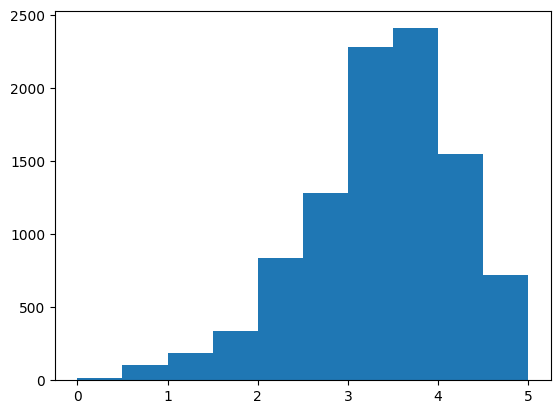

In [ ]:
#EDA
plt.hist(df['avg_rating'])   

<AxesSubplot: >

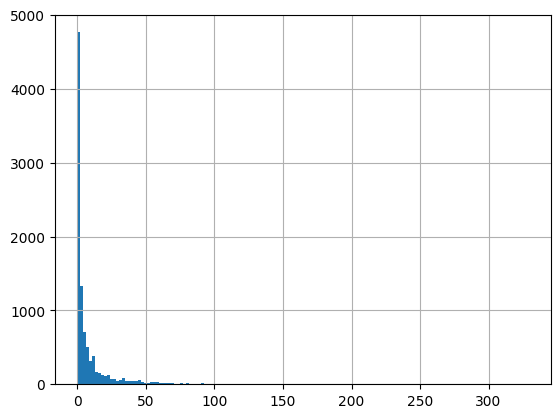

In [ ]:
df['count_rating'].hist(bins=150)   # Most movies have just 1 or 2 ratings

In [ ]:
users_data = ratings.groupby('userId').count()['movieId']
users_data_cap = users_data[users_data >= 120]  # minimum 20 movies has been rated by users -- Every user has voted 20+ movies
best_users = users_data_cap.index
best_users.shape

(213,)

In [ ]:
users_data.describe()

count     610.000000
mean      165.296721
std       269.461615
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: movieId, dtype: float64

In [ ]:
movies_data = ratings.groupby('movieId').count()['userId']
print(movies_data.shape)
movies_data_cap = movies_data[movies_data >= 20]   # Minimum 10 users has rated those movies
best_movies = movies_data_cap.index
best_movies.shape

(9720,)


(1297,)

In [ ]:
movies_data.describe()

count    9720.000000
mean       10.373560
std        22.404848
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: userId, dtype: float64

### Since most of the movies are rated less than 10, we are not filtering it and instead will use ratings df itself

In [ ]:
ratings_best = ratings[ratings['movieId'].isin(best_movies) & ratings['userId'].isin(best_users)]
ratings_best

,userId,movieId,title,tmdbId,rating,timestamp
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499
2,1,2018,Bambi (1942),3170,5.0,964980523
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523
5,1,3578,Gladiator (2000),98,5.0,964980668
...,...,...,...,...,...,...
100805,610,2140,"Dark Crystal, The (1982)",11639,3.5,1493879453
100807,610,2968,Time Bandits (1981),36819,5.0,1493879465
100809,610,909,"Apartment, The (1960)",284,4.5,1494273054
100818,610,968,Night of the Living Dead (1968),10331,4.0,1495959070


### Therefore, we have 2121 movies & 596 users

In [ ]:
# using ratings df itself
# pivot = ratings.pivot_table(
#     index='movieId',
#     columns='userId',
#     values='rating'
# )

pivot = ratings_best.pivot_table(
    index='movieId',
    columns='userId',
    values='rating'
)

pivot

userId,1,4,6,7,10,15,18,19,20,21,...,597,599,600,602,603,605,606,607,608,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,4.5,NaN,2.5,3.5,4.0,NaN,3.5,...,4.0,3.0,2.5,NaN,4.0,4.0,2.5,4.0,2.5,5.0
2,NaN,NaN,4.0,NaN,NaN,NaN,3.0,3.0,3.0,3.5,...,NaN,2.5,4.0,4.0,NaN,3.5,NaN,NaN,2.0,NaN
3,4.0,NaN,5.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,1.5,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
5,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,3.0,4.5,NaN,3.0,4.0,NaN,NaN,NaN,NaN,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148626,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
152081,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
164179,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,4.0,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0


In [ ]:
pivot.fillna(0, inplace=True)
pivot

userId,1,4,6,7,10,15,18,19,20,21,...,597,599,600,602,603,605,606,607,608,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,4.5,0.0,2.5,3.5,4.0,0.0,3.5,...,4.0,3.0,2.5,0.0,4.0,4.0,2.5,4.0,2.5,5.0
2,0.0,0.0,4.0,0.0,0.0,0.0,3.0,3.0,3.0,3.5,...,0.0,2.5,4.0,4.0,0.0,3.5,0.0,0.0,2.0,0.0
3,4.0,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,4.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,3.0,4.5,0.0,3.0,4.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148626,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
152081,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
164179,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,4.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


### We have got user - item matrix. Since we are having a sparse matrix, we need to use compact SVD(U, V^t) to get dense matrix

In [ ]:
# Compact SVD handles missing values also
from surprise import Dataset, Reader, SVD
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
sim_memCF = cosine_similarity(pivot)
sim_memCF.shape

(1297, 1297)

In [ ]:
# Memory-based CF
def recommend_memCF(movie_title):
    
    # Get movie index
    idx = df[df['title'] == movie_title].index[0]
    
    # Get similarity scores
    sim_scores = list(enumerate(sim_memCF[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top 10 similar movies (excluding itself)
    sim_scores = sim_scores[1:11]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return df['title'].iloc[movie_indices]


In [ ]:
recommend_memCF('Jumanji (1995)')

123                        Apollo 13 (1995)
215                      Hunted, The (1995)
186                 Boys on the Side (1995)
154                     Mute Witness (1994)
158                       Party Girl (1995)
178                        Wild Bill (1995)
124                          Rob Roy (1995)
172    Under Siege 2: Dark Territory (1995)
180                      Bushwhacked (1995)
425                     M. Butterfly (1993)
Name: title, dtype: object

In [ ]:
# Model-based CF - Matrix Factorization
U, S, Vt = np.linalg.svd(pivot, full_matrices=False)

In [ ]:
k = 200
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

# reconstructed = U_k @ S_k @ Vt_k
# reconstructed

In [ ]:
S_root = np.sqrt(S_k)

P = U_k @ S_root  # User latent matrix

Q = (S_root @ Vt_k).T  # Movie latent matrix

In [ ]:
R_pred = P @ Q.T

#print("Original Ratings:\n", pivot)
print("\nPredicted Ratings:\n", np.round(R_pred, 2))


Predicted Ratings:
 [[ 4.01 -0.07  0.54 ...  3.83  2.55  5.01]
 [-0.01 -0.01  3.74 ...  0.16  1.98  0.03]
 [ 4.07 -0.05  5.18 ...  0.14  2.07  0.02]
 ...
 [-0.02  0.05  0.21 ...  0.    0.02  4.94]
 [-0.03 -0.04 -0.1  ...  0.11  0.    4.  ]
 [-0.05 -0.19  0.08 ... -0.04  0.06  5.04]]


In [ ]:
def recommend(user_id, pivot, R_pred, top_n=5):

    user_index = pivot.index.get_loc(user_id)

    preds = pd.Series(R_pred[user_index], index=pivot.columns)

    # If you used fillna(0)
    rated = pivot.loc[user_id][pivot.loc[user_id] > 0].index

    preds = preds.drop(rated)

    return preds.sort_values(ascending=False).head(top_n)

print("\nRecommendations for User 0:")
print(recommend(2, pivot, R_pred, 10))


Recommendations for User 0:
userId
314    0.980609
10     0.576823
109    0.460420
89     0.369122
47     0.337015
265    0.270471
369    0.265850
524    0.244536
368    0.234924
73     0.232964
dtype: float64


In [ ]:
U_k = U[:, :k]      # (9720, 20)
S_k = S[:k]         # (20,)  ← KEEP AS VECTOR
Vt_k = Vt[:k, :]

S_root = np.sqrt(S_k)   # (20,)  ← NOT (20,20)

P = U_k * S_root
Q = Vt_k.T * S_root

In [ ]:
P.shape, Q.shape

((1297, 200), (213, 200))

In [ ]:
# item-based CF with similarity
sim_mfCF = cosine_similarity(P)
sim_mfCF.shape

(1297, 1297)

In [ ]:
def recommend_movies(user_id, pivot, similarity_matrix, top_n=10):
    
    # Get user ratings
    user_ratings = pivot[user_id]
    
    # Movies user has rated
    rated_movies = user_ratings[user_ratings > 2]

    print(f'Movies liked by {user_id}::')
    for id in rated_movies.index[:10]:
        print(df[df['movieId'] == id]['title'].values[0])
    
    # Initialize score array
    scores = np.zeros(len(pivot))
    
    # For each movie the user rated
    for movie_id, rating in rated_movies.items():
        
        movie_index = pivot.index.get_loc(movie_id)
        
        # Add weighted similarity
        scores += similarity_matrix[movie_index] * rating
    
    # Remove already rated movies
    rated_indices = [pivot.index.get_loc(m) for m in rated_movies.index]
    scores[rated_indices] = -1
    
    # Get top N indices
    top_indices = np.argsort(scores)[-top_n:][::-1]
    
    # Map back to movie IDs
    recommended_movies = pivot.index[top_indices]
    
    return recommended_movies

In [ ]:
mov_ids = recommend_movies(1, pivot, sim_mfCF, top_n=10)
print('--------------------------------')
print('Recommendations: ')
for id in mov_ids:
    print(df[df['movieId'] == id]['title'].values[0])

Movies liked by 1::
Toy Story (1995)
Grumpier Old Men (1995)
Heat (1995)
Seven (a.k.a. Se7en) (1995)
Usual Suspects, The (1995)
From Dusk Till Dawn (1996)
Bottle Rocket (1996)
Braveheart (1995)
Rob Roy (1995)
Desperado (1995)
--------------------------------
Recommendations: 
Terminator 2: Judgment Day (1991)
Die Hard (1988)
Ferris Bueller's Day Off (1986)
Sixth Sense, The (1999)
Mummy, The (1999)
Godfather, The (1972)
Aliens (1986)
Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
True Lies (1994)
Breakfast Club, The (1985)


In [ ]:
def recommend_dot(user_id, P, Q, pivot, top_n=10):

    user_vector = Q[:, user_id]
    print(user_vector.shape, P.shape, Q.shape)
    scores = P @ user_vector

    # remove already rated
    already_rated = pivot.iloc[:, user_id] > 0
    # Get the actual MovieIDs the user has seen
    watched_movie_ids = pivot.index[already_rated].tolist()
    scores[already_rated.values > 0] = -np.inf
    
    rated_titles = df[df['movieId'].isin(watched_movie_ids)]['title']
    
    # print(f"--- Movies User (Index {user_id}) already rated ---")
    # display(rated_titles[:10]) # Show first 10 for brevity
    # print("\n" + "="*30 + "\n")
    top_movies = np.argsort(scores)[-top_n:][::-1]
    # 5. Map those positions to actual MovieIDs from your pivot table
    recommended_movie_ids = pivot.index[top_movies].tolist()
    
    return recommended_movie_ids

In [ ]:
top_user_mov = ratings[ratings['userId'] >= 3.5].sort_values(by='rating', ascending=False)['movieId']
for id in top_user_mov.iloc[:20]:
    print(df[df['movieId'] == id]['title'].values[0])

Big Hero 6 (2014)
12 Angry Men (1957)
Pirates of the Caribbean: The Curse of the Black Pearl (2003)
Inside Man (2006)
Inglourious Basterds (2009)
NeverEnding Story, The (1984)
Shrek (2001)
Escape from New York (1981)
Clash of the Titans (1981)
Misérables, Les (1998)
Batman Begins (2005)
Lord of the Rings: The Fellowship of the Ring, The (2001)
Star Wars: Episode VI - Return of the Jedi (1983)
Gladiator (2000)
Graduate, The (1967)
Crocodile Dundee (1986)
Indiana Jones and the Temple of Doom (1984)
Star Trek II: The Wrath of Khan (1982)
Dragonslayer (1981)
Bill & Ted's Excellent Adventure (1989)


In [ ]:
topkmov = recommend_dot(1, P, Q.T, pivot, 20)
print(topkmov)
print('--------------------------------')
print('Recommendations: ')
for id in topkmov:
    print(df[df['movieId'] == id]['title'].values[0])

(200,) (1297, 200) (200, 213)
[84152, 25, 135, 370, 922, 163, 97304, 16, 1088, 95, 1021, 109487, 63082, 106782, 91529, 51662, 30812, 112552, 33166, 6283]
--------------------------------
Recommendations: 
Limitless (2011)
Leaving Las Vegas (1995)
Down Periscope (1996)
Naked Gun 33 1/3: The Final Insult (1994)
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
Desperado (1995)
Argo (2012)
Casino (1995)
Dirty Dancing (1987)
Broken Arrow (1996)
Angels in the Outfield (1994)
Interstellar (2014)
Slumdog Millionaire (2008)
Wolf of Wall Street, The (2013)
Dark Knight Rises, The (2012)
300 (2007)
Aviator, The (2004)
Whiplash (2014)
Crash (2004)
Cowboy Bebop: The Movie (Cowboy Bebop: Tengoku no Tobira) (2001)


In [ ]:
# Using truncated SVD - efficient than numpy for sparse matrices
from sklearn.decomposition import TruncatedSVD

In [ ]:
svd = TruncatedSVD(200)
P = svd.fit_transform(pivot)
Q = svd.components_
P.shape, Q.shape

((1297, 200), (200, 213))

In [ ]:
topkmovT = recommend_dot(1, P, Q, pivot, 20)
# print(topkmovT)
print('--------------------------------')
print('Recommendations: ')
for id in topkmovT:
    print(df[df['movieId'] == id]['title'].values[0])

(200,) (1297, 200) (200, 213)
--------------------------------
Recommendations: 
Leaving Las Vegas (1995)
Limitless (2011)
Interstellar (2014)
Angels in the Outfield (1994)
Desperado (1995)
Dark Knight Rises, The (2012)
Argo (2012)
Wolf of Wall Street, The (2013)
Casino (1995)
Dirty Dancing (1987)
King's Speech, The (2010)
Pianist, The (2002)
Broken Arrow (1996)
Down Periscope (1996)
Cowboy Bebop: The Movie (Cowboy Bebop: Tengoku no Tobira) (2001)
What's Eating Gilbert Grape (1993)
Aviator, The (2004)
Naked Gun 33 1/3: The Final Insult (1994)
300 (2007)
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)


In [ ]:
a

NameError: name 'a' is not defined

In [ ]:
# ratings.drop('timestamp',axis=1, inplace=True)
# ratings

In [ ]:
ratings['rating_svd'] = ratings['rating']
ratings

,userId,movieId,title,tmdbId,rating,timestamp,rating_svd
0,1,804,She's the One (1996),11363,4.0,964980499,4.0
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499,5.0
2,1,2018,Bambi (1942),3170,5.0,964980523,5.0
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523,4.0
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523,4.0
...,...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269,3.5
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282,4.0
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299,3.5
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405,3.5


In [ ]:
# Normalize ratings to [0,1] range
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import pickle
from sklearn.model_selection import train_test_split

2026-05-03 20:18:15.598902: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 20:18:15.881046: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 20:18:15.882583: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-03 20:18:16.960966: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [ ]:
ratings.sort_values(['userId', 'timestamp'])

,userId,movieId,title,tmdbId,rating,timestamp,rating_svd
0,1,804,She's the One (1996),11363,4.0,964980499,4.0
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499,5.0
2,1,2018,Bambi (1942),3170,5.0,964980523,5.0
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523,4.0
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523,4.0
...,...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269,3.5
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282,4.0
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299,3.5
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405,3.5


In [ ]:
threshold=4
ratings['imp_rating'] = (ratings['rating'] >= threshold).astype(int)
ratings = ratings.sort_values(['userId', 'timestamp'])

In [ ]:
# next surprise SVD & DL(embedding) - model-based, previous numpy & truncatedsvd are matrix decomposition - memory based but optimized (reduced sparsity)
#DL
def split_per_user(ratings, test_size1=0.2, test_size2=0.2, threshold=3.5, min_liked=1, rs=42, low=10):
    train_list, test_list = [], []

    ratings = ratings.sort_values(['userId', 'timestamp'])
    
    for user_id, group in ratings.groupby('userId'):
        liked    = group[group['rating'] >= threshold]
        disliked = group[group['rating'] <  threshold]

        if len(liked) < low:  # Min 10 movies
            # Can't split — not enough liked movies to put some in test
            train_list.append(group)
            continue

        # ── Guarantee at least 1 liked movie in test ──────────
        # n_test_liked  = max(min_liked, int(len(liked)%21)) # 20 movies for each user is masked
        n_test_liked  = max(min_liked, int(len(liked) * test_size1))
        # test_liked    = liked.sample(n=n_test_liked, random_state=rs)
        # train_liked   = liked.drop(test_liked.index)
        train_liked = liked.iloc[:-n_test_liked]
        test_liked  = liked.iloc[-n_test_liked:]

        # ── Disliked movies — split randomly ──────────────────
        # n_test_disliked = max(0, int(len(disliked) * test_size))
        n_test_disliked = max(0, int(len(disliked) * test_size2))
        if len(disliked) > 0 and n_test_disliked > 0:
            # test_disliked  = disliked.sample(n=n_test_disliked, random_state=rs)
            # train_disliked = disliked.drop(test_disliked.index)
            train_disliked = disliked.iloc[:-n_test_disliked]
            test_disliked  = disliked.iloc[-n_test_disliked:]
        else:
            test_disliked  = pd.DataFrame()
            train_disliked = disliked

        # ── Combine ───────────────────────────────────────────
        train_list.append(pd.concat([train_liked, train_disliked]))
        test_list.append(pd.concat([test_liked,  test_disliked]))

    train = pd.concat(train_list).reset_index(drop=True)
    test  = pd.concat(test_list).reset_index(drop=True)

    # Verify
    print(f"Train size: {len(train)} | Test size: {len(test)}")
    print(f"Users in train: {train['userId'].nunique()} | Users in test: {test['userId'].nunique()}")
    print(f"Test liked  (>={threshold}): {len(test[test['rating'] >= threshold])}")
    print(f"Test disliked (<{threshold}): {len(test[test['rating'] < threshold])}")
    print(f"Train liked  (>={threshold}): {len(train[train['rating'] >= threshold])}")
    print(f"Train disliked (<{threshold}): {len(train[train['rating'] < threshold])}")

    return train, test

# train, test = split_per_user(ratings, 0.1, 3.5, 1, 42)
# train.shape, test.shape

In [ ]:
# ── Encode IDs ────────────────────────────────────────────────
user2idx  = {u: i for i, u in enumerate(ratings['userId'].unique())}
movie2idx = {m: i for i, m in enumerate(ratings['movieId'].unique())}

ratings['user_idx']  = ratings['userId'].map(user2idx)
ratings['movie_idx'] = ratings['movieId'].map(movie2idx)

# user2idx  = {u: i for i, u in enumerate(train['userId'].unique())}
# movie2idx = {m: i for i, m in enumerate(train['movieId'].unique())}

# train['user_idx']  = train['userId'].map(user2idx)
# train['movie_idx'] = train['movieId'].map(movie2idx)

n_users  = len(user2idx)
n_movies = len(movie2idx)

# ── 1. Split FIRST before anything ────────────────────────────
train, test = split_per_user(ratings, 0.3, 0.4, 4, rs=42)


# scaler = MinMaxScaler()
# train['rating'] = scaler.fit_transform(train[['rating']])
# test['rating'] = scaler.transform(test[['rating']])

# 2. Create the new dictionaries by filtering the global ones
train_user2idx = {user: user2idx[user] for user in train.userId}
train_movie2idx = {movie: movie2idx[movie] for movie in train.movieId}
len(train_movie2idx), len(train_user2idx)

# # ── Dataset ───────────────────────────────────────────────────
# dataset = tf.data.Dataset.from_tensor_slices((
#     {'user':  train['user_idx'].values,
#      'movie': train['movie_idx'].values},
#     train['rating'].values.astype(np.float32)
# )).shuffle(10000).batch(512)

Train size: 66143 | Test size: 34688
Users in train: 610 | Users in test: 579
Test liked  (>=4): 14252
Test disliked (<4): 20436
Train liked  (>=4): 34327
Train disliked (<4): 31816


(7197, 610)

In [ ]:
print(f"full ratings unique movies : {ratings['movieId'].nunique()}")
print(f"train unique movies        : {train['movieId'].nunique()}")

full ratings unique movies : 9720
train unique movies        : 7197


In [ ]:
train

,userId,movieId,title,tmdbId,rating,timestamp,rating_svd,imp_rating,user_idx,movie_idx
0,1,804,She's the One (1996),11363,4.0,964980499,4.0,1,0,0
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499,5.0,1,0,1
2,1,2018,Bambi (1942),3170,5.0,964980523,5.0,1,0,2
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523,4.0,1,0,3
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523,4.0,1,0,4
...,...,...,...,...,...,...,...,...,...,...
66138,610,7348,Spartan (2004),11169,3.5,1493847734,3.5,0,609,7600
66139,610,90600,Headhunters (Hodejegerne) (2011),70670,3.5,1493847740,3.5,0,609,1378
66140,610,4450,Bully (2001),9517,1.0,1493847748,1.0,0,609,5134
66141,610,80126,"American, The (2010)",27579,3.5,1493847754,3.5,0,609,5269


In [ ]:
## Data is split now compare all the CF models

from surprise import Dataset, Reader, SVD, SVDpp
from surprise.model_selection import GridSearchCV

reader = Reader(rating_scale=(train['rating_svd'].min(), train['rating_svd'].max()))
data = Dataset.load_from_df(train[['userId', 'movieId', 'rating_svd']], reader)

trainset = data.build_full_trainset()
trainset.n_items

In [ ]:
## Need to do hyperparam tuning for svd, also need to try svd+

In [ ]:
# param_grid = {
#     'n_factors': [50, 100, 200],
#     'n_epochs':  [20, 30, 50, 100],
#     'lr_all':    [0.002, 0.005, 0.01],
#     'reg_all':   [0.02, 0.05, 0.1, 0.4]
# }

# gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=5, n_jobs=-1)
# #gs.fit(data)
# print(gs.best_params)   # use these params

In [ ]:
svdS = SVD(
    n_factors=200,
    n_epochs=100,
    lr_all=0.002,
    reg_all=0.002
)

svdS.fit(trainset)

NameError: name 'trainset' is not defined

In [ ]:
P = svdS.pu   # user latent matrix
Q = svdS.qi   # item latent matrix
P.shape, Q.shape

((610, 200), (8595, 200))

In [ ]:
# ── Recommend for a userId ────────────────────────────────────
user_id = 1

# Get Surprise's inner index for this user
u_inner     = trainset.to_inner_uid(user_id)
user_vector = P[u_inner]                  # (n_factors,)
#print(user_vector.shape)

# Score every movie via dot product
scores = Q @ user_vector                  # (n_movies,)

# Mask already rated movies
watched = set(ratings_best[ratings_best['userId'] == user_id]['movieId'].values)

# print(f'Movies liked by {user_id}::')
# for id in list(watched)[:10]:
#     print(df[df['movieId'] == id]['title'].values[0])

all_movie_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]

#print(scores[1], len(all_movie_ids))

for i, mid in enumerate(all_movie_ids):
    if mid in watched:
        scores[i] = -np.inf

# Top-N
top_idx    = np.argsort(scores)[::-1][:20]
top_movies = [all_movie_ids[i] for i in top_idx]
print(top_movies)

# ✅ drop_duplicates before reindex to avoid duplicate label error
result = movies[movies['movieId'].isin(top_movies)][['movieId', 'title']]
#           .drop_duplicates(subset='movieId')        # ← fix
#           .set_index('movieId')
#           .reindex(top_movies)
#           .reset_index())

result['predicted_rating'] = scores[top_idx]

display(result)

[34, 92938, 3543, 253, 965, 3623, 5881, 1371, 27790, 45447, 7937, 25886, 31221, 5607, 55247, 7101, 86320, 2867, 4273, 33794]


,movieId,title,predicted_rating
32,34,Babe (1995),1.023196
217,253,Interview with the Vampire: The Vampire Chroni...,1.000196
739,965,"39 Steps, The (1935)",0.920692
1052,1371,Star Trek: The Motion Picture (1979),0.869208
2152,2867,Fright Night (1985),0.863445
2645,3543,Diner (1982),0.822468
2699,3623,Mission: Impossible II (2000),0.816853
3171,4273,Under the Sand (2000),0.805707
3972,5607,"Son of the Bride (Hijo de la novia, El) (2001)",0.771302
4102,5881,Solaris (2002),0.763692


In [ ]:
ratings_best[ratings_best['userId']==1]['title'].str.contains('Austin').sum()

1

In [ ]:
def recommend_dot_SVDS(user_id, P, Q, pivot, top_n=10):

    user_inner_id = trainset.to_inner_uid(user_id)
    user_vector = Q[:, user_inner_id]
    print(user_vector.shape, P.shape, Q.shape)
    scores = P @ user_vector

    # remove already rated
    already_rated = pivot.iloc[:, user_id] > 0
    # Get the actual MovieIDs the user has seen
    watched_movie_ids = pivot.index[already_rated].tolist()
    scores[already_rated.values > 0] = -np.inf
    
    rated_titles = df[df['movieId'].isin(watched_movie_ids)]['title']
    
    # print(f"--- Movies User (Index {user_id}) already rated ---")
    # display(rated_titles[:10]) # Show first 10 for brevity
    # print("\n" + "="*30 + "\n")
    top_movies = np.argsort(scores)[-top_n:][::-1]
    # 5. Map those positions to actual MovieIDs from your pivot table
    recommended_movie_ids = pivot.index[top_movies].tolist()
    
    return recommended_movie_ids

In [ ]:
def recommend_surprise(user_id, df, model, top_n=10):
    
    # All unique movies
    all_movie_ids = df['movieId'].unique()
    
    # Movies user already rated
    rated_movies = df[df['userId'] == user_id]['movieId'].values

    # print(rated_movies)

    # for id in rated_movies[:10]:
    #     print(movies[movies['movieId'] == id]['title'].values[0])    
    
    # Movies not rated yet
    movies_to_predict = [m for m in all_movie_ids if m not in rated_movies]
    
    print(rated_movies.shape, len(movies_to_predict))

    predictions = []
    
    for movie_id in movies_to_predict:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    # Sort by predicted rating
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    top_movies = predictions[:top_n]
    
    return top_movies

In [ ]:
topkmovS = recommend_surprise(1, ratings, svdS, top_n=10)  # Prediction with SVD -- proper model-based
print(topkmovS)
print('--------------------------------')
print('Recommendations: ')
for movie_id, predicted_rating in topkmovS:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{title}  →  {predicted_rating:.2f}")

(232,) 9488
[(77455, 5.0), (6874, 5.0), (106782, 5.0), (48516, 5.0), (2288, 5.0), (3949, 5.0), (2351, 5.0), (2921, 5.0), (509, 5.0), (1288, 5.0)]
--------------------------------
Recommendations: 
Exit Through the Gift Shop (2010)  →  5.00
Kill Bill: Vol. 1 (2003)  →  5.00
Wolf of Wall Street, The (2013)  →  5.00
Departed, The (2006)  →  5.00
Thing, The (1982)  →  5.00
Requiem for a Dream (2000)  →  5.00
Nights of Cabiria (Notti di Cabiria, Le) (1957)  →  5.00
High Plains Drifter (1973)  →  5.00
Piano, The (1993)  →  5.00
This Is Spinal Tap (1984)  →  5.00


In [ ]:
def recommend_fast(user_id, model, top_n=10):

    trainset = model.trainset
    inner_uid = trainset.to_inner_uid(user_id)

    # User latent vector
    user_vector = model.pu[inner_uid]        # (k,)

    # All movie latent vectors
    movie_vectors = model.qi                 # (9720, k)

    alpha, beta, gamma, delta = 0.8, 0.2, 0.1, 0.1
    # Compute scores
    scores = (
        #(movie_vectors @ user_vector)
        alpha*(movie_vectors @ user_vector)
        + gamma*model.bu[inner_uid]
        + beta * model.bi
        + delta*trainset.global_mean
        
    )

    # Remove already rated movies
    rated = [iid for (iid, _) in trainset.ur[inner_uid]]
    scores[rated] = -np.inf

    # Top-N
    top_inner_ids = np.argsort(scores)[-top_n:][::-1]
    top_raw_ids = [trainset.to_raw_iid(iid) for iid in top_inner_ids]

    return top_raw_ids

In [ ]:
# def get_user_top_rated(user_id, model, n=10):
#     trainset = model.trainset
    
#     # 1. Convert raw user_id to inner_uid
#     try:
#         inner_uid = trainset.to_inner_uid(user_id)
#     except ValueError:
#         return "User ID not found in training set."

#     # 2. Get all ratings for this user (inner_iid, rating)
#     user_ratings = trainset.ur[inner_uid]

#     # 3. Sort by rating (the second element in the tuple) in descending order
#     user_ratings.sort(key=lambda x: x[1], reverse=True)

#     print(f"--- Top {n} movies already rated by User {user_id} ---")
    
#     # 4. Loop through the top N and map back to titles
#     for iid, rating in user_ratings[:n]:
#         raw_iid = trainset.to_raw_iid(iid)
#         # Assuming 'df' is your original dataframe with 'movieId' and 'title'
#         movie_title = df[df['movieId'] == raw_iid]['title'].values[0]
#         print(f"Score: {rating:.1f} | {movie_title}")

# # Usage
# get_user_top_rated(1, svdS)

In [ ]:
topkmovS = recommend_fast(1, svdS, top_n=10)
print(topkmovS)
print('--------------------------------')
print('Recommendations: ')
for movie_id in topkmovS:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{title}")

[34, 3543, 965, 253, 92938, 55247, 1172, 33794, 64614, 27790]
--------------------------------
Recommendations: 
Babe (1995)
Diner (1982)
39 Steps, The (1935)
Interview with the Vampire: The Vampire Chronicles (1994)
Ghost Rider: Spirit of Vengeance (2012)
Into the Wild (2007)
Cinema Paradiso (Nuovo cinema Paradiso) (1989)
Batman Begins (2005)
Gran Torino (2008)
Millions (2004)


In [ ]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
# ── Fit KNN on pivot ──────────────────────────────────────────
knn = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
knn.fit(pivot)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=20)

In [ ]:
# ── Recommend ─────────────────────────────────────────────────
user_id = 1

user_col     = pivot[user_id]
liked_movies = user_col[user_col > 0].index.tolist()

scores = np.zeros(len(pivot))

for movie_id in liked_movies:
    movie_vector       = pivot.loc[movie_id].values.reshape(1, -1)
    distances, indices = knn.kneighbors(movie_vector)
    similarity         = 1 - distances.flatten()
    user_rating        = user_col[movie_id]

    for idx, sim in zip(indices.flatten(), similarity):
        scores[idx] += sim * user_rating

# Mask already watched
watched_indices = [pivot.index.get_loc(m) for m in liked_movies]
scores[watched_indices] = -np.inf

# Top-N
top_idx    = np.argsort(scores)[::-1][:20]
top_movies = pivot.index[top_idx].tolist()

result = (movies[['movieId', 'title']]
          .drop_duplicates(subset='movieId')
          .set_index('movieId')
          .reindex(top_movies)
          .reset_index())
result['score'] = scores[top_idx]

print(result)

    movieId                                         title       score
0      1036                               Die Hard (1988)  100.591530
1       589             Terminator 2: Judgment Day (1991)   76.040586
2      2918               Ferris Bueller's Day Off (1986)   64.024669
3       318              Shawshank Redemption, The (1994)   57.110528
4       858                         Godfather, The (1972)   54.164784
5      2762                       Sixth Sense, The (1999)   53.160476
6      1200                                 Aliens (1986)   46.912974
7       380                              True Lies (1994)   40.413081
8      2087                              Peter Pan (1953)   33.743755
9        32     Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   33.612141
10     2683  Austin Powers: The Spy Who Shagged Me (1999)   33.483012
11     2081                    Little Mermaid, The (1989)   32.706200
12      594        Snow White and the Seven Dwarfs (1937)   29.857560
13      541         

In [ ]:
a

In [ ]:
# #Normalize ratings — helps model converge better
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# train['rating'] = scaler.fit_transform(train[['rating']])
# test['rating']  = scaler.transform(test[['rating']])

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',   # metric to watch
    patience=10,           # epochs to wait before stopping
    restore_best_weights=True
)

In [ ]:
# ── Encode IDs ────────────────────────────────────────────────
# user2idx  = {u: i for i, u in enumerate(ratings['userId'].unique())}
# movie2idx = {m: i for i, m in enumerate(ratings['movieId'].unique())}

# ratings['user_idx']  = ratings['userId'].map(user2idx)
# ratings['movie_idx'] = ratings['movieId'].map(movie2idx)

# n_users  = len(user2idx)
# n_movies = len(movie2idx)

# ── 1. Split FIRST before anything ────────────────────────────
# train, test = train_test_split(ratings, test_size=0.2, random_state=42)
# train, test = split_per_user(ratings, 0.1, 3.5, 1, 42)

# # Normalize ratings to [0,1] range
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# train['rating'] = scaler.fit_transform(train[['rating']])
# test['rating']  = scaler.transform(test[['rating']])

# ── Add idx columns to both train and test ────────────────────
# train = train.copy()
# test  = test.copy()

# train['user_idx']  = train['userId'].map(user2idx)
# train['movie_idx'] = train['movieId'].map(movie2idx)
# test['user_idx']   = test['userId'].map(user2idx)
# test['movie_idx']  = test['movieId'].map(movie2idx)

# ── Prepare tensors ───────────────────────────────────────────
users_t   = train['user_idx'].values
movies_t  = train['movie_idx'].values
ratings_t = train['rating'].values.astype(np.float32)

dataset = tf.data.Dataset.from_tensor_slices(({'user': users_t, 'movie': movies_t}, ratings_t))
dataset = dataset.shuffle(10000).batch(512)

In [ ]:
# ── Model ─────────────────────────────────────────────────────
EMB_DIM = 512

user_input  = tf.keras.Input(shape=(), name='user',  dtype='int32')
movie_input = tf.keras.Input(shape=(), name='movie', dtype='int32')

user_vec  = tf.keras.layers.Embedding(n_users,  EMB_DIM)(user_input)
movie_vec = tf.keras.layers.Embedding(n_movies, EMB_DIM)(movie_input)

x = tf.keras.layers.Concatenate()([user_vec, movie_vec])
# Layer 1
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Layer 2
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Layer 3
x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.1)(x)

# Layer 4
x = tf.keras.layers.Dense(32)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

# Output
output = tf.keras.layers.Dense(1)(x)

base_mlpmodel = tf.keras.Model(inputs=[user_input, movie_input], outputs=output)
base_mlpmodel.compile(optimizer='adam', loss='mse', metrics=['mae'])
base_mlpmodel.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 movie (InputLayer)          [(None,)]                    0         []                            
                                                                                                  
 embedding_2 (Embedding)     (None, 512)                  312320    ['user[0][0]']                
                                                                                                  
 embedding_3 (Embedding)     (None, 512)                  4976640   ['movie[0][0]']               
                                                                                            

In [ ]:
base_mlpmodel.fit(dataset, epochs=100, verbose=1, callbacks=[early_stop])

Epoch 1/100
148/148 [==============================] - 12s 67ms/step - loss: 5.9581 - mae: 2.1235
Epoch 2/100
148/148 [==============================] - 10s 70ms/step - loss: 1.2198 - mae: 0.8856
Epoch 3/100
148/148 [==============================] - 10s 64ms/step - loss: 0.8147 - mae: 0.6962
Epoch 4/100
148/148 [==============================] - 10s 70ms/step - loss: 0.7150 - mae: 0.6493
Epoch 5/100
148/148 [==============================] - 10s 67ms/step - loss: 0.6588 - mae: 0.6211
Epoch 6/100
148/148 [==============================] - 10s 65ms/step - loss: 0.6187 - mae: 0.6006
Epoch 7/100
148/148 [==============================] - 9s 62ms/step - loss: 0.5881 - mae: 0.5836
Epoch 8/100
148/148 [==============================] - 9s 62ms/step - loss: 0.5571 - mae: 0.5683
Epoch 9/100
148/148 [==============================] - 9s 61ms/step - loss: 0.5304 - mae: 0.5545
Epoch 10/100
148/148 [==============================] - 11s 71ms/step - loss: 0.5084 - mae: 0.5420
Epoch 11/100
148/148 [

In [ ]:
user_vec.shape, movie_vec.shape

(TensorShape([None, 512]), TensorShape([None, 512]))

In [ ]:
# ── Recommend ─────────────────────────────────────────────────
user_id = 1
def rec_base_mlpmodel(user_id):
    watched = set(ratings[ratings['userId'] == user_id]['movieId'].values)
    unseen  = [mid for mid in movie2idx if mid not in watched]
    m_idxs  = [movie2idx[m] for m in unseen]
    u_idx   = user2idx[user_id]

    scores = base_mlpmodel.predict({
        'user':  np.array([u_idx]  * len(m_idxs)),
        'movie': np.array(m_idxs)
    }, verbose=0).flatten()

    top_idx    = np.argsort(scores)[::-1][:20]
    top_movies = [unseen[i] for i in top_idx]

    result_base_mlpmodel = (movies[movies['movieId'].isin(top_movies)][['movieId', 'title']]
            .set_index('movieId').reindex(top_movies).reset_index())
    result_base_mlpmodel['predicted_rating'] = scores[top_idx]

    return result_base_mlpmodel

result_base_mlpmodel = rec_base_mlpmodel(user_id)
result_base_mlpmodel

,movieId,title,predicted_rating
0,5537,Satin Rouge (2002),5.010586
1,3676,Eraserhead (1977),5.010202
2,6835,Alien Contamination (1980),5.009000
3,3022,"General, The (1926)",5.008540
4,2969,"Man and a Woman, A (Un homme et une femme) (1966)",5.006745
5,7579,Pride and Prejudice (1940),5.006369
6,172585,Karlson Returns (1970),5.005728
7,3537,Where the Money Is (2000),5.005687
8,110501,The Raid 2: Berandal (2014),5.005499
9,3552,Caddyshack (1980),5.002012


In [ ]:
# --- SAVING ---
with open('./data/base_mlpmodel.pkl', 'wb') as f:
    pickle.dump(base_mlpmodel, f)

In [ ]:
# # ── Encode IDs ────────────────────────────────────────────────
# user2idx  = {u: i for i, u in enumerate(ratings['userId'].unique())}
# movie2idx = {m: i for i, m in enumerate(ratings['movieId'].unique())}

# ratings['user_idx']  = ratings['userId'].map(user2idx)
# ratings['movie_idx'] = ratings['movieId'].map(movie2idx)

# n_users  = len(user2idx)
# n_movies = len(movie2idx)

# # ── 1. Split FIRST before anything ────────────────────────────
# #train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# # ── Build Dataset ─────────────────────────────────────────────
# dataset = tf.data.Dataset.from_tensor_slices((
#     {'user':  train['user_idx'].values,
#      'movie': train['movie_idx'].values},
#     train['rating'].values.astype(np.float32)
# )).shuffle(10000).batch(512)

In [ ]:
# ── Build Model ───────────────────────────────────────────────
EMB_DIM = 512

user_input  = tf.keras.Input(shape=(), name='user',  dtype='int32')
movie_input = tf.keras.Input(shape=(), name='movie', dtype='int32')

user_vec  = tf.keras.layers.Embedding(n_users,  EMB_DIM)(user_input)
movie_vec = tf.keras.layers.Embedding(n_movies, EMB_DIM)(movie_input)

concatenated = tf.keras.layers.Concatenate()([user_vec, movie_vec])

sequential_block = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128,  activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32,  activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

output = sequential_block(concatenated)

seq_mlpmodel = tf.keras.Model(inputs=[user_input, movie_input], outputs=output)
seq_mlpmodel.compile(optimizer='adam', loss='mse', metrics='mse')
seq_mlpmodel.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 movie (InputLayer)          [(None,)]                    0         []                            
                                                                                                  
 embedding_4 (Embedding)     (None, 512)                  312320    ['user[0][0]']                
                                                                                                  
 embedding_5 (Embedding)     (None, 512)                  4976640   ['movie[0][0]']               
                                                                                            

In [ ]:
# ── Train ─────────────────────────────────────────────────────
seq_mlpmodel.fit(dataset, epochs=100, verbose=1)

Epoch 1/100
148/148 [==============================] - 11s 61ms/step - loss: 11.3064 - mse: 11.3064
Epoch 2/100
148/148 [==============================] - 9s 61ms/step - loss: 3.5265 - mse: 3.5265
Epoch 3/100
148/148 [==============================] - 9s 61ms/step - loss: 1.7466 - mse: 1.7466
Epoch 4/100
148/148 [==============================] - 9s 62ms/step - loss: 1.3971 - mse: 1.3971
Epoch 5/100
148/148 [==============================] - 9s 62ms/step - loss: 1.1759 - mse: 1.1759
Epoch 6/100
148/148 [==============================] - 9s 63ms/step - loss: 1.0348 - mse: 1.0348
Epoch 7/100
148/148 [==============================] - 10s 64ms/step - loss: 0.9274 - mse: 0.9274
Epoch 8/100
148/148 [==============================] - 10s 69ms/step - loss: 0.8559 - mse: 0.8559
Epoch 9/100
148/148 [==============================] - 10s 67ms/step - loss: 0.7973 - mse: 0.7973
Epoch 10/100
148/148 [==============================] - 10s 67ms/step - loss: 0.7516 - mse: 0.7516
Epoch 11/100
148/148 [

In [ ]:
# ── Recommend ─────────────────────────────────────────────────
user_id = 1
def rec_seq_mlpmodel(user_id):
    watched = set(ratings[ratings['userId'] == user_id]['movieId'].values)
    unseen  = [mid for mid in movie2idx if mid not in watched]

    scores = seq_mlpmodel.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0).flatten()

    top_idx    = np.argsort(scores)[::-1][:20]
    top_movies = [unseen[i] for i in top_idx]

    result_seq_mlpmodel = (movies[['movieId', 'title']]
            .drop_duplicates(subset='movieId')
            .set_index('movieId')
            .reindex(top_movies)
            .reset_index())
    result_seq_mlpmodel['predicted_rating'] = scores[top_idx]

    return result_seq_mlpmodel

result_seq_mlpmodel = rec_seq_mlpmodel(user_id)
result_seq_mlpmodel

,movieId,title,predicted_rating
0,26849,"Stand, The (1994)",5.148089
1,7256,Touching the Void (2003),5.104207
2,71268,Tyler Perry's I Can Do Bad All by Myself (2009),5.104158
3,5008,Witness for the Prosecution (1957),5.082561
4,70451,Max Manus (2008),5.073864
5,118834,National Lampoon's Bag Boy (2007),5.073493
6,272,"Madness of King George, The (1994)",5.060854
7,1203,12 Angry Men (1957),5.059462
8,174053,Black Mirror: White Christmas (2014),5.047999
9,6807,Monty Python's The Meaning of Life (1983),5.046220


In [ ]:
# --- SAVING ---
with open('./data/seq_mlpmodel.pkl', 'wb') as f:
    pickle.dump(seq_mlpmodel, f)

In [ ]:
# ── Encode userIds to 0-based index ───────────────────────────
# user2idx = {u: i for i, u in enumerate(ratings['userId'].unique())}
#user2idx = {u: i for i, u in enumerate(ratings_best['userId'].unique())}

# ── Pivot: rows=userId, columns=movieId ───────────────────────
# Autoencoder input = one user's full rating row (n_movies,)
pivot = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
# pivot = ratings_best.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

# n_users  = pivot.shape[0]   # 610
# n_movies = pivot.shape[1]   # 9724

X = pivot.values.astype(np.float32)   # (n_users × n_movies)

print(f"Input shape: {X.shape}")

Input shape: (610, 9720)


In [ ]:
# # ── Build Autoencoder ─────────────────────────────────────────
# input_layer = tf.keras.Input(shape=(n_movies,))

# # Encoder — compress user rating vector into latent space
# encoded = tf.keras.layers.Dense(256, activation='relu')(input_layer)
# encoded = tf.keras.layers.Dropout(0.3)(encoded)
# encoded = tf.keras.layers.Dense(128, activation='relu')(encoded)
# encoded = tf.keras.layers.Dropout(0.2)(encoded)
# encoded = tf.keras.layers.Dense(64,  activation='relu')(encoded)

# # Decoder — reconstruct full rating row from latent space
# decoded = tf.keras.layers.Dense(128, activation='relu')(encoded)
# decoded = tf.keras.layers.Dense(256, activation='relu')(decoded)
# decoded = tf.keras.layers.Dense(n_movies, activation='linear')(decoded)  # predicted ratings for all movies

# autoenc_model = tf.keras.Model(inputs=input_layer, outputs=decoded)
# autoenc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# autoenc_model.summary()#

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 9720)]            0         
                                                                 
 dense (Dense)               (None, 256)               2488576   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 128)               8320  

In [ ]:
def masked_mse(y_true, y_pred):
    mask  = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss  = tf.square(y_true - y_pred) * mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)

#input_layer = tf.keras.Input(shape=(n_movies,))

# Encoder
# x = tf.keras.layers.Dense(512)(input_layer)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.Dropout(0.3)(x)

# x = tf.keras.layers.Dense(256)(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.Dropout(0.2)(x)

# x = tf.keras.layers.Dense(128)(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)   # bottleneck
# # x = tf.keras.layers.Dropout(0.2)(x)

# # x = tf.keras.layers.Dense(64)(x)
# # x = tf.keras.layers.BatchNormalization()(x)
# # x = tf.keras.layers.Activation('relu')(x)


# # Decoder
# x = tf.keras.layers.Dense(256)(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.Dropout(0.2)(x)

# x = tf.keras.layers.Dense(512)(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.Dropout(0.1)(x)

# output = tf.keras.layers.Dense(n_movies, activation='linear')(x)

# autoenc_model = tf.keras.Model(inputs=input_layer, outputs=output)
# autoenc_model.compile(optimizer='adam', loss=masked_mse)

# Current autoencoder too deep for sparse data
# Simpler architecture works better

input_layer = tf.keras.Input(shape=(n_movies,))

# Simpler encoder
x = tf.keras.layers.Dense(256)(input_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Dense(64)(x)       # smaller bottleneck
x = tf.keras.layers.Activation('relu')(x)

# Simpler decoder
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

output = tf.keras.layers.Dense(n_movies, activation='linear')(x)

autoenc_model = tf.keras.Model(inputs=input_layer, outputs=output)
autoenc_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss=masked_mse)

In [ ]:
# ── Train ─────────────────────────────────────────────────────
# input = output (reconstruct itself, filling in unrated movies)
autoenc_model.fit(X, X, epochs=100, batch_size=512, validation_split=0.3)

Epoch 1/100
1/1 [==============================] - 1s 1s/step - loss: 13.6249 - val_loss: 12.6340
Epoch 2/100
1/1 [==============================] - 0s 146ms/step - loss: 12.5272 - val_loss: 11.9137
Epoch 3/100
1/1 [==============================] - 0s 149ms/step - loss: 11.3582 - val_loss: 10.7264
Epoch 4/100
1/1 [==============================] - 0s 143ms/step - loss: 10.2545 - val_loss: 9.2508
Epoch 5/100
1/1 [==============================] - 0s 148ms/step - loss: 9.2285 - val_loss: 7.6711
Epoch 6/100
1/1 [==============================] - 0s 147ms/step - loss: 8.2489 - val_loss: 6.3916
Epoch 7/100
1/1 [==============================] - 0s 142ms/step - loss: 7.3926 - val_loss: 5.6482
Epoch 8/100
1/1 [==============================] - 0s 159ms/step - loss: 6.6501 - val_loss: 5.5712
Epoch 9/100
1/1 [==============================] - 0s 142ms/step - loss: 5.9958 - val_loss: 5.9210
Epoch 10/100
1/1 [==============================] - 0s 146ms/step - loss: 5.3997 - val_loss: 6.2963
Epoch

In [ ]:
# ── Recommend for a userId ────────────────────────────────────
user_id = 1

def rec_autoencoder(user_id):
    user_idx = user2idx[user_id]
    user_row = X[user_idx].reshape(1, -1)           # (1, n_movies)

    predicted = autoenc_model.predict(user_row).flatten()   # (n_movies,) predicted ratings for all movies

    # Mask already watched
    watched_mask = X[user_idx] > 0                  # True where user already rated
    predicted[watched_mask] = -np.inf               # mask out already rated movies

    # Top-N
    top_idx    = np.argsort(predicted)[::-1][:20]
    top_movies = pivot.columns[top_idx].tolist()    # actual movieIds

    result_autoencoder = (movies[['movieId', 'title']]
            .drop_duplicates(subset='movieId')
            .set_index('movieId')
            .reindex(top_movies)
            .reset_index())
    result_autoencoder['predicted_rating'] = predicted[top_idx]

    return result_autoencoder

result_autoencoder = rec_autoencoder(user_id)
result_autoencoder

1/1 [==============================] - 0s 102ms/step


,movieId,title,predicted_rating
0,3404,Titanic (1953),6.825056
1,7121,Adam's Rib (1949),6.284660
2,4055,Panic (2000),6.141429
3,3851,I'm the One That I Want (2000),6.064426
4,60943,Frozen River (2008),6.034803
5,1733,Afterglow (1997),6.006316
6,1366,"Crucible, The (1996)",5.983097
7,25906,Mr. Skeffington (1944),5.969857
8,2314,Beloved (1998),5.965225
9,93008,"Very Potter Sequel, A (2010)",5.925602


In [ ]:
# --- SAVING ---
with open('./data/autoenc_model.pkl', 'wb') as f:
    pickle.dump(autoenc_model, f)

In [ ]:
from tensorflow.keras import layers

In [ ]:
# ratings["user_idx"] = ratings.userId.astype("category").cat.codes
# ratings["movie_idx"] = ratings.movieId.astype("category").cat.codes

# movie_idx_to_id = dict(
#     enumerate(ratings.movieId.astype("category").cat.categories)
# )

# user_idx_to_id = dict(
#     enumerate(ratings.userId.astype("category").cat.categories)
# )

# user_ids = ratings["user_idx"]
# item_ids = ratings["movie_idx"]
# ratings_vals = ratings['rating']

# num_users = len(user_ids)
# num_items = len(item_ids)
# embedding_dim = 200

In [ ]:
import keras
# -------------------------------
# Model
# -------------------------------
# ── Define MFModel with decorator BEFORE loading ──────────────
@keras.saving.register_keras_serializable()
class MFModel(tf.keras.Model):
    def __init__(self, num_users, num_items, embedding_dim):
        super(MFModel, self).__init__()
        
        self.user_embedding = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_dim
        )
        
        self.item_embedding = layers.Embedding(
            input_dim=num_items,
            output_dim=embedding_dim
        )

    def call(self, inputs):
        user_id, item_id = inputs
        
        user_vec = self.user_embedding(user_id)
        item_vec = self.item_embedding(item_id)
        
        # Dot product
        score = tf.reduce_sum(user_vec * item_vec, axis=1)
        
        return score

# -------------------------------
# Instantiate
# -------------------------------

mfmodel = MFModel(num_users, num_items, embedding_dim)

mfmodel.compile(
    optimizer="adam",
    loss="mse",
    metrics=['mae']
)

In [ ]:
a

In [ ]:
mfmodel.fit(
    x=(user_ids, item_ids),
    y=ratings_vals,
    epochs=50,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/50
1419/1419 [==============================] - 688s 485ms/step - loss: 13.3140 - mae: 3.4975 - val_loss: 11.8167 - val_mae: 3.2804
Epoch 2/50
1419/1419 [==============================] - 645s 454ms/step - loss: 11.0607 - mae: 3.1544 - val_loss: 11.6840 - val_mae: 3.2569
Epoch 3/50
1419/1419 [==============================] - 680s 479ms/step - loss: 7.7408 - mae: 2.5438 - val_loss: 11.5530 - val_mae: 3.2267
Epoch 4/50
1419/1419 [==============================] - 663s 467ms/step - loss: 5.2388 - mae: 1.9769 - val_loss: 11.4659 - val_mae: 3.1997
Epoch 5/50
1419/1419 [==============================] - 576s 406ms/step - loss: 3.8358 - mae: 1.6227 - val_loss: 11.4203 - val_mae: 3.1830
Epoch 6/50
1419/1419 [==============================] - 565s 398ms/step - loss: 3.0095 - mae: 1.3981 - val_loss: 11.3973 - val_mae: 3.1744
Epoch 7/50
1419/1419 [==============================] - 566s 399ms/step - loss: 2.4573 - mae: 1.2362 - val_loss: 11.3839 - val_mae: 3.1696
Epoch 8/50
1419/1419 [===

In [ ]:
def recommend_top_k(model, user_id, k=10):
    
    # Get user embedding
    user_vector = model.user_embedding(
        tf.constant([user_id])
    )
    
    # Get all item embeddings
    item_vectors = model.item_embedding.weights[0]
    
    # Compute scores
    scores = tf.matmul(user_vector, item_vectors, transpose_b=True)
    scores = tf.squeeze(scores)
    
    # Top K
    top_k = tf.argsort(scores, direction="DESCENDING")[:k].numpy()

    print(top_k)

    recommended_movie_ids = [movie_idx_to_id[i] for i in top_k]
    
    return recommended_movie_ids
    
    #return top_k.numpy()

In [ ]:
# Example
mids_mfmodel = recommend_top_k(mfmodel, user_id=1, k=20)
print('--------------------------------')
print('Recommendations: ')
for movie_id in mids_mfmodel:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{title}")

NameError: name 'recommend_top_k' is not defined

In [ ]:
# --- SAVING ---
with open('./data/mf_model.pkl', 'wb') as f:
    pickle.dump(mfmodel, f)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.models import Model

In [ ]:
# Convert IDs to continuous indices
user_ids = ratings["userId"].unique()
movie_ids = ratings["movieId"].unique()

user_map = {u:i for i,u in enumerate(user_ids)}
movie_map = {m:i for i,m in enumerate(movie_ids)}

ratings["user_idx"] = ratings["userId"].map(user_map)
ratings["movie_idx"] = ratings["movieId"].map(movie_map)

num_users = len(user_ids)
num_movies = len(movie_ids)

In [ ]:
embedding_dim = 256

# Inputs
user_input = Input(shape=(1,))
movie_input = Input(shape=(1,))

# Embeddings
user_embedding = Embedding(num_users, embedding_dim)(user_input)
movie_embedding = Embedding(num_movies, embedding_dim)(movie_input)

# Flatten
user_vec = Flatten()(user_embedding)
movie_vec = Flatten()(movie_embedding)

# Concatenate
x = Concatenate()([user_vec, movie_vec])

# MLP layers
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)

# Output rating
output = Dense(1)(x)

mlp_model = Model([user_input, movie_input], output)

mlp_model.compile(
    optimizer="adam",
    loss="mse"
)

mlp_model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 embedding_4 (Embedding)     (None, 1, 200)               122000    ['input_2[0][0]']             
                                                                                                  
 embedding_5 (Embedding)     (None, 1, 200)               1944000   ['input_3[0][0]']             
                                                                                            

In [ ]:
mlp_model.fit(
    [train["user_idx"], train["movie_idx"]],
    train["rating"],
    epochs=50,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/50
321/321 [==============================] - 9s 25ms/step - loss: 0.0491 - val_loss: 0.0457
Epoch 2/50
321/321 [==============================] - 8s 25ms/step - loss: 0.0324 - val_loss: 0.0449
Epoch 3/50
321/321 [==============================] - 8s 25ms/step - loss: 0.0254 - val_loss: 0.0525
Epoch 4/50
321/321 [==============================] - 8s 25ms/step - loss: 0.0187 - val_loss: 0.0679
Epoch 5/50
321/321 [==============================] - 8s 24ms/step - loss: 0.0139 - val_loss: 0.0781
Epoch 6/50
321/321 [==============================] - 9s 27ms/step - loss: 0.0104 - val_loss: 0.0891
Epoch 7/50
321/321 [==============================] - 9s 27ms/step - loss: 0.0081 - val_loss: 0.0876
Epoch 8/50
321/321 [==============================] - 8s 25ms/step - loss: 0.0065 - val_loss: 0.0896
Epoch 9/50
321/321 [==============================] - 8s 25ms/step - loss: 0.0055 - val_loss: 0.0967
Epoch 10/50
321/321 [==============================] - 8s 26ms/step - loss: 0.0048 - val_lo

In [ ]:
user_embedding_layer = mlp_model.layers[2]
movie_embedding_layer = mlp_model.layers[3]

user_embeddings = user_embedding_layer.get_weights()[0]
movie_embeddings = movie_embedding_layer.get_weights()[0]

In [ ]:
def recommend_movies(user_id, top_k=10):

    user_idx = user_map[user_id]

    user_vec = user_embeddings[user_idx]

    scores = movie_embeddings @ user_vec

    top_movies = np.argsort(scores)[-top_k:][::-1]

    recommended_movie_ids = [
        movie_ids[i] for i in top_movies
    ]

    return recommended_movie_ids

In [ ]:
print(f"full ratings unique movies : {ratings['movieId'].nunique()}")
print(f"train unique movies        : {train['movieId'].nunique()}")

full ratings unique movies : 9720
train unique movies        : 9361


In [ ]:
miids = recommend_movies(1, 20)

In [ ]:
print('--------------------------------')
print('Recommendations: ')
for movie_id in miids:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{title}")

--------------------------------
Recommendations: 
Shadow of a Doubt (1943)
Shanghai Knights (2003)
Dead Again (1991)
Three Billboards Outside Ebbing, Missouri (2017)
Father of the Bride Part II (1995)
Sum of All Fears, The (2002)
A-Team, The (2010)
Don Jon (2013)
Saw V (2008)
Flipper (1996)
Goal! The Dream Begins (Goal!) (2005)
Ocean's Eleven (a.k.a. Ocean's 11) (1960)
Eragon (2006)
Lethal Weapon 4 (1998)
Midnight Meat Train, The (2008)
Spawn (1997)
Tenacious D in The Pick of Destiny (2006)
Role Models (2008)
On the Waterfront (1954)
Dune (1984)


In [ ]:
import pickle
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# --- SAVING ---
with open('./data/mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp_model, f)

NameError: name 'mlp_model' is not defined

In [ ]:
# # ── Encode IDs ────────────────────────────────────────────────
# user2idx  = {u: i for i, u in enumerate(ratings['userId'].unique())}
# movie2idx = {m: i for i, m in enumerate(ratings['movieId'].unique())}

# ratings['user_idx']  = ratings['userId'].map(user2idx)
# ratings['movie_idx'] = ratings['movieId'].map(movie2idx)

# # user2idx  = {u: i for i, u in enumerate(train['userId'].unique())}
# # movie2idx = {m: i for i, m in enumerate(train['movieId'].unique())}

# # train['user_idx']  = train['userId'].map(user2idx)
# # train['movie_idx'] = train['movieId'].map(movie2idx)

# n_users  = len(user2idx)
# n_movies = len(movie2idx)

# # ── 1. Split FIRST before anything ────────────────────────────
# train, test = split_per_user(ratings, test_size=0.1, rs=42)


# scaler = MinMaxScaler()
# train['rating'] = scaler.fit_transform(train[['rating']])
# test['rating'] = scaler.transform(test[['rating']])

# # ── Add idx columns to both train and test ────────────────────
# # train = train.copy()
# # test  = test.copy()

# # train['user_idx']  = train['userId'].map(user2idx)
# # train['movie_idx'] = train['movieId'].map(movie2idx)
# # test['user_idx']   = test['userId'].map(user2idx)
# # test['movie_idx']  = test['movieId'].map(movie2idx)

# # ── Dataset ───────────────────────────────────────────────────
# dataset = tf.data.Dataset.from_tensor_slices((
#     {'user':  train['user_idx'].values,
#      'movie': train['movie_idx'].values},
#     train['rating'].values.astype(np.float32)
# )).shuffle(10000).batch(512)

Train size: 91324 | Test size: 9507
Users in train: 610 | Users in test: 589
Test liked  (>=3.5): 5891
Test disliked (<3.5): 3616
Train liked  (>=3.5): 55823
Train disliked (<3.5): 35501


In [ ]:
# # 2. Create the new dictionaries by filtering the global ones
# train_user2idx = {user: user2idx[user] for user in train.userId}
# train_movie2idx = {movie: movie2idx[movie] for movie in train.movieId}
# len(train_movie2idx), len(train_user2idx)

(9361, 610)

In [ ]:
file_path = './data/mplgmf_model.pkl'

# 2. Open the file in 'read-binary' mode
with open(file_path, 'rb') as file:
    # 3. Load the model back into a Python variable
    mplgmf_model = pickle.load(file)

In [ ]:
# ── Pre-extract P & Q for all models (do this once) ───────────
# base_mlpmodel  — embedding_2 (user), embedding_3 (movie)
# Q_base  = base_mlpmodel.get_weights()[0]   # (610,  200)
# P_base  = base_mlpmodel.get_weights()[1]   # (9720, 200)

# # seq_mlpmodel   — embedding_4 (user), embedding_5 (movie)
# Q_seq   = seq_mlpmodel.get_weights()[0]    # (610,  200)
# P_seq   = seq_mlpmodel.get_weights()[1]    # (9720, 200)

# mplgmf_model   — embedding_8 (user), embedding_9 (movie)
Q_gmf   = mplgmf_model.get_weights()[0]    # (610,  200)
P_gmf   = mplgmf_model.get_weights()[1]    # (9720, 200)

# autoenc_model  — no user/movie embeddings, uses full row prediction
# X = pivot.values  (n_users × n_movies) — already defined
# print(P_base.shape, Q_base.shape)

# ── Surprise SVD ──────────────────────────────────────────────
def surprise_predict_fn(user_id, k=10):
    watched  = set(train[train['userId'] == user_id]['movieId'].values)
    unseen   = [m for m in ratings['movieId'].unique() if m not in watched]
    preds    = [(m, svdS.predict(user_id, m).est) for m in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in preds[:k]]

def surprise_dot_fn(user_id, k=10):
    watched       = set(train[train['userId'] == user_id]['movieId'].values)
    u_inner       = trainset.to_inner_uid(user_id)
    user_vector   = svdS.pu[u_inner]
    all_movie_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]
    all_scores    = svdS.qi @ user_vector
    results = [(mid, all_scores[i])
               for i, mid in enumerate(all_movie_ids) if mid not in watched]
    results.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in results[:k]]

# ── Base MLP ──────────────────────────────────────────────────
def base_predict_fn(user_id, k=10):
    watched = set(train[train['userId'] == user_id]['movieId'].values)
    unseen  = [m for m in movie2idx if m not in watched]
    scores  = base_mlpmodel.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

def base_dot_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]
    user_vector = Q_base[user2idx[user_id]]
    scores      = (P_base @ user_vector)[unseen_idxs]
    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

# ── Seq MLP ───────────────────────────────────────────────────
def seq_predict_fn(user_id, k=10):
    watched = set(train[train['userId'] == user_id]['movieId'].values)
    unseen  = [m for m in movie2idx if m not in watched]
    scores  = seq_mlpmodel.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

def seq_dot_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]
    user_vector = Q_seq[user2idx[user_id]]
    scores      = (P_seq @ user_vector)[unseen_idxs]
    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

# ── Autoencoder ───────────────────────────────────────────────
def autoencoder_predict_fn(user_id, k=10):
    user_idx      = user2idx[user_id]
    user_row      = X[user_idx].reshape(1, -1)
    predicted     = autoenc_model.predict(user_row, verbose=0).flatten()
    train_watched = set(train[train['userId'] == user_id]['movieId'].values)
    for mid in train_watched:
        if mid in movie2idx:
            predicted[movie2idx[mid]] = -np.inf
    top_idx = np.argsort(predicted)[::-1][:k]
    return [list(movie2idx.keys())[i] for i in top_idx]

# ── GMF ───────────────────────────────────────────────────────
# def gmf_predict_fn(user_id, k=10):
#     watched = set(train[train['userId'] == user_id]['movieId'].values)
#     unseen  = [m for m in movie2idx if m not in watched]
#     scores  = mplgmf_model.predict({
#         'user':  np.array([user2idx[user_id]] * len(unseen)),
#         'movie': np.array([movie2idx[m] for m in unseen])
#     }, verbose=0).flatten()
#     top_idx = np.argsort(scores)[::-1][:k]
#     return [unseen[i] for i in top_idx]

def gmf_predict_fn(user_id, k=10):

    watched = set(train[train['userId'] == user_id]['movieId'].values)

    unseen = [m for m in movie2idx if m not in watched]

    user_idx_arr  = np.array([user2idx[user_id]] * len(unseen))
    movie_idx_arr = np.array([movie2idx[m] for m in unseen])

    scores = mplgmf_model.predict({
        'user': user_idx_arr,
        'movie': movie_idx_arr
    }, verbose=0).flatten()

    top_idx = np.argsort(scores)[::-1][:k]

    return [unseen[i] for i in top_idx]

def gmf_dot_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]
    user_vector = Q_gmf[user2idx[user_id]]
    scores      = (P_gmf @ user_vector)[unseen_idxs]
    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]
## ── Evaluation Function ───────────────────────────────────────
def evaluate_all_models(recommend_fns, train, test, k=10, threshold=3.5, n_users=50):

    all_common   = np.intersect1d(train['userId'].unique(), test['userId'].unique())
    common_users = np.random.RandomState(42).choice(
                    all_common,
                    size=min(n_users, len(all_common)),
                    replace=False
                ).tolist()
    print(f"Evaluating on {len(common_users)} users")

    all_results = {}

    for mod_name, recommend_fn in recommend_fns.items():
        precision_list, recall_list, f1_list, ndcg_list, hr_list = [], [], [], [], []

        for user_id in common_users:
            relevant = set(
                test[(test['userId'] == user_id) &
                    #  (test['rating'] >= threshold)]['movieId'].tolist()
                    (test['imp_rating'] == 1)]['movieId'].tolist()
            )
            if not relevant and len(relevant) < 10:
                continue

            recommended = recommend_fn(user_id, k)[:k]
            hits        = set(recommended) & relevant

            p    = len(hits) / len(recommended) if recommended else 0
            r    = len(hits) / len(relevant)    if relevant    else 0
            f1   = 2*p*r / (p+r)               if (p+r) > 0   else 0
            dcg  = sum(1/np.log2(i+2) for i, m in enumerate(recommended) if m in relevant)
            idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
            ndcg = dcg/idcg if idcg > 0 else 0

            precision_list.append(p)
            recall_list.append(r)
            f1_list.append(f1)
            ndcg_list.append(ndcg)
            hr_list.append(1 if hits else 0)

        all_results[mod_name] = {
            'Precision@K': round(np.mean(precision_list), 4),
            'Recall@K'   : round(np.mean(recall_list),    4),
            'F1@K'       : round(np.mean(f1_list),        4),
            'NDCG@K'     : round(np.mean(ndcg_list),      4),
            'HitRate@K'  : round(np.mean(hr_list),        4),
        }
        print(f"✅ {mod_name}: {all_results[mod_name]}")

    results_df = pd.DataFrame(all_results).T.round(4)
    results_df['Rank'] = results_df['NDCG@K'].rank(ascending=False).astype(int)
    results_df = results_df.sort_values('NDCG@K', ascending=False)
    return results_df

In [ ]:
recommend_fns = {
    # 'SVD predict'  : surprise_predict_fn,
    # 'SVD dot'      : surprise_dot_fn,
    #'Base predict' : base_predict_fn,
    #'Base dot'     : base_dot_fn,
    #'Seq predict'  : seq_predict_fn,
    #'Seq dot'      : seq_dot_fn,
    #'Autoencoder'  : autoencoder_predict_fn,
    'GMF predict'  : gmf_predict_fn,
    'GMF dot'      : gmf_dot_fn,
}

In [ ]:
results_df = evaluate_all_models(recommend_fns, train, test, k=20, threshold=4, n_users=400)
print(results_df)

Evaluating on 400 users
✅ SVD predict: {'Precision@K': 0.0201, 'Recall@K': 0.0704, 'F1@K': 0.0239, 'NDCG@K': 0.0509, 'HitRate@K': 0.29}
✅ SVD dot: {'Precision@K': 0.0066, 'Recall@K': 0.0229, 'F1@K': 0.0074, 'NDCG@K': 0.0198, 'HitRate@K': 0.1025}
✅ GMF predict: {'Precision@K': 0.0376, 'Recall@K': 0.1163, 'F1@K': 0.0447, 'NDCG@K': 0.0913, 'HitRate@K': 0.4325}
✅ GMF dot: {'Precision@K': 0.0052, 'Recall@K': 0.0115, 'F1@K': 0.0055, 'NDCG@K': 0.0098, 'HitRate@K': 0.0825}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0376    0.1163  0.0447  0.0913     0.4325     1
SVD predict       0.0201    0.0704  0.0239  0.0509     0.2900     2
SVD dot           0.0066    0.0229  0.0074  0.0198     0.1025     3
GMF dot           0.0052    0.0115  0.0055  0.0098     0.0825     4


In [ ]:
from tensorflow.keras.regularizers import l2
import random

In [ ]:
test_size1 = 0.1
threshold=4
ratings = ratings.sort_values(['userId', 'timestamp'])
num_neg=5
num_test_neg=49
seed=42
random.seed(seed)
ratings['imp_rating'] = (ratings['rating'] >= threshold).astype(int)

ratings = ratings.sort_values(['userId', 'timestamp'])

all_items = set(ratings['movieId'].unique())
def split_pp(testsize1=0.1):

        
        train_data, test_data = [], []

        for user_id, group in ratings.groupby('userId'):
                liked    = group[group['imp_rating'] == 1]
                # disliked = group[group['rating'] == 0]

                if len(liked) < 10:  # Min 10 movies
                        # Can't split — not enough liked movies to put some in test
                        # Add all interactions to train_data in tuple form
                        for row in group.itertuples():
                                train_data.append((row.userId, row.movieId, row.imp_rating, row.user_idx, row.movie_idx))
                        continue

                # ── Guarantee at least 1 liked movie in test ──────────
                # n_test_liked  = max(min_liked, int(len(liked)%21)) # 20 movies for each user is masked
                # if i==0:
                #         n_test_liked  = max(1, int(len(liked) * test_size1))
                # elif i==1:
                n_test_liked  = max(1, int(len(liked) * test_size1))
                # elif i==2:
                #         n_test_liked  = min(1, int(len(liked) * test_size1))
                # elif i==3:
                #         n_test_liked  = min(2, int(len(liked) * test_size1))
                # elif i==2:
                #         n_test_liked  = 1
                # else:
                #         n_test_liked  = 2
                # test_liked    = liked.sample(n=n_test_liked, random_state=rs)
                # train_liked   = liked.drop(test_liked.index)
                # train_liked = liked.iloc[:-n_test_liked]
                # test_liked  = liked.iloc[-n_test_liked:]

                # ── Disliked movies — split randomly ──────────────────
                # n_test_disliked = max(0, int(len(disliked) * test_size))
                pos_train = liked.iloc[:-n_test_liked]
                pos_test  = liked.iloc[-n_test_liked:]
                # print(pos_test)
                

                # --- Positive interactions from train ---
                # pos_train = train[train['imp_rating'] == 1]

                # if len(pos_train) == 0:
                #         continue  # skip weak users

                pos_items = set(pos_train['movieId'])

                # --- Negative pool ---
                neg_pool = list(all_items - set(liked))


                pos_items_test = set(pos_test['movieId'])

                # --- Negative pool ---
                neg_pool_test = list(all_items - set(liked))

                # =========================
                # TRAIN DATA (with sampling)
                # =========================
                for row in pos_train.itertuples():
                        u = row.userId
                        pos_item = row.movieId

                                        # positive
                        train_data.append((
                                u,
                                pos_item,
                                1,
                                user2idx[u],
                                movie2idx[pos_item]
                        ))

                        # negatives
                        for _ in range(num_neg):
                                neg_item = random.choice(neg_pool)

                                train_data.append((
                                u,
                                neg_item,
                                0,
                                user2idx[u],
                                movie2idx[neg_item]   # ✅ FIX
                                ))


                for row in pos_test.itertuples():
                        u = row.userId
                        pos_item = row.movieId

                        test_data.append((
                                u,
                                pos_item,
                                1,
                                user2idx[u],
                                movie2idx[pos_item]
                        ))

                        for _ in range(num_test_neg):
                                neg_item = random.choice(neg_pool_test)
                                test_data.append((
                                        u,
                                        neg_item,
                                        0,
                                        user2idx[u],
                                        movie2idx[neg_item]   # ✅ FIX
                                        ))
                # =========================
                # TEST DATA (ranking setup)
                # =========================
                # test_item = test['movieId'].values[0]

                # test_negs = random.sample(neg_pool, min(len(neg_pool), num_test_neg))
                # candidates = test_negs + [test_item]

                # test_data.append((user_id, candidates, test_item))

    # Convert train to DataFrame
        train = pd.DataFrame(train_data, columns=['userId', 'movieId', 'imp_rating', 'user_idx', 'movie_idx'])
        test = pd.DataFrame(test_data, columns=['userId', 'movieId', 'imp_rating', 'user_idx', 'movie_idx'])
        # Verify
        print(f"Train size: {len(train)} | Test size: {len(test)}")
        print(f"Users in train: {train['userId'].nunique()} | Users in test: {test['userId'].nunique()}")
        print(f"Test liked  (>={threshold}): {len(test[test['imp_rating'] == 1])}")
        print(f"Test disliked (<{threshold}): {len(test[test['imp_rating'] == 0])}")
        print(f"Train liked  (>={threshold}): {len(train[train['imp_rating'] == 1])}")
        print(f"Train disliked (<{threshold}): {len(train[train['imp_rating'] == 0])}")
        
        return (train, test)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((
                {'user':  train['user_idx'].values,
                'movie': train['movie_idx'].values},
                train['imp_rating'].values.astype(np.int32)
                )).shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)

KeyError: 'imp_rating'

In [ ]:
ratings

,userId,movieId,title,tmdbId,rating,timestamp
0,1,804,She's the One (1996),11363,4.0,964980499
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499
2,1,2018,Bambi (1942),3170,5.0,964980523
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523
...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405


In [ ]:
train, test = split_per_user(ratings, 0.1, 0.1, 4, 1, 42)
# train, test = split_pp(0.1)

dataset = tf.data.Dataset.from_tensor_slices((
                {'user':  train['user_idx'].values,
                'movie': train['movie_idx'].values},
                train['rating'].values.astype(np.int32)
                )).shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)

Train size: 91358 | Test size: 9473
Users in train: 610 | Users in test: 579
Test liked  (>=4): 4578
Test disliked (<4): 4895
Train liked  (>=4): 44001
Train disliked (<4): 47357


In [ ]:
# ── NCF Model ─────────────────────────────────────────────────
threshold = 4
for i in [0]:
# for i in [64, 128, 256]:
    train, test = split_per_user(ratings, 0.4, 0.1, threshold, 1, 42, 10)
# train, test = split_pp(0.1)

    dataset = tf.data.Dataset.from_tensor_slices((
                    {'user':  train['user_idx'].values,
                    'movie': train['movie_idx'].values},
                    train['rating'].values.astype(np.int32)
                    )).shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)

    EMB_DIM=256  # Try with 64 also (remove 256), for 128 try without 32 layer also
    user_input  = tf.keras.Input(shape=(), name='user',  dtype='int32')
    movie_input = tf.keras.Input(shape=(), name='movie', dtype='int32')

    # if i==0:
    #     user_vec_gmf  = tf.keras.layers.Embedding(n_users,  400, embeddings_regularizer=l2(1e-6))(user_input)
    #     movie_vec_gmf = tf.keras.layers.Embedding(n_movies, 400, embeddings_regularizer=l2(1e-6))(movie_input)

    #     user_vec_mlp  = tf.keras.layers.Embedding(n_users,  EMB_DIM, embeddings_regularizer=l2(1e-6))(user_input)
    #     movie_vec_mlp = tf.keras.layers.Embedding(n_movies, EMB_DIM, embeddings_regularizer=l2(1e-6))(movie_input)
    # elif i==1:
    #     user_vec_gmf  = tf.keras.layers.Embedding(n_users,  EMB_DIM, embeddings_regularizer=l2(1e-6))(user_input)
    #     movie_vec_gmf = tf.keras.layers.Embedding(n_movies, EMB_DIM, embeddings_regularizer=l2(1e-6))(movie_input)

    #     user_vec_mlp  = tf.keras.layers.Embedding(n_users,  400, embeddings_regularizer=l2(1e-6))(user_input)
    #     movie_vec_mlp = tf.keras.layers.Embedding(n_movies, 400, embeddings_regularizer=l2(1e-6))(movie_input)
    # else:
    user_vec_gmf  = tf.keras.layers.Embedding(n_users,  EMB_DIM, embeddings_regularizer=l2(1e-6))(user_input)
    movie_vec_gmf = tf.keras.layers.Embedding(n_movies, EMB_DIM, embeddings_regularizer=l2(1e-6))(movie_input)

    user_vec_mlp  = tf.keras.layers.Embedding(n_users,  EMB_DIM, embeddings_regularizer=l2(1e-6))(user_input)
    movie_vec_mlp = tf.keras.layers.Embedding(n_movies, EMB_DIM, embeddings_regularizer=l2(1e-6))(movie_input)
    
    # GMF branch — element-wise multiply
    gmf = tf.keras.layers.Multiply()([user_vec_gmf, movie_vec_gmf])   # (256,)


    # Add residual connections for deeper network
    mlp_input = tf.keras.layers.Concatenate()([user_vec_mlp, movie_vec_mlp])

    if i==0:
        x  = tf.keras.layers.Dense(512)(mlp_input)
        # x  = tf.keras.layers.LayerNormalization()(x)
        x  = tf.keras.layers.Activation('relu')(x)
        x  = tf.keras.layers.Dropout(0.3)(x)

        x  = tf.keras.layers.Dense(256)(x)
        # x  = tf.keras.layers.LayerNormalization()(x)
        x  = tf.keras.layers.Activation('relu')(x)
        x  = tf.keras.layers.Dropout(0.2)(x)

        x  = tf.keras.layers.Dense(128)(x)
        # x  = tf.keras.layers.LayerNormalization()(x)
        x  = tf.keras.layers.Activation('relu')(x)
        x  = tf.keras.layers.Dropout(0.1)(x)

        x  = tf.keras.layers.Dense(64)(x)
        # x  = tf.keras.layers.LayerNormalization()(x)
        x  = tf.keras.layers.Activation('relu')(x)
        x4  = x
    # elif i==128:
    #     x  = tf.keras.layers.Dense(256)(mlp_input)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.3)(x)

    #     x  = tf.keras.layers.Dense(128)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.2)(x)

    #     x  = tf.keras.layers.Dense(64)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.1)(x)

    #     x  = tf.keras.layers.Dense(32)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x4  = x
    # elif i==64:
    #     x  = tf.keras.layers.Dense(128)(mlp_input)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.2)(x)

    #     x  = tf.keras.layers.Dense(64)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.2)(x)

    #     x  = tf.keras.layers.Dense(32)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     #x  = tf.keras.layers.Dropout(0.1)(x)

    #     #x  = tf.keras.layers.Dense(16)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     #x  = tf.keras.layers.Activation('relu')(x)
    #     x4  = x
    # else:
    #     x  = tf.keras.layers.Dense(64)(mlp_input)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.2)(x)

    #     x  = tf.keras.layers.Dense(32)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     x  = tf.keras.layers.Dropout(0.1)(x)

    #     x  = tf.keras.layers.Dense(16)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     x  = tf.keras.layers.Activation('relu')(x)
    #     #x  = tf.keras.layers.Dropout(0.1)(x)

    #     #x  = tf.keras.layers.Dense(8)(x)
    #     # x  = tf.keras.layers.LayerNormalization()(x)
    #     #x  = tf.keras.layers.Activation('relu')(x)
    #     x4  = x




    # Block 1
    # x  = tf.keras.layers.Dense(512)(mlp_input)
    # # x  = tf.keras.layers.LayerNormalization()(x)
    # x  = tf.keras.layers.Activation('relu')(x)
    # x  = tf.keras.layers.Dropout(0.3)(x)

    # if i == 128:
    #     x2 = tf.keras.layers.Dense(256)(mlp_input)
    #     # x2 = tf.keras.layers.LayerNormalization()(x2)
    #     x2 = tf.keras.layers.Activation('relu')(x2)
    #     x2 = tf.keras.layers.Dropout(0.3)(x2)
    # else:    
    #     # Block 2 with residual
    #     x2 = tf.keras.layers.Dense(256)(x)
    #     # x2 = tf.keras.layers.LayerNormalization()(x2)
    #     x2 = tf.keras.layers.Activation('relu')(x2)
    #     x2 = tf.keras.layers.Dropout(0.2)(x2)

    # # Block 3
    # if i == 64:
    #     x3 = tf.keras.layers.Dense(128)(mlp_input)
    #     #x3 = tf.keras.layers.LayerNormalization()(x3)
    #     x3 = tf.keras.layers.Activation('relu')(x3)
    #     x3 = tf.keras.layers.Dropout(0.3)(x3)

    # else:
    #     x3 = tf.keras.layers.Dense(128)(x2)
    #     #x3 = tf.keras.layers.LayerNormalization()(x3)
    #     x3 = tf.keras.layers.Activation('relu')(x3)
    #     if i == 128:
    #         x3 = tf.keras.layers.Dropout(0.2)(x3)
    #     else:

    # if i == 32:
    #     x4 = tf.keras.layers.Dense(64)(mlp_input)
    #     x4 = tf.keras.layers.Activation('relu')(x4)
    #     x4 = tf.keras.layers.Dropout(0.2)(x4)
    # elif i == 64:
    #     x4 = tf.keras.layers.Dense(64)(x3)
    #     x4 = tf.keras.layers.Activation('relu')(x4)
    #     x4 = tf.keras.layers.Dropout(0.2)(x4)
    # if i==0:
    #     x3 = tf.keras.layers.Dropout(0.1)(x3)
    #     x4 = tf.keras.layers.Dense(64)(x3)
    #     #x4 = tf.keras.layers.LayerNormalization()(x4)
    #     x4 = tf.keras.layers.Activation('relu')(x4)
    # #x3 = tf.keras.layers.Dropout(0.1)(x4)
    # else:
    #     x3 = tf.keras.layers.Dropout(0.1)(x3)
    #     x4 = x3

    # if i == 128:
    #     x4 = tf.keras.layers.Dropout(0.1)(x4)
        
    #     x4 = tf.keras.layers.Dense(32)(x3)
    #     #x4 = tf.keras.layers.LayerNormalization()(x4)
    #     x4 = tf.keras.layers.Activation('relu')(x4)
    #     #x3 = tf.keras.layers.Dropout(0.1)(x4)
    # elif i == 64:
    #     x4 = tf.keras.layers.Dropout(0.2)(x4)
        
    #     x4 = tf.keras.layers.Dense(32)(x3)
    #     #x4 = tf.keras.layers.LayerNormalization()(x4)
    #     x4 = tf.keras.layers.Activation('relu')(x4)
    #     x3 = tf.keras.layers.Dropout(0.1)(x4)

        
    #     x4 = tf.keras.layers.Dense(16)(x3)
    #     #x4 = tf.keras.layers.LayerNormalization()(x4)
    #     x4 = tf.keras.layers.Activation('relu')(x4)
    #     #x3 = tf.keras.layers.Dropout(0.1)(x4)


    x      = tf.keras.layers.Concatenate()([gmf, x4])
    output = tf.keras.layers.Dense(1)(x)
    #output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    mplgmf_model = tf.keras.Model(inputs={'user': user_input, 'movie': movie_input}, outputs=output)
    mplgmf_model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError()]
    )
    # mplgmf_model.compile(
    #     optimizer=tf.keras.optimizers.Adam(0.001),
    #     loss='binary_crossentropy',   # ✅ CHANGED
    #     metrics=['AUC']               # ✅ better for implicit
    # )

    # train, test = split_pp(0.1)

    # dataset = tf.data.Dataset.from_tensor_slices((
    #             {'user':  train['user_idx'].values,
    #             'movie': train['movie_idx'].values},
    #             train['imp_rating'].values.astype(np.int32)
    #             )).shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)

    mplgmf_model.fit(dataset, 
                epochs=100, 
                # batch_size=i,
        callbacks=[early_stop],
        # class_weight={0:1, 1:4}   # boost positives
        )

    # --- SAVING ---
    with open('./data/mplgmf_model.pkl', 'wb') as f:
        pickle.dump(mplgmf_model, f)

    results_df = evaluate_all_models(recommend_fns, train, test, k=20, threshold=threshold, n_users=350)
    print(results_df)


# mplgmf_model = tf.keras.Model(inputs=[user_input, movie_input], outputs=output)
# mplgmf_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

Train size: 76815 | Test size: 24016
Users in train: 610 | Users in test: 579
Test liked  (>=4): 19121
Test disliked (<4): 4895
Train liked  (>=4): 29458
Train disliked (<4): 47357
Epoch 1/100
151/151 [==============================] - 12s 71ms/step - loss: 1.7088 - mae: 0.9647 - root_mean_squared_error: 1.3058
Epoch 2/100
151/151 [==============================] - 10s 68ms/step - loss: 0.8268 - mae: 0.7043 - root_mean_squared_error: 0.9077
Epoch 3/100
151/151 [==============================] - 10s 65ms/step - loss: 0.7144 - mae: 0.6507 - root_mean_squared_error: 0.8430
Epoch 4/100
151/151 [==============================] - 10s 64ms/step - loss: 0.5024 - mae: 0.5357 - root_mean_squared_error: 0.7044
Epoch 5/100
151/151 [==============================] - 10s 65ms/step - loss: 0.2855 - mae: 0.4008 - root_mean_squared_error: 0.5264
Epoch 6/100
151/151 [==============================] - 10s 64ms/step - loss: 0.1707 - mae: 0.3090 - root_mean_squared_error: 0.4016
Epoch 7/100
151/151 [======

In [ ]:
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0886    0.0662  0.0605  0.1139     0.6486     1
GMF dot           0.0087    0.0047  0.0048  0.0094     0.1400     2

In [ ]:
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0846    0.0687  0.0598  0.1076     0.6400     1
GMF dot           0.0161    0.0112  0.0103  0.0187     0.2143     2

In [ ]:
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0881    0.0723  0.0624  0.1128     0.6486     1
GMF dot           0.0094    0.0077  0.0068  0.0104     0.1543     2

In [ ]:
Epoch 1/100
429/429 [==============================] - 33s 72ms/step - loss: 0.7718 - auc: 0.8513
Epoch 2/100
429/429 [==============================] - 29s 67ms/step - loss: 0.5987 - auc: 0.9114
Epoch 3/100
429/429 [==============================] - 29s 69ms/step - loss: 0.4663 - auc: 0.9459
Epoch 4/100
429/429 [==============================] - 29s 68ms/step - loss: 0.3247 - auc: 0.9756
Epoch 5/100
429/429 [==============================] - 29s 67ms/step - loss: 0.2134 - auc: 0.9900
Epoch 6/100
429/429 [==============================] - 30s 69ms/step - loss: 0.1552 - auc: 0.9949
Epoch 7/100
429/429 [==============================] - 29s 67ms/step - loss: 0.1267 - auc: 0.9967
Epoch 8/100
429/429 [==============================] - 30s 69ms/step - loss: 0.1121 - auc: 0.9976
Epoch 9/100
429/429 [==============================] - 29s 67ms/step - loss: 0.1051 - auc: 0.9980
Epoch 10/100
429/429 [==============================] - 29s 67ms/step - loss: 0.1006 - auc: 0.9982
Epoch 11/100
429/429 [==============================] - 29s 67ms/step - loss: 0.0974 - auc: 0.9984
Epoch 12/100
429/429 [==============================] - 29s 67ms/step - loss: 0.0958 - auc: 0.9985
Epoch 13/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0941 - auc: 0.9985
Epoch 14/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0925 - auc: 0.9986
Epoch 15/100
429/429 [==============================] - 29s 69ms/step - loss: 0.0912 - auc: 0.9986
Epoch 16/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0898 - auc: 0.9987
Epoch 17/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0898 - auc: 0.9986
Epoch 18/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0888 - auc: 0.9987
Epoch 19/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0889 - auc: 0.9987
Epoch 20/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0884 - auc: 0.9987
Epoch 21/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0887 - auc: 0.9987
Epoch 22/100
429/429 [==============================] - 29s 67ms/step - loss: 0.0876 - auc: 0.9987
Epoch 23/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0878 - auc: 0.9987
Epoch 24/100
429/429 [==============================] - 33s 77ms/step - loss: 0.0870 - auc: 0.9987
Epoch 25/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0870 - auc: 0.9987
Epoch 26/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0862 - auc: 0.9987
Epoch 27/100
429/429 [==============================] - 30s 69ms/step - loss: 0.0868 - auc: 0.9987
Epoch 28/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0859 - auc: 0.9987
Epoch 29/100
429/429 [==============================] - 32s 75ms/step - loss: 0.0848 - auc: 0.9988
Epoch 30/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0857 - auc: 0.9987
Epoch 31/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0853 - auc: 0.9987
Epoch 32/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0850 - auc: 0.9987
Epoch 33/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0840 - auc: 0.9988
Epoch 34/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0839 - auc: 0.9987
Epoch 35/100
429/429 [==============================] - 29s 68ms/step - loss: 0.0840 - auc: 0.9987
Epoch 36/100
429/429 [==============================] - 9250s 22s/step - loss: 0.0838 - auc: 0.9987
Epoch 37/100
429/429 [==============================] - 28s 65ms/step - loss: 0.0843 - auc: 0.9987
Epoch 38/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0836 - auc: 0.9987
Epoch 39/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0827 - auc: 0.9987
Epoch 40/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0826 - auc: 0.9987
Epoch 41/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0827 - auc: 0.9988
Epoch 42/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0829 - auc: 0.9987
Epoch 43/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0826 - auc: 0.9988
Epoch 44/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0822 - auc: 0.9987
Epoch 45/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0819 - auc: 0.9988
Epoch 46/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0823 - auc: 0.9987
Epoch 47/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0819 - auc: 0.9987
Epoch 48/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0815 - auc: 0.9988
Epoch 49/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0816 - auc: 0.9988
Epoch 50/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0816 - auc: 0.9987
Epoch 51/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0812 - auc: 0.9987
Epoch 52/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0810 - auc: 0.9988
Epoch 53/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0808 - auc: 0.9988
Epoch 54/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0801 - auc: 0.9988
Epoch 55/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0805 - auc: 0.9988
Epoch 56/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0811 - auc: 0.9988
Epoch 57/100
429/429 [==============================] - 27s 63ms/step - loss: 0.0808 - auc: 0.9988
Epoch 58/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0805 - auc: 0.9987
Epoch 59/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0794 - auc: 0.9988
Epoch 60/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0792 - auc: 0.9988
Epoch 61/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0793 - auc: 0.9988
Epoch 62/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0796 - auc: 0.9987
Epoch 63/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0807 - auc: 0.9987
Epoch 64/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0806 - auc: 0.9987
Epoch 65/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0800 - auc: 0.9987
Epoch 66/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0794 - auc: 0.9987
Epoch 67/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0792 - auc: 0.9988
Epoch 68/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0792 - auc: 0.9988
Epoch 69/100
429/429 [==============================] - 28s 65ms/step - loss: 0.0791 - auc: 0.9987
Epoch 70/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0789 - auc: 0.9988
Epoch 71/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0788 - auc: 0.9987
Epoch 72/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0788 - auc: 0.9988
Epoch 73/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0786 - auc: 0.9988
Epoch 74/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0795 - auc: 0.9987
Epoch 75/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0785 - auc: 0.9987
Epoch 76/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0773 - auc: 0.9988
Epoch 77/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0776 - auc: 0.9988
Epoch 78/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0791 - auc: 0.9987
Epoch 79/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0786 - auc: 0.9987
Epoch 80/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0777 - auc: 0.9988
Epoch 81/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0770 - auc: 0.9988
Epoch 82/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0784 - auc: 0.9987
Epoch 83/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0774 - auc: 0.9988
Epoch 84/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0776 - auc: 0.9987
Epoch 85/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0784 - auc: 0.9987
Epoch 86/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0777 - auc: 0.9988
Epoch 87/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0770 - auc: 0.9988
Epoch 88/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0772 - auc: 0.9988
Epoch 89/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0768 - auc: 0.9988
Epoch 90/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0765 - auc: 0.9988
Epoch 91/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0779 - auc: 0.9987
Epoch 92/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0765 - auc: 0.9988
Epoch 93/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0771 - auc: 0.9987
Epoch 94/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0766 - auc: 0.9988
Epoch 95/100
429/429 [==============================] - 28s 64ms/step - loss: 0.0773 - auc: 0.9987
Epoch 96/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0761 - auc: 0.9988
Epoch 97/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0758 - auc: 0.9988
Epoch 98/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0754 - auc: 0.9988
Epoch 99/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0757 - auc: 0.9988
Epoch 100/100
429/429 [==============================] - 27s 64ms/step - loss: 0.0763 - auc: 0.9987
Evaluating on 350 users
✅ GMF predict: {'Precision@K': 0.0189, 'Recall@K': 0.0704, 'F1@K': 0.025, 'NDCG@K': 0.0378, 'HitRate@K': 0.2743}
✅ GMF dot: {'Precision@K': 0.0037, 'Recall@K': 0.0067, 'F1@K': 0.0041, 'NDCG@K': 0.0046, 'HitRate@K': 0.0714}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0189    0.0704  0.0250  0.0378     0.2743     1
GMF dot           0.0037    0.0067  0.0041  0.0046     0.0714     2
Epoch 1/100
429/429 [==============================] - 26s 58ms/step - loss: 0.7796 - auc: 0.8482
Epoch 2/100
429/429 [==============================] - 25s 59ms/step - loss: 0.6074 - auc: 0.9095
Epoch 3/100
429/429 [==============================] - 25s 59ms/step - loss: 0.4732 - auc: 0.9453
Epoch 4/100
429/429 [==============================] - 25s 59ms/step - loss: 0.3232 - auc: 0.9762
Epoch 5/100
429/429 [==============================] - 25s 59ms/step - loss: 0.2115 - auc: 0.9904
Epoch 6/100
429/429 [==============================] - 25s 59ms/step - loss: 0.1529 - auc: 0.9951
Epoch 7/100
429/429 [==============================] - 25s 58ms/step - loss: 0.1255 - auc: 0.9969
Epoch 8/100
429/429 [==============================] - 25s 59ms/step - loss: 0.1127 - auc: 0.9976
Epoch 9/100
429/429 [==============================] - 25s 59ms/step - loss: 0.1053 - auc: 0.9980
Epoch 10/100
429/429 [==============================] - 25s 58ms/step - loss: 0.1008 - auc: 0.9983
Epoch 11/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0977 - auc: 0.9984
Epoch 12/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0947 - auc: 0.9985
Epoch 13/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0942 - auc: 0.9986
Epoch 14/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0923 - auc: 0.9986
Epoch 15/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0911 - auc: 0.9986
Epoch 16/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0906 - auc: 0.9987
Epoch 17/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0903 - auc: 0.9986
Epoch 18/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0891 - auc: 0.9987
Epoch 19/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0887 - auc: 0.9987
Epoch 20/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0885 - auc: 0.9987
Epoch 21/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0881 - auc: 0.9987
Epoch 22/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0878 - auc: 0.9987
Epoch 23/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0874 - auc: 0.9987
Epoch 24/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0874 - auc: 0.9987
Epoch 25/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0866 - auc: 0.9987
Epoch 26/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0858 - auc: 0.9988
Epoch 27/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0859 - auc: 0.9987
Epoch 28/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0866 - auc: 0.9987
Epoch 29/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0857 - auc: 0.9987
Epoch 30/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0859 - auc: 0.9987
Epoch 31/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0856 - auc: 0.9987
Epoch 32/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0858 - auc: 0.9987
Epoch 33/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0852 - auc: 0.9987
Epoch 34/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0848 - auc: 0.9987
Epoch 35/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0846 - auc: 0.9987
Epoch 36/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0837 - auc: 0.9988
Epoch 37/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0834 - auc: 0.9988
Epoch 38/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0833 - auc: 0.9988
Epoch 39/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0835 - auc: 0.9987
Epoch 40/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0832 - auc: 0.9988
Epoch 41/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0832 - auc: 0.9988
Epoch 42/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0829 - auc: 0.9988
Epoch 43/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0829 - auc: 0.9987
Epoch 44/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0827 - auc: 0.9987
Epoch 45/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0827 - auc: 0.9987
Epoch 46/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0828 - auc: 0.9988
Epoch 47/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0828 - auc: 0.9987
Epoch 48/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0818 - auc: 0.9987
Epoch 49/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0822 - auc: 0.9987
Epoch 50/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0819 - auc: 0.9988
Epoch 51/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0807 - auc: 0.9988
Epoch 52/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0810 - auc: 0.9988
Epoch 53/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0811 - auc: 0.9988
Epoch 54/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0810 - auc: 0.9988
Epoch 55/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0807 - auc: 0.9988
Epoch 56/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0811 - auc: 0.9988
Epoch 57/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0807 - auc: 0.9988
Epoch 58/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0806 - auc: 0.9988
Epoch 59/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0808 - auc: 0.9987
Epoch 60/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0804 - auc: 0.9988
Epoch 61/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0796 - auc: 0.9988
Epoch 62/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0793 - auc: 0.9988
Epoch 63/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0798 - auc: 0.9988
Epoch 64/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0800 - auc: 0.9988
Epoch 65/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0798 - auc: 0.9988
Epoch 66/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0792 - auc: 0.9988
Epoch 67/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0792 - auc: 0.9988
Epoch 68/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0795 - auc: 0.9988
Epoch 69/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0796 - auc: 0.9988
Epoch 70/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0791 - auc: 0.9988
Epoch 71/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0790 - auc: 0.9988
Epoch 72/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0790 - auc: 0.9988
Epoch 73/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0787 - auc: 0.9988
Epoch 74/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0788 - auc: 0.9988
Epoch 75/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0788 - auc: 0.9988
Epoch 76/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0784 - auc: 0.9988
Epoch 77/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0787 - auc: 0.9988
Epoch 78/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0778 - auc: 0.9988
Epoch 79/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0782 - auc: 0.9988
Epoch 80/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0790 - auc: 0.9988
Epoch 81/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0780 - auc: 0.9988
Epoch 82/100
429/429 [==============================] - 25s 58ms/step - loss: 0.0776 - auc: 0.9988
Epoch 83/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0778 - auc: 0.9988
Epoch 84/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0785 - auc: 0.9988
Epoch 85/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0775 - auc: 0.9988
Epoch 86/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0776 - auc: 0.9988
Epoch 87/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0777 - auc: 0.9988
Epoch 88/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0777 - auc: 0.9988
Epoch 89/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0775 - auc: 0.9988
Epoch 90/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0780 - auc: 0.9987
Epoch 91/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0774 - auc: 0.9988
Epoch 92/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0769 - auc: 0.9988
Epoch 93/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0773 - auc: 0.9988
Epoch 94/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0777 - auc: 0.9988
Epoch 95/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0776 - auc: 0.9988
Epoch 96/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0771 - auc: 0.9988
Epoch 97/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0766 - auc: 0.9988
Epoch 98/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0765 - auc: 0.9988
Epoch 99/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0765 - auc: 0.9988
Epoch 100/100
429/429 [==============================] - 25s 59ms/step - loss: 0.0758 - auc: 0.9988
Evaluating on 350 users
✅ GMF predict: {'Precision@K': 0.0181, 'Recall@K': 0.0708, 'F1@K': 0.024, 'NDCG@K': 0.0399, 'HitRate@K': 0.28}
✅ GMF dot: {'Precision@K': 0.0037, 'Recall@K': 0.0067, 'F1@K': 0.0041, 'NDCG@K': 0.0046, 'HitRate@K': 0.0714}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0181    0.0708  0.0240  0.0399     0.2800     1
GMF dot           0.0037    0.0067  0.0041  0.0046     0.0714     2
Epoch 1/100
429/429 [==============================] - 25s 56ms/step - loss: 0.7829 - auc: 0.8471
Epoch 2/100
429/429 [==============================] - 24s 57ms/step - loss: 0.6084 - auc: 0.9095
Epoch 3/100
429/429 [==============================] - 24s 56ms/step - loss: 0.4818 - auc: 0.9441
Epoch 4/100
429/429 [==============================] - 24s 57ms/step - loss: 0.3250 - auc: 0.9769
Epoch 5/100
429/429 [==============================] - 24s 56ms/step - loss: 0.2055 - auc: 0.9910
Epoch 6/100
429/429 [==============================] - 24s 57ms/step - loss: 0.1507 - auc: 0.9954
Epoch 7/100
429/429 [==============================] - 24s 57ms/step - loss: 0.1261 - auc: 0.9969
Epoch 8/100
429/429 [==============================] - 24s 57ms/step - loss: 0.1132 - auc: 0.9977
Epoch 9/100
429/429 [==============================] - 24s 57ms/step - loss: 0.1060 - auc: 0.9981
Epoch 10/100
429/429 [==============================] - 24s 56ms/step - loss: 0.1009 - auc: 0.9984
Epoch 11/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0980 - auc: 0.9984
Epoch 12/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0950 - auc: 0.9985
Epoch 13/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0940 - auc: 0.9986
Epoch 14/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0923 - auc: 0.9986
Epoch 15/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0919 - auc: 0.9986
Epoch 16/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0911 - auc: 0.9987
Epoch 17/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0902 - auc: 0.9987
Epoch 18/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0905 - auc: 0.9987
Epoch 19/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0900 - auc: 0.9987
Epoch 20/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0894 - auc: 0.9987
Epoch 21/100
429/429 [==============================] - 25s 57ms/step - loss: 0.0892 - auc: 0.9987
Epoch 22/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0885 - auc: 0.9987
Epoch 23/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0884 - auc: 0.9987
Epoch 24/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0879 - auc: 0.9987
Epoch 25/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0878 - auc: 0.9987
Epoch 26/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0874 - auc: 0.9987
Epoch 27/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0872 - auc: 0.9987
Epoch 28/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0871 - auc: 0.9987
Epoch 29/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0862 - auc: 0.9987
Epoch 30/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0863 - auc: 0.9987
Epoch 31/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0856 - auc: 0.9987
Epoch 32/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0858 - auc: 0.9988
Epoch 33/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0857 - auc: 0.9987
Epoch 34/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0854 - auc: 0.9988
Epoch 35/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0849 - auc: 0.9988
Epoch 36/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0846 - auc: 0.9987
Epoch 37/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0846 - auc: 0.9987
Epoch 38/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0845 - auc: 0.9988
Epoch 39/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0842 - auc: 0.9988
Epoch 40/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0837 - auc: 0.9988
Epoch 41/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0839 - auc: 0.9988
Epoch 42/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0836 - auc: 0.9988
Epoch 43/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0838 - auc: 0.9987
Epoch 44/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0831 - auc: 0.9988
Epoch 45/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0828 - auc: 0.9988
Epoch 46/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0830 - auc: 0.9988
Epoch 47/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0828 - auc: 0.9988
Epoch 48/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0823 - auc: 0.9988
Epoch 49/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0821 - auc: 0.9988
Epoch 50/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0821 - auc: 0.9988
Epoch 51/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0817 - auc: 0.9988
Epoch 52/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0816 - auc: 0.9988
Epoch 53/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0824 - auc: 0.9987
Epoch 54/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0815 - auc: 0.9988
Epoch 55/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0816 - auc: 0.9988
Epoch 56/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0819 - auc: 0.9987
Epoch 57/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0812 - auc: 0.9988
Epoch 58/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0814 - auc: 0.9988
Epoch 59/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0816 - auc: 0.9988
Epoch 60/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0814 - auc: 0.9988
Epoch 61/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0804 - auc: 0.9988
Epoch 62/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0805 - auc: 0.9988
Epoch 63/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0808 - auc: 0.9988
Epoch 64/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0810 - auc: 0.9988
Epoch 65/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0805 - auc: 0.9988
Epoch 66/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0797 - auc: 0.9988
Epoch 67/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0797 - auc: 0.9988
Epoch 68/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0792 - auc: 0.9988
Epoch 69/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0798 - auc: 0.9988
Epoch 70/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0805 - auc: 0.9987
Epoch 71/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0797 - auc: 0.9988
Epoch 72/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0793 - auc: 0.9988
Epoch 73/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0789 - auc: 0.9988
Epoch 74/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0793 - auc: 0.9988
Epoch 75/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0792 - auc: 0.9988
Epoch 76/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0789 - auc: 0.9988
Epoch 77/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0791 - auc: 0.9988
Epoch 78/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0792 - auc: 0.9988
Epoch 79/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0790 - auc: 0.9988
Epoch 80/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0789 - auc: 0.9988
Epoch 81/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0788 - auc: 0.9988
Epoch 82/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0784 - auc: 0.9988
Epoch 83/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0784 - auc: 0.9988
Epoch 84/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0781 - auc: 0.9988
Epoch 85/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0779 - auc: 0.9988
Epoch 86/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0787 - auc: 0.9988
Epoch 87/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0783 - auc: 0.9988
Epoch 88/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0785 - auc: 0.9988
Epoch 89/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0776 - auc: 0.9988
Epoch 90/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0781 - auc: 0.9988
Epoch 91/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0779 - auc: 0.9988
Epoch 92/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0776 - auc: 0.9988
Epoch 93/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0775 - auc: 0.9988
Epoch 94/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0781 - auc: 0.9987
Epoch 95/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0778 - auc: 0.9988
Epoch 96/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0779 - auc: 0.9988
Epoch 97/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0774 - auc: 0.9988
Epoch 98/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0766 - auc: 0.9988
Epoch 99/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0774 - auc: 0.9988
Epoch 100/100
429/429 [==============================] - 24s 57ms/step - loss: 0.0772 - auc: 0.9988
Evaluating on 350 users
✅ GMF predict: {'Precision@K': 0.0181, 'Recall@K': 0.0822, 'F1@K': 0.0254, 'NDCG@K': 0.0466, 'HitRate@K': 0.3029}
✅ GMF dot: {'Precision@K': 0.0037, 'Recall@K': 0.0067, 'F1@K': 0.0041, 'NDCG@K': 0.0046, 'HitRate@K': 0.0714}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0181    0.0822  0.0254  0.0466     0.3029     1
GMF dot           0.0037    0.0067  0.0041  0.0046     0.0714     2
Epoch 1/100
429/429 [==============================] - 25s 56ms/step - loss: 0.7966 - auc: 0.8419
Epoch 2/100
429/429 [==============================] - 24s 56ms/step - loss: 0.6158 - auc: 0.9084
Epoch 3/100
429/429 [==============================] - 24s 56ms/step - loss: 0.4959 - auc: 0.9426
Epoch 4/100
429/429 [==============================] - 24s 56ms/step - loss: 0.3284 - auc: 0.9769
Epoch 5/100
429/429 [==============================] - 24s 55ms/step - loss: 0.2083 - auc: 0.9909
Epoch 6/100
429/429 [==============================] - 24s 55ms/step - loss: 0.1531 - auc: 0.9952
Epoch 7/100
429/429 [==============================] - 24s 56ms/step - loss: 0.1267 - auc: 0.9970
Epoch 8/100
429/429 [==============================] - 24s 56ms/step - loss: 0.1132 - auc: 0.9977
Epoch 9/100
429/429 [==============================] - 24s 55ms/step - loss: 0.1055 - auc: 0.9981
Epoch 10/100
429/429 [==============================] - 24s 56ms/step - loss: 0.1010 - auc: 0.9983
Epoch 11/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0982 - auc: 0.9984
Epoch 12/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0965 - auc: 0.9985
Epoch 13/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0941 - auc: 0.9986
Epoch 14/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0930 - auc: 0.9986
Epoch 15/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0924 - auc: 0.9987
Epoch 16/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0920 - auc: 0.9987
Epoch 17/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0916 - auc: 0.9986
Epoch 18/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0905 - auc: 0.9987
Epoch 19/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0902 - auc: 0.9987
Epoch 20/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0903 - auc: 0.9987
Epoch 21/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0898 - auc: 0.9987
Epoch 22/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0889 - auc: 0.9987
Epoch 23/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0891 - auc: 0.9987
Epoch 24/100
429/429 [==============================] - 24s 55ms/step - loss: 0.0891 - auc: 0.9987
Epoch 25/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0880 - auc: 0.9987
Epoch 26/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0883 - auc: 0.9987
Epoch 27/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0878 - auc: 0.9987
Epoch 28/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0875 - auc: 0.9988
Epoch 29/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0869 - auc: 0.9987
Epoch 30/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0870 - auc: 0.9988
Epoch 31/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0867 - auc: 0.9988
Epoch 32/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0860 - auc: 0.9988
Epoch 33/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0862 - auc: 0.9988
Epoch 34/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0860 - auc: 0.9987
Epoch 35/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0861 - auc: 0.9988
Epoch 36/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0860 - auc: 0.9987
Epoch 37/100
429/429 [==============================] - 24s 55ms/step - loss: 0.0856 - auc: 0.9987
Epoch 38/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0852 - auc: 0.9988
Epoch 39/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0845 - auc: 0.9988
Epoch 40/100
429/429 [==============================] - 24s 55ms/step - loss: 0.0841 - auc: 0.9988
Epoch 41/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0843 - auc: 0.9988
Epoch 42/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0842 - auc: 0.9987
Epoch 43/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0844 - auc: 0.9987
Epoch 44/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0836 - auc: 0.9988
Epoch 45/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0836 - auc: 0.9988
Epoch 46/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0833 - auc: 0.9988
Epoch 47/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0834 - auc: 0.9988
Epoch 48/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0828 - auc: 0.9988
Epoch 49/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0838 - auc: 0.9987
Epoch 50/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0834 - auc: 0.9988
Epoch 51/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0825 - auc: 0.9988
Epoch 52/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0825 - auc: 0.9988
Epoch 53/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0818 - auc: 0.9988
Epoch 54/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0820 - auc: 0.9988
Epoch 55/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0820 - auc: 0.9988
Epoch 56/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0819 - auc: 0.9988
Epoch 57/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0818 - auc: 0.9988
Epoch 58/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0817 - auc: 0.9988
Epoch 59/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0816 - auc: 0.9988
Epoch 60/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0820 - auc: 0.9988
Epoch 61/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0816 - auc: 0.9988
Epoch 62/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0809 - auc: 0.9988
Epoch 63/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0809 - auc: 0.9988
Epoch 64/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0809 - auc: 0.9988
Epoch 65/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0812 - auc: 0.9988
Epoch 66/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0808 - auc: 0.9988
Epoch 67/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0810 - auc: 0.9988
Epoch 68/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0804 - auc: 0.9988
Epoch 69/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0804 - auc: 0.9988
Epoch 70/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0809 - auc: 0.9988
Epoch 71/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0806 - auc: 0.9988
Epoch 72/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0803 - auc: 0.9988
Epoch 73/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0802 - auc: 0.9988
Epoch 74/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0798 - auc: 0.9988
Epoch 75/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0802 - auc: 0.9988
Epoch 76/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0802 - auc: 0.9988
Epoch 77/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0802 - auc: 0.9988
Epoch 78/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0800 - auc: 0.9988
Epoch 79/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0795 - auc: 0.9988
Epoch 80/100
429/429 [==============================] - 24s 55ms/step - loss: 0.0795 - auc: 0.9988
Epoch 81/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0796 - auc: 0.9988
Epoch 82/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0795 - auc: 0.9988
Epoch 83/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0802 - auc: 0.9988
Epoch 84/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0798 - auc: 0.9988
Epoch 85/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0791 - auc: 0.9988
Epoch 86/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0792 - auc: 0.9988
Epoch 87/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0796 - auc: 0.9988
Epoch 88/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0787 - auc: 0.9988
Epoch 89/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0791 - auc: 0.9988
Epoch 90/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0791 - auc: 0.9988
Epoch 91/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0793 - auc: 0.9988
Epoch 92/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0789 - auc: 0.9988
Epoch 93/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0783 - auc: 0.9988
Epoch 94/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0789 - auc: 0.9988
Epoch 95/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0784 - auc: 0.9988
Epoch 96/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0783 - auc: 0.9988
Epoch 97/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0779 - auc: 0.9988
Epoch 98/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0789 - auc: 0.9988
Epoch 99/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0786 - auc: 0.9988
Epoch 100/100
429/429 [==============================] - 24s 56ms/step - loss: 0.0785 - auc: 0.9988
Evaluating on 350 users
✅ GMF predict: {'Precision@K': 0.0214, 'Recall@K': 0.0946, 'F1@K': 0.03, 'NDCG@K': 0.0499, 'HitRate@K': 0.3143}
✅ GMF dot: {'Precision@K': 0.0037, 'Recall@K': 0.0067, 'F1@K': 0.0041, 'NDCG@K': 0.0046, 'HitRate@K': 0.0714}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0214    0.0946  0.0300  0.0499     0.3143     1
GMF dot           0.0037    0.0067  0.0041  0.0046     0.0714     2

In [ ]:
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0214    0.0946  0.0300  0.0499     0.3143     1
GMF dot           0.0037    0.0067  0.0041  0.0046     0.0714     2

In [ ]:
results_df = evaluate_all_models(recommend_fns, train, test, k=10, threshold=3.5, n_users=400)
print(results_df)

Evaluating on 400 users
✅ GMF predict: {'Precision@K': 0.0238, 'Recall@K': 0.0344, 'F1@K': 0.0218, 'NDCG@K': 0.0324, 'HitRate@K': 0.1925}
✅ GMF dot: {'Precision@K': 0.0045, 'Recall@K': 0.0026, 'F1@K': 0.0028, 'NDCG@K': 0.0046, 'HitRate@K': 0.0425}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0238    0.0344  0.0218  0.0324     0.1925     1
GMF dot           0.0045    0.0026  0.0028  0.0046     0.0425     2


In [ ]:
ratings

,userId,movieId,title,tmdbId,rating,timestamp,rating_svd,user_idx,movie_idx
0,1,804,She's the One (1996),11363,4.0,964980499,4.0,0,0
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499,5.0,0,1
2,1,2018,Bambi (1942),3170,5.0,964980523,5.0,0,2
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523,4.0,0,3
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523,4.0,0,4
...,...,...,...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269,3.5,609,7157
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282,4.0,609,113
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299,3.5,609,1499
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405,3.5,609,192


In [ ]:
threshold, test_size1, test_size2 = 4, 0.1, 0.1
ratings['imp_rating'] = (ratings['rating'] >= threshold).astype(int)
ratings

,userId,movieId,title,tmdbId,rating,timestamp,rating_svd,user_idx,movie_idx,imp_rating
0,1,804,She's the One (1996),11363,4.0,964980499,4.0,0,0,1
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,964980499,5.0,0,1,1
2,1,2018,Bambi (1942),3170,5.0,964980523,5.0,0,2,1
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,964980523,4.0,0,3,1
4,1,2826,"13th Warrior, The (1999)",1911,4.0,964980523,4.0,0,4,1
...,...,...,...,...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,1495959269,3.5,609,7157,0
100827,610,70,From Dusk Till Dawn (1996),755,4.0,1495959282,4.0,609,113,1
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,1495959299,3.5,609,1499,0
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,1495959405,3.5,609,192,0


In [ ]:
import random

In [ ]:
ratings = ratings.sort_values(['userId', 'timestamp'])
num_neg=4
num_test_neg=99
seed=42
random.seed(seed)
test_size1=0.1
threshold=4

ratings = ratings.sort_values(['userId', 'timestamp'])

all_items = set(ratings['movieId'].unique())
for i in [4]:

        ratings['imp_rating'] = (ratings['rating'] >= i).astype(int)
        train_data, test_data = [], []

        for user_id, group in ratings.groupby('userId'):
                liked    = group[group['imp_rating'] == 1]
                # disliked = group[group['rating'] == 0]

                if len(liked) < 10:  # Min 10 movies
                        # Can't split — not enough liked movies to put some in test
                        # Add all interactions to train_data in tuple form
                        for row in group.itertuples():
                                train_data.append((row.userId, row.movieId, row.imp_rating, row.user_idx, row.movie_idx))
                        continue

                # ── Guarantee at least 1 liked movie in test ──────────
                # n_test_liked  = max(min_liked, int(len(liked)%21)) # 20 movies for each user is masked
                # if i==0:
                #         n_test_liked  = max(1, int(len(liked) * test_size1))
                # elif i==1:
                n_test_liked  = max(2, int(len(liked) * test_size1))
                # elif i==2:
                #         n_test_liked  = min(1, int(len(liked) * test_size1))
                # elif i==3:
                #         n_test_liked  = min(2, int(len(liked) * test_size1))
                # elif i==2:
                #         n_test_liked  = 1
                # else:
                #         n_test_liked  = 2
                # test_liked    = liked.sample(n=n_test_liked, random_state=rs)
                # train_liked   = liked.drop(test_liked.index)
                # train_liked = liked.iloc[:-n_test_liked]
                # test_liked  = liked.iloc[-n_test_liked:]

                # ── Disliked movies — split randomly ──────────────────
                # n_test_disliked = max(0, int(len(disliked) * test_size))
                pos_train = liked.iloc[:-n_test_liked]
                pos_test  = liked.iloc[-n_test_liked:]
                # print(pos_test)
                

                # --- Positive interactions from train ---
                # pos_train = train[train['imp_rating'] == 1]

                # if len(pos_train) == 0:
                #         continue  # skip weak users

                pos_items = set(pos_train['movieId'])

                # --- Negative pool ---
                neg_pool = list(all_items - set(liked))


                pos_items_test = set(pos_test['movieId'])

                # --- Negative pool ---
                neg_pool_test = list(all_items - set(liked))

                # =========================
                # TRAIN DATA (with sampling)
                # =========================
                for row in pos_train.itertuples():
                        u = row.userId
                        pos_item = row.movieId

                                        # positive
                        train_data.append((
                                u,
                                pos_item,
                                1,
                                user2idx[u],
                                movie2idx[pos_item]
                        ))

                        # negatives
                        for _ in range(num_neg):
                                neg_item = random.choice(neg_pool)

                                train_data.append((
                                u,
                                neg_item,
                                0,
                                user2idx[u],
                                movie2idx[neg_item]   # ✅ FIX
                                ))


                for row in pos_test.itertuples():
                        u = row.userId
                        pos_item = row.movieId

                        test_data.append((
                                u,
                                pos_item,
                                1,
                                user2idx[u],
                                movie2idx[pos_item]
                        ))

                        for _ in range(num_test_neg):
                                neg_item = random.choice(neg_pool_test)
                                test_data.append((
                                        u,
                                        neg_item,
                                        0,
                                        user2idx[u],
                                        movie2idx[neg_item]   # ✅ FIX
                                        ))
                # =========================
                # TEST DATA (ranking setup)
                # =========================
                # test_item = test['movieId'].values[0]

                # test_negs = random.sample(neg_pool, min(len(neg_pool), num_test_neg))
                # candidates = test_negs + [test_item]

                # test_data.append((user_id, candidates, test_item))

    # Convert train to DataFrame
        train = pd.DataFrame(train_data, columns=['userId', 'movieId', 'imp_rating', 'user_idx', 'movie_idx'])
        test = pd.DataFrame(test_data, columns=['userId', 'movieId', 'imp_rating', 'user_idx', 'movie_idx'])
        # Verify
        print(f"Train size: {len(train)} | Test size: {len(test)}")
        print(f"Users in train: {train['userId'].nunique()} | Users in test: {test['userId'].nunique()}")
        print(f"Test liked  (>={threshold}): {len(test[test['imp_rating'] == 1])}")
        print(f"Test disliked (<{threshold}): {len(test[test['imp_rating'] == 0])}")
        print(f"Train liked  (>={threshold}): {len(train[train['imp_rating'] == 1])}")
        print(f"Train disliked (<{threshold}): {len(train[train['imp_rating'] == 0])}")


        # scaler = MinMaxScaler()
        # train['rating'] = scaler.fit_transform(train[['rating']])
        # test['rating'] = scaler.transform(test[['rating']])

        # 2. Create the new dictionaries by filtering the global ones
        # train_user2idx = {user: user2idx[user] for user in train.userId}
        # train_movie2idx = {movie: movie2idx[movie] for movie in train.movieId}
        # len(train_movie2idx), len(train_user2idx)

        # ── Dataset ───────────────────────────────────────────────────
        dataset = tf.data.Dataset.from_tensor_slices((
                {'user':  train['user_idx'].values,
                'movie': train['movie_idx'].values},
                train['imp_rating'].values.astype(np.int32)
                )).shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)
                

        # mplgmf_model.fit(dataset, 
        #         epochs=100, 
        #         # batch_size=i,
        # callbacks=[early_stop],
        # class_weight={0:1, 1:4}   # boost positives
        # )


        # --- SAVING ---
        # with open('./data/mplgmf_model.pkl', 'wb') as f:
        #         pickle.dump(mplgmf_model, f)

        # results_df = evaluate_all_models(recommend_fns, train, test, k=20, threshold=i, n_users=400)
        # print(results_df)

Train size: 219275 | Test size: 469200
Users in train: 610 | Users in test: 579
Test liked  (>=4): 4692
Test disliked (<4): 464508
Train liked  (>=4): 43887
Train disliked (<4): 175388


In [ ]:
u = train['user_idx'].values[:10].astype(np.int32)
i = train['movie_idx'].values[:10].astype(np.int32)
y = train['imp_rating'].values[:10]

print("Before training:")
print(mplgmf_model.predict({'user': u, 'movie': i}))

mplgmf_model.train_on_batch(
    {'user': u, 'movie': i},
    y
)

print("After one batch:")
print(mplgmf_model.predict({'user': u, 'movie': i}))

Before training:
1/1 [==============================] - 0s 159ms/step
[[0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]
 [0.49904603]]
After one batch:
1/1 [==============================] - 0s 25ms/step
[[0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]
 [0.49881655]]


In [ ]:
# ── 1. Split FIRST before anything ────────────────────────────
# train, test = split_per_user(ratings, 0.3, 0.4, 4, rs=42)


# scaler = MinMaxScaler()
# train['rating'] = scaler.fit_transform(train[['rating']])
# test['rating'] = scaler.transform(test[['rating']])

# 2. Create the new dictionaries by filtering the global ones
# train_user2idx = {user: user2idx[user] for user in train.userId}
# train_movie2idx = {movie: movie2idx[movie] for movie in train.movieId}
# len(train_movie2idx), len(train_user2idx)

# # ── Dataset ───────────────────────────────────────────────────
# dataset = tf.data.Dataset.from_tensor_slices((
# {'user':  train['user_idx'].values,
# 'movie': train['movie_idx'].values},
# train['rating'].values.astype(np.float32)
# )).shuffle(10000).batch(512)
threshold, test_size1, test_size2 = 4, 0.1, 0.1
ratings = ratings.sort_values(['userId', 'timestamp'])
for i in range(3):
        
        train_list, test_list = [], []


        for user_id, group in ratings.groupby('userId'):
                liked    = group[group['rating'] >= threshold]
                disliked = group[group['rating'] <  threshold]

                if len(liked) < 5:  # Min 10 movies
                        # Can't split — not enough liked movies to put some in test
                        train_list.append(group)
                        continue

                # ── Guarantee at least 1 liked movie in test ──────────
                # n_test_liked  = max(min_liked, int(len(liked)%21)) # 20 movies for each user is masked
                if i==0:
                        n_test_liked  = max(1, int(len(liked) * test_size1))
                # elif i==1:
                #         n_test_liked  = max(2, int(len(liked) * test_size1))
                # elif i==2:
                #         n_test_liked  = min(1, int(len(liked) * test_size1))
                # elif i==3:
                #         n_test_liked  = min(2, int(len(liked) * test_size1))
                # elif i==4:
                #         n_test_liked  = 1
                else:
                        n_test_liked  = 1
                # test_liked    = liked.sample(n=n_test_liked, random_state=rs)
                # train_liked   = liked.drop(test_liked.index)
                train_liked = liked.iloc[:-n_test_liked]
                test_liked  = liked.iloc[-n_test_liked:]

                # ── Disliked movies — split randomly ──────────────────
                # n_test_disliked = max(0, int(len(disliked) * test_size))
                n_test_disliked = max(0, int(len(disliked) * test_size2))
                if len(disliked) > 0 and n_test_disliked > 0:
                        # test_disliked  = disliked.sample(n=n_test_disliked, random_state=rs)
                        # train_disliked = disliked.drop(test_disliked.index)
                        train_disliked = disliked.iloc[:-n_test_disliked]
                        test_disliked  = disliked.iloc[-n_test_disliked:]
                else:
                        test_disliked  = pd.DataFrame()
                        train_disliked = disliked

        # ── Combine ───────────────────────────────────────────
                if i==2:
                        train_list.append(group[:-5])
                        test_list.append(group[-5:])
                else:
                        train_list.append(pd.concat([train_liked, train_disliked]))
                        test_list.append(pd.concat([test_liked,  test_disliked]))

        train = pd.concat(train_list).reset_index(drop=True)
        test  = pd.concat(test_list).reset_index(drop=True)

        # Verify
        print(f"Train size: {len(train)} | Test size: {len(test)}")
        print(f"Users in train: {train['userId'].nunique()} | Users in test: {test['userId'].nunique()}")
        print(f"Test liked  (>={threshold}): {len(test[test['rating'] >= threshold])}")
        print(f"Test disliked (<{threshold}): {len(test[test['rating'] < threshold])}")
        print(f"Train liked  (>={threshold}): {len(train[train['rating'] >= threshold])}")
        print(f"Train disliked (<{threshold}): {len(train[train['rating'] < threshold])}")


        # scaler = MinMaxScaler()
        # train['rating'] = scaler.fit_transform(train[['rating']])
        # test['rating'] = scaler.transform(test[['rating']])

        # 2. Create the new dictionaries by filtering the global ones
        train_user2idx = {user: user2idx[user] for user in train.userId}
        train_movie2idx = {movie: movie2idx[movie] for movie in train.movieId}
        len(train_movie2idx), len(train_user2idx)

        # ── Dataset ───────────────────────────────────────────────────
        dataset = tf.data.Dataset.from_tensor_slices((
                {'user':  train['user_idx'].values,
                'movie': train['movie_idx'].values},
                train['rating'].values.astype(np.float32)
                )).shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)
                

        mplgmf_model.fit(dataset, 
                epochs=100, 
                # batch_size=i,
        callbacks=[early_stop])


        # --- SAVING ---
        with open('./data/mplgmf_model.pkl', 'wb') as f:
                pickle.dump(mplgmf_model, f)

        results_df = evaluate_all_models(recommend_fns, train, test, k=20, threshold=4, n_users=400)
        print(results_df)

Train size: 91302 | Test size: 9529
Users in train: 610 | Users in test: 603
Test liked  (>=4): 4602
Test disliked (<4): 4927
Train liked  (>=4): 43977
Train disliked (<4): 47325
Epoch 1/100
179/179 [==============================] - 14s 69ms/step - loss: 1.9643 - mae: 1.0118
Epoch 2/100
179/179 [==============================] - 12s 69ms/step - loss: 0.7678 - mae: 0.6785
Epoch 3/100
179/179 [==============================] - 12s 67ms/step - loss: 0.6644 - mae: 0.6276
Epoch 4/100
179/179 [==============================] - 12s 67ms/step - loss: 0.4488 - mae: 0.5081
Epoch 5/100
179/179 [==============================] - 12s 67ms/step - loss: 0.2502 - mae: 0.3778
Epoch 6/100
179/179 [==============================] - 12s 67ms/step - loss: 0.1543 - mae: 0.2956
Epoch 7/100
179/179 [==============================] - 12s 68ms/step - loss: 0.1104 - mae: 0.2471
Epoch 8/100
179/179 [==============================] - 12s 67ms/step - loss: 0.0868 - mae: 0.2158
Epoch 9/100
179/179 [================

KeyboardInterrupt: 

In [ ]:
import pickle

In [ ]:
# ── Train ─────────────────────────────────────────────────────
for i in [5, 10, 15, 20]:
        results_df = evaluate_all_models(recommend_fns, train, test, k=i, threshold=4, n_users=400)
        print(results_df)

Evaluating on 400 users
✅ GMF predict: {'Precision@K': 0.0585, 'Recall@K': 0.0566, 'F1@K': 0.0417, 'NDCG@K': 0.0793, 'HitRate@K': 0.2425}
✅ GMF dot: {'Precision@K': 0.0015, 'Recall@K': 0.0008, 'F1@K': 0.0008, 'NDCG@K': 0.0018, 'HitRate@K': 0.0075}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0585    0.0566  0.0417  0.0793     0.2425     1
GMF dot           0.0015    0.0008  0.0008  0.0018     0.0075     2
Evaluating on 400 users
✅ GMF predict: {'Precision@K': 0.0478, 'Recall@K': 0.0815, 'F1@K': 0.0445, 'NDCG@K': 0.0816, 'HitRate@K': 0.34}
✅ GMF dot: {'Precision@K': 0.0015, 'Recall@K': 0.0019, 'F1@K': 0.0013, 'NDCG@K': 0.0021, 'HitRate@K': 0.015}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0478    0.0815  0.0445  0.0816      0.340     1
GMF dot           0.0015    0.0019  0.0013  0.0021      0.015     2
Evaluating on 400 users
✅ GMF predict: {'Precision@K': 0.0408, 'Recall@K': 0.1048, 'F1@K': 0.0448, 

In [ ]:
results_df = evaluate_all_models(recommend_fns, train, test, k=25, threshold=4, n_users=400)
print(results_df)

Evaluating on 400 users


In [ ]:
# ── Recommend ─────────────────────────────────────────────────
user_id = 1
def rec_mlpgmfmodel(user_id, k=10):
    if user_id not in train_user2idx:
        return []
    # watched = set(ratings[ratings['userId'] == user_id]['movieId'].values)
    # unseen  = [mid for mid in movie2idx if mid not in watched]

    # scores = mplgmf_model.predict({
    #     'user':  np.array([user2idx[user_id]] * len(unseen)),
    #     'movie': np.array([movie2idx[m] for m in unseen])
    # }, verbose=0).flatten()

    # top_idx    = np.argsort(scores)[::-1][:20]
    # top_movies = [unseen[i] for i in top_idx]

    # result_mlpgmfmodel = (movies[['movieId','title']]
    #         .drop_duplicates(subset='movieId')
    #         .set_index('movieId')
    #         .reindex(top_movies)
    #         .reset_index())
    # result_mlpgmfmodel['predicted_rating'] = scores[top_idx]
    # return result_mlpgmfmodel
    watched = set(train[train['userId'] == user_id]['movieId'].values)
    unseen  = [m for m in train_movie2idx if m not in watched]

    # predict_model = model if 'model' in globals() else mplgmf_model
    scores  = mplgmf_model.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0)
    if scores.ndim > 1 and scores.shape[1] > 1:
        scores = scores[:, 0]
    # watched = set(ratings[ratings['userId'] == user_id]['movieId'].values)
    # unseen  = [mid for mid in movie2idx if mid not in watched]

    # scores = mplgmf_model.predict({
    #     'user':  np.array([user2idx[user_id]] * len(unseen)),
    #     'movie': np.arra
    scores = scores.flatten()

    print(f"unseen: {len(unseen)}, scores: {len(scores)}")  # debug — should be equal

    top_idx    = np.argsort(scores)[::-1][:k]
    top_movies = [unseen[i] for i in top_idx]               # top_idx must be < len(unseen)

    result = (movies[['movieId', 'title']]
              .drop_duplicates(subset='movieId')
              .set_index('movieId')
              .reindex(top_movies)
              .reset_index())
    result['predicted_rating'] = scores[top_idx]
    return result

result_mlpgmfmodel = rec_mlpgmfmodel(user_id)
result_mlpgmfmodel

unseen: 8395, scores: 8395


,movieId,title,predicted_rating
0,858,"Godfather, The (1972)",5.775635
1,7022,Battle Royale (Batoru rowaiaru) (2000),5.368219
2,33794,Batman Begins (2005),5.367228
3,2288,"Thing, The (1982)",5.218905
4,177593,"Three Billboards Outside Ebbing, Missouri (2017)",5.177138
5,953,It's a Wonderful Life (1946),5.130798
6,924,2001: A Space Odyssey (1968),5.121263
7,904,Rear Window (1954),5.112015
8,318,"Shawshank Redemption, The (1994)",5.105167
9,1221,"Godfather: Part II, The (1974)",5.094337


In [ ]:
ratings

,userId,movieId,title,tmdbId,rating,rating_svd,user_idx,movie_idx
0,1,804,She's the One (1996),11363,4.0,4.0,0,0
1,1,1210,Star Wars: Episode VI - Return of the Jedi (1983),1892,5.0,5.0,0,1
2,1,2018,Bambi (1942),3170,5.0,5.0,0,2
3,1,2628,Star Wars: Episode I - The Phantom Menace (1999),1893,4.0,4.0,0,3
4,1,2826,"13th Warrior, The (1999)",1911,4.0,4.0,0,4
...,...,...,...,...,...,...,...,...
100826,610,101739,Evil Dead (2013),109428,3.5,3.5,609,7157
100827,610,70,From Dusk Till Dawn (1996),755,4.0,4.0,609,113
100828,610,328,Tales from the Crypt Presents: Demon Knight (1...,9059,3.5,3.5,609,1499
100829,610,2459,"Texas Chainsaw Massacre, The (1974)",30497,3.5,3.5,609,192


In [ ]:
# import pickle

# --- SAVING ---
with open('./data/mplgmf_model.pkl', 'wb') as f:
    pickle.dump(mplgmf_model, f)

In [ ]:
# ── NCF Model with Dot Product ────────────────────────────────
# Embeddings act as P & Q — trained via dot product inside network
EMB_DIM = 200

user_input  = tf.keras.Input(shape=(), name='user',  dtype='int32')
movie_input = tf.keras.Input(shape=(), name='movie', dtype='int32')

# These embeddings ARE the P & Q matrices
Q = tf.keras.layers.Embedding(n_users,  EMB_DIM, name='Q_user_emb')(user_input)   # Q[user]
P = tf.keras.layers.Embedding(n_movies, EMB_DIM, name='P_movie_emb')(movie_input) # P[movie]

# Dot product inside network — same as P[i] · Q[u]
x = tf.keras.layers.Dot(axes=1)([Q, P])   # single score (1,)

dot_model = tf.keras.Model(inputs=[user_input, movie_input], outputs=x)
dot_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
dot_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 movie (InputLayer)          [(None,)]                    0         []                            
                                                                                                  
 Q_user_emb (Embedding)      (None, 200)                  122000    ['user[0][0]']                
                                                                                                  
 P_movie_emb (Embedding)     (None, 200)                  1944000   ['movie[0][0]']               
                                                                                              

In [ ]:
# ── Train ─────────────────────────────────────────────────────
dot_model.fit(dataset, epochs=100,
                batch_size=256,
        callbacks=[early_stop])

Epoch 1/100


159/159 [==============================] - 4s 24ms/step - loss: 13.2235 - mae: 3.4831
Epoch 2/100
159/159 [==============================] - 4s 24ms/step - loss: 9.9617 - mae: 2.9449
Epoch 3/100
159/159 [==============================] - 4s 24ms/step - loss: 3.1971 - mae: 1.4460
Epoch 4/100
159/159 [==============================] - 4s 24ms/step - loss: 1.3565 - mae: 0.8880
Epoch 5/100
159/159 [==============================] - 4s 24ms/step - loss: 0.9396 - mae: 0.7385
Epoch 6/100
159/159 [==============================] - 4s 24ms/step - loss: 0.7518 - mae: 0.6637
Epoch 7/100
159/159 [==============================] - 4s 24ms/step - loss: 0.6396 - mae: 0.6132
Epoch 8/100
159/159 [==============================] - 4s 24ms/step - loss: 0.5602 - mae: 0.5704
Epoch 9/100
159/159 [==============================] - 4s 24ms/step - loss: 0.4958 - mae: 0.5322
Epoch 10/100
159/159 [==============================] - 4s 27ms/step - loss: 0.4396 - mae: 0.4958
Epoch 11/100
159/159 [==================

In [ ]:
# ── Extract P & Q after training ──────────────────────────────
Q_matrix = dot_model.get_layer('Q_user_emb').get_weights()[0]    # (n_users  × EMB_DIM)
P_matrix = dot_model.get_layer('P_movie_emb').get_weights()[0]   # (n_movies × EMB_DIM)

print(f"Q shape: {Q_matrix.shape}")   # (610,  64)
print(f"P shape: {P_matrix.shape}")   # (9720, 64)

Q shape: (610, 200)
P shape: (9720, 200)


In [ ]:
# ── Recommend using P & Q dot product ─────────────────────────
user_id = 1

user_vector = Q_matrix[user2idx[user_id]]   # (64,)
scores      = P_matrix @ user_vector        # (n_movies,)

# Mask already watched
watched = set(ratings[ratings['userId'] == user_id]['movieId'].values)
for mid in movie2idx:
    if mid in watched:
        scores[movie2idx[mid]] = -np.inf

top_idx    = np.argsort(scores)[::-1][:20]
top_movies = [list(movie2idx.keys())[i] for i in top_idx]

result = (movies[['movieId', 'title']]
          .drop_duplicates(subset='movieId')
          .set_index('movieId')
          .reindex(top_movies)
          .reset_index())
result['predicted_rating'] = scores[top_idx]
display(result)

,movieId,title,predicted_rating
0,2698,Zone 39 (1997),0.052660
1,170705,Band of Brothers (2001),0.043258
2,117849,La Belle Verte (1996),0.038509
3,7261,Barbershop 2: Back in Business (2004),0.038216
4,6734,Memoirs of an Invisible Man (1992),0.037842
5,4765,L.I.E. (2001),0.036045
6,4024,"House of Mirth, The (2000)",0.035312
7,4771,Hardball (2001),0.034834
8,140247,The Gift (2015),0.034733
9,42009,Cheaper by the Dozen 2 (2005),0.034572


In [ ]:
import keras

In [ ]:
import pickle
import os

# 1. Define the folder where your models are ('.' means current folder)
model_folder = './data/' 
model_files = [f for f in os.listdir(model_folder) if f.endswith('.pkl')]

# ── Register custom loss BEFORE loading ───────────────────────
@keras.saving.register_keras_serializable()
def masked_mse(y_true, y_pred):
    mask  = tf.cast(tf.not_equal(y_true, 0.05), tf.float32)
    loss  = tf.square(y_true - y_pred) * mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)

# 2. Dictionary to hold your loaded models
loaded_models = {}

# 3. Loop and load
for file_name in model_files:
    file_path = os.path.join(model_folder, file_name)
    with open(file_path, 'rb') as f:
        # We use the filename (minus .pkl) as the key
        model_key = file_name.replace('.pkl', '')
        loaded_models[model_key] = pickle.load(f)
        print(f"✅ Loaded: {file_name}")

# 4. Access a specific model
# example_model = loaded_models['your_model_name']

✅ Loaded: mplgmf_model.pkl
✅ Loaded: seq_mlpmodel.pkl
✅ Loaded: autoenc_model.pkl
✅ Loaded: mlp_model.pkl
✅ Loaded: base_mlpmodel.pkl


In [ ]:
loaded_models

{'mplgmf_model': <keras.src.engine.functional.Functional at 0x7f0980515b40>,
 'seq_mlpmodel': <keras.src.engine.functional.Functional at 0x7f09804173d0>,
 'autoenc_model': <keras.src.engine.functional.Functional at 0x7f0980406830>,
 'mlp_model': <keras.src.engine.functional.Functional at 0x7f09800152d0>,
 'base_mlpmodel': <keras.src.engine.functional.Functional at 0x7f0980059030>}

In [ ]:
mplgmf_model = loaded_models['mplgmf_model']
seq_mlpmodel = loaded_models['seq_mlpmodel']
autoenc_model = loaded_models['autoenc_model']
mlp_model = loaded_models['mlp_model']
base_mlpmodel = loaded_models['base_mlpmodel']

In [ ]:
def evaluate_all_models(recommend_fns, train, test, k=20, threshold=3.5, n_users=50):
    """
    recommend_fns : dict of {model_name: recommend_fn}
                    each recommend_fn(user_id) returns list of movieIds
    """
    # Users present in both train and test
    common_users = list(
        set(train['userId'].unique()) & set(test['userId'].unique())
    )[:n_users]
    print(f"Evaluating on {len(common_users)} users")

    all_results = {}

    def safe_mean(values):
        return float(np.mean(values)) if len(values) else 0.0

    for mod_name, recommend_fn in recommend_fns.items():
        precision_list, recall_list, f1_list, ndcg_list, hr_list = [], [], [], [], []

        for user_id in common_users:
            # Ground truth — liked movies held out in test
            relevant = set(
                test[(test['userId'] == user_id) &
                     (test['rating'] >= threshold)]['movieId'].tolist()
            )
            if not relevant:
                continue

            print(relevant)
            # Get recommendations (your existing code returns movieIds)
            recommended = recommend_fn(user_id)[:k].movieId.to_list()
            #print(recommended)
            hits        = set(recommended) & relevant
            print(hits)
            p    = len(hits) / len(recommended) if recommended else 0
            r    = len(hits) / len(relevant)    if relevant    else 0
            f1   = 2*p*r / (p+r)               if (p+r) > 0   else 0
            dcg  = sum(1/np.log2(i+2) for i, m in enumerate(recommended) if m in relevant)
            idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
            ndcg = dcg/idcg if idcg > 0 else 0
            hr   = 1 if hits else 0

            precision_list.append(p)
            recall_list.append(r)
            f1_list.append(f1)
            ndcg_list.append(ndcg)
            hr_list.append(hr)

        all_results[mod_name] = {
            'Precision@K': round(safe_mean(precision_list), 4),
            'Recall@K'   : round(safe_mean(recall_list),    4),
            'F1@K'       : round(safe_mean(f1_list),        4),
            'NDCG@K'     : round(safe_mean(ndcg_list),      4),
            'HitRate@K'  : round(safe_mean(hr_list),        4),
        }
        print(f"✅ {mod_name}: {all_results[mod_name]}")

    # ── Compare ───────────────────────────────────────────────
    results_df = pd.DataFrame(all_results).T.round(4)
    results_df['Rank'] = results_df['NDCG@K'].rank(ascending=False).astype(int)
    results_df = results_df.sort_values('NDCG@K', ascending=False)
    return results_df

In [ ]:
# ── Your existing recommend functions that return movieIds ─────
results_recs = {'Base model':rec_base_mlpmodel, 'Seq_mlp model':rec_seq_mlpmodel, 'Autoencoder model':rec_autoencoder, 
                # 'MLP model':recommend_movies,
                'mlpgmf model':rec_mlpgmfmodel}
results_df  = evaluate_all_models(results_recs, train, test, k=20, n_users=50)
print(results_df)

NameError: name 'rec_base_mlpmodel' is not defined

In [ ]:
base_mlpmodel.layers

In [ ]:
from sklearn.model_selection import train_test_split

# ── Train/Test Split ──────────────────────────────────────────
# train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# ── Pre-extract P & Q for all models (do this once) ───────────
# base_mlpmodel  — embedding_2 (user), embedding_3 (movie)
Q_base  = base_mlpmodel.get_layer('embedding').get_weights()[0]   # (610,  200)
P_base  = base_mlpmodel.get_layer('embedding_1').get_weights()[0]   # (9720, 200)

# seq_mlpmodel   — embedding_4 (user), embedding_5 (movie)
Q_seq   = seq_mlpmodel.get_layer('embedding_2').get_weights()[0]    # (610,  200)
P_seq   = seq_mlpmodel.get_layer('embedding_3').get_weights()[0]    # (9720, 200)

# mplgmf_model   — embedding_8 (user), embedding_9 (movie)
Q_gmf   = mplgmf_model.get_layer('embedding_6').get_weights()[0]    # (610,  200)
P_gmf   = mplgmf_model.get_layer('embedding_7').get_weights()[0]    # (9720, 200)

# autoenc_model  — no user/movie embeddings, uses full row prediction
# X = pivot.values  (n_users × n_movies) — already defined
print(P_base.shape, Q_base.shape)

# ── Surprise SVD recommend functions ─────────────────────────

# 1. Normal predict (algo.predict())
def surprise_predict_recommend_fn(user_id, k=10):
    watched  = set(train[train['userId'] == user_id]['movieId'].values)
    all_mids = ratings['movieId'].unique()
    unseen   = [m for m in all_mids if m not in watched]

    preds    = [(m, svdS.predict(user_id, m).est) for m in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in preds[:k]]


# 2. P & Q dot product
def surprise_dot_recommend_fn(user_id, k=10):
    watched       = set(train[train['userId'] == user_id]['movieId'].values)
    u_inner       = trainset.to_inner_uid(user_id)
    user_vector   = svdS.pu[u_inner]                        # (n_factors,)
    all_movie_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]
    all_scores    = svdS.qi @ user_vector                   # (n_movies,)

    results = [(mid, all_scores[i])
               for i, mid in enumerate(all_movie_ids) if mid not in watched]
    results.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in results[:k]]


# ── Recommend Functions ───────────────────────────────────────
def base_recommend_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]

    user_vector = Q_base[user2idx[user_id]]        # (200,)
    all_scores  = P_base @ user_vector             # (9720,)
    scores      = all_scores[unseen_idxs]

    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]


def seq_mlp_recommend_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]

    user_vector = Q_seq[user2idx[user_id]]         # (200,)
    all_scores  = P_seq @ user_vector              # (9720,)
    scores      = all_scores[unseen_idxs]

    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]


def autoencoder_recommend_fn(user_id, k=10):
    user_idx      = user2idx[user_id]
    user_row      = X[user_idx].reshape(1, -1)                          # (1, 9720)
    predicted     = autoenc_model.predict(user_row, verbose=0).flatten() # (9720,)

    # Mask train watched
    train_watched = set(train[train['userId'] == user_id]['movieId'].values)
    for mid in train_watched:
        if mid in movie2idx:
            predicted[movie2idx[mid]] = -np.inf

    top_idx = np.argsort(predicted)[::-1][:k]
    return [list(movie2idx.keys())[i] for i in top_idx]


def mlpgmf_recommend_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]

    user_vector = Q_gmf[user2idx[user_id]]         # (200,)
    all_scores  = P_gmf @ user_vector              # (9720,)
    scores      = all_scores[unseen_idxs]

    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]


###############################################
# def base_recommend_fn(user_id, k=10):
#     watched     = set(train[train['userId'] == user_id]['movieId'].values)
#     unseen      = [m for m in movie2idx if m not in watched]

#     scores = base_mlpmodel.predict({
#         'user':  np.array([user2idx[user_id]] * len(unseen)),
#         'movie': np.array([movie2idx[m] for m in unseen])
#     }, verbose=0).flatten()

#     top_idx = np.argsort(scores)[::-1][:k]
#     return [unseen[i] for i in top_idx]


# def seq_mlp_recommend_fn(user_id, k=10):
#     watched     = set(train[train['userId'] == user_id]['movieId'].values)
#     unseen      = [m for m in movie2idx if m not in watched]

#     scores = seq_mlpmodel.predict({
#         'user':  np.array([user2idx[user_id]] * len(unseen)),
#         'movie': np.array([movie2idx[m] for m in unseen])
#     }, verbose=0).flatten()

#     top_idx = np.argsort(scores)[::-1][:k]
#     return [unseen[i] for i in top_idx]


# def autoencoder_recommend_fn(user_id, k=10):
#     user_idx      = user2idx[user_id]
#     user_row      = X[user_idx].reshape(1, -1)
#     predicted     = autoenc_model.predict(user_row, verbose=0).flatten()

#     train_watched = set(train[train['userId'] == user_id]['movieId'].values)
#     for mid in train_watched:
#         if mid in movie2idx:
#             predicted[movie2idx[mid]] = -np.inf

#     top_idx = np.argsort(predicted)[::-1][:k]
#     return [list(movie2idx.keys())[i] for i in top_idx]


# def mlpgmf_recommend_fn(user_id, k=10):
#     watched     = set(train[train['userId'] == user_id]['movieId'].values)
#     unseen      = [m for m in movie2idx if m not in watched]

#     scores = mplgmf_model.predict({
#         'user':  np.array([user2idx[user_id]] * len(unseen)),
#         'movie': np.array([movie2idx[m] for m in unseen])
#     }, verbose=0).flatten()

#     top_idx = np.argsort(scores)[::-1][:k]
#     return [unseen[i] for i in top_idx]


## ── Evaluation Function ───────────────────────────────────────
def evaluate_all_models(recommend_fns, train, test, k=10, threshold=3.5, n_users=50):

    all_common   = np.intersect1d(train['userId'].unique(), test['userId'].unique())
    common_users = np.random.RandomState(42).choice(
                    all_common,
                    size=min(n_users, len(all_common)),
                    replace=False
                ).tolist()
    print(f"Evaluating on {len(common_users)} users")

    all_results = {}

    for mod_name, recommend_fn in recommend_fns.items():
        precision_list, recall_list, f1_list, ndcg_list, hr_list = [], [], [], [], []

        for user_id in common_users:
            relevant = set(
                test[(test['userId'] == user_id) &
                     (test['rating'] >= threshold)]['movieId'].tolist()
            )
            if not relevant:
                continue

            recommended = recommend_fn(user_id, k)[:k]
            hits        = set(recommended) & relevant

            p    = len(hits) / len(recommended) if recommended else 0
            r    = len(hits) / len(relevant)    if relevant    else 0
            f1   = 2*p*r / (p+r)               if (p+r) > 0   else 0
            dcg  = sum(1/np.log2(i+2) for i, m in enumerate(recommended) if m in relevant)
            idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
            ndcg = dcg/idcg if idcg > 0 else 0

            precision_list.append(p)
            recall_list.append(r)
            f1_list.append(f1)
            ndcg_list.append(ndcg)
            hr_list.append(1 if hits else 0)

        all_results[mod_name] = {
            'Precision@K': round(np.mean(precision_list), 4),
            'Recall@K'   : round(np.mean(recall_list),    4),
            'F1@K'       : round(np.mean(f1_list),        4),
            'NDCG@K'     : round(np.mean(ndcg_list),      4),
            'HitRate@K'  : round(np.mean(hr_list),        4),
        }
        print(f"✅ {mod_name}: {all_results[mod_name]}")

    results_df = pd.DataFrame(all_results).T.round(4)
    results_df['Rank'] = results_df['NDCG@K'].rank(ascending=False).astype(int)
    results_df = results_df.sort_values('NDCG@K', ascending=False)
    return results_df


(9720, 200) (610, 200)


### Below one uses default prediction which is not the way which i predict as I use embedding vecs (P&Q) for prediction instead of just preediction on model.

In [ ]:
# ── Evaluate all models ───────────────────────────────────────
recommend_fns = {
    'Base model'       : base_recommend_fn,
    'Seq MLP model'    : seq_mlp_recommend_fn,
    'Autoencoder model': autoencoder_recommend_fn,
    #'MLP model'        : mlp_recommend_fn,
    'MLP GMF model'    : mlpgmf_recommend_fn,
}

results_df = evaluate_all_models(recommend_fns, train, test, k=10, n_users=100)
print(results_df)  # Using model pred

Evaluating on 100 users
✅ Base model: {'Precision@K': 0.016, 'Recall@K': 0.0104, 'F1@K': 0.0109, 'NDCG@K': 0.0198, 'HitRate@K': 0.1}
✅ Seq MLP model: {'Precision@K': 0.013, 'Recall@K': 0.0099, 'F1@K': 0.0098, 'NDCG@K': 0.0178, 'HitRate@K': 0.1}
✅ Autoencoder model: {'Precision@K': 0.001, 'Recall@K': 0.0025, 'F1@K': 0.0014, 'NDCG@K': 0.0013, 'HitRate@K': 0.01}
✅ MLP GMF model: {'Precision@K': 0.016, 'Recall@K': 0.0203, 'F1@K': 0.0139, 'NDCG@K': 0.0209, 'HitRate@K': 0.14}
                   Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
MLP GMF model            0.016    0.0203  0.0139  0.0209       0.14     1
Base model               0.016    0.0104  0.0109  0.0198       0.10     2
Seq MLP model            0.013    0.0099  0.0098  0.0178       0.10     3
Autoencoder model        0.001    0.0025  0.0014  0.0013       0.01     4


In [ ]:
results_df = evaluate_all_models(recommend_fns, train, test, k=10, n_users=100)
print(results_df)  # Using P&Q model pred

Evaluating on 100 users
✅ Base model: {'Precision@K': 0.016, 'Recall@K': 0.0104, 'F1@K': 0.0109, 'NDCG@K': 0.0198, 'HitRate@K': 0.1}
✅ Seq MLP model: {'Precision@K': 0.013, 'Recall@K': 0.0099, 'F1@K': 0.0098, 'NDCG@K': 0.0178, 'HitRate@K': 0.1}
✅ Autoencoder model: {'Precision@K': 0.001, 'Recall@K': 0.0025, 'F1@K': 0.0014, 'NDCG@K': 0.0013, 'HitRate@K': 0.01}
✅ MLP GMF model: {'Precision@K': 0.016, 'Recall@K': 0.0203, 'F1@K': 0.0139, 'NDCG@K': 0.0209, 'HitRate@K': 0.14}
                   Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
MLP GMF model            0.016    0.0203  0.0139  0.0209       0.14     1
Base model               0.016    0.0104  0.0109  0.0198       0.10     2
Seq MLP model            0.013    0.0099  0.0098  0.0178       0.10     3
Autoencoder model        0.001    0.0025  0.0014  0.0013       0.01     4


In [ ]:
# ── Evaluate all models ───────────────────────────────────────
recommend_fns = {
    'SVD dot'          : surprise_dot_recommend_fn,
    'SVD preds'        : surprise_predict_recommend_fn,
    'Base model'       : base_recommend_fn,
    'Seq MLP model'    : seq_mlp_recommend_fn,
    'Autoencoder model': autoencoder_recommend_fn,
    #'MLP model'        : mlp_recommend_fn,
    'MLP GMF model'    : mlpgmf_recommend_fn,
}

results_df = evaluate_all_models(recommend_fns, train, test, k=10, n_users=100)
print(results_df)  # Using normal model pred

NameError: name 'surprise_dot_recommend_fn' is not defined

In [ ]:
# results_recs = {'Base model':rec_base_mlpmodel, 'Seq_mlp model':rec_seq_mlpmodel, 'Autoencoder model':rec_autoencoder, 'MLP model':recommend_movies, 'mlpgmf model':rec_mlpgmfmodel}
# results_df  = evaluate_all_models(results_recs, train, test, k=20, n_users=50)
# print(results_df)
# ── Pass functions not precomputed results ────────────────────
# results_recs = {
#     'Base model'       : base_recommend_fn,        # ✅ function
#     'Seq MLP model'    : seq_mlp_recommend_fn,     # ✅ function
#     'Autoencoder model': autoencoder_recommend_fn, # ✅ function
#     'MLP model'        : mlp_recommend_fn,         # ✅ function
#     'MLP GMF model'    : mlpgmf_recommend_fn,      # ✅ function
# }
# for mod_name, recs in results_recs.items():
#     print(f'{mod_name}:: ')
#     print(evaluate_model(recs, train, test, n_users=50))
#     print('===========================================')
#     print()

In [ ]:
# Check layer names for each model
for model in [base_mlpmodel, seq_mlpmodel, autoenc_model, mplgmf_model]:
    print(f"\nModel: {model.name}")
    for i, layer in enumerate(model.layers):
        weights = layer.get_weights()
        print(f"  [{i}] {layer.name:30s} | weights: {[w.shape for w in weights]}")


Model: model_1
  [0] user                           | weights: []
  [1] movie                          | weights: []
  [2] embedding_2                    | weights: [(610, 200)]
  [3] embedding_3                    | weights: [(9720, 200)]
  [4] concatenate_1                  | weights: []
  [5] dense_3                        | weights: [(400, 128), (128,)]
  [6] dense_4                        | weights: [(128, 64), (64,)]
  [7] dense_5                        | weights: [(64, 1), (1,)]

Model: model_2
  [0] user                           | weights: []
  [1] movie                          | weights: []
  [2] embedding_4                    | weights: [(610, 200)]
  [3] embedding_5                    | weights: [(9720, 200)]
  [4] concatenate_2                  | weights: []
  [5] sequential                     | weights: [(400, 256), (256,), (256, 128), (128,), (128, 64), (64,), (64, 1), (1,)]

Model: model_3
  [0] input_1                        | weights: []
  [1] dense_10             

In [ ]:
set(train[train['userId'] == 1]['movieId'].values)

{1,
 3,
 6,
 47,
 50,
 70,
 101,
 110,
 151,
 157,
 163,
 216,
 223,
 231,
 235,
 260,
 296,
 316,
 333,
 349,
 362,
 367,
 423,
 441,
 457,
 480,
 500,
 527,
 543,
 552,
 553,
 590,
 592,
 593,
 596,
 608,
 648,
 661,
 673,
 733,
 736,
 780,
 804,
 919,
 923,
 1009,
 1023,
 1024,
 1029,
 1030,
 1031,
 1032,
 1042,
 1049,
 1060,
 1073,
 1080,
 1089,
 1090,
 1092,
 1097,
 1127,
 1136,
 1196,
 1198,
 1206,
 1208,
 1210,
 1213,
 1214,
 1220,
 1222,
 1224,
 1226,
 1240,
 1256,
 1258,
 1265,
 1270,
 1275,
 1282,
 1291,
 1298,
 1348,
 1377,
 1396,
 1408,
 1445,
 1473,
 1500,
 1517,
 1552,
 1573,
 1580,
 1587,
 1617,
 1620,
 1625,
 1644,
 1676,
 1732,
 1777,
 1793,
 1805,
 1920,
 1927,
 1954,
 1967,
 2005,
 2012,
 2018,
 2033,
 2046,
 2048,
 2058,
 2078,
 2090,
 2093,
 2094,
 2096,
 2105,
 2115,
 2116,
 2137,
 2139,
 2141,
 2143,
 2161,
 2193,
 2253,
 2268,
 2273,
 2329,
 2353,
 2366,
 2387,
 2389,
 2395,
 2414,
 2427,
 2450,
 2459,
 2470,
 2478,
 2492,
 2502,
 2528,
 2529,
 2542,
 2571,
 258

In [ ]:
# ── Pre-extract P & Q for all models (do this once) ───────────
# base_mlpmodel  — embedding_2 (user), embedding_3 (movie)
# Q_base  = base_mlpmodel.get_weights()[0]   # (610,  200)
# P_base  = base_mlpmodel.get_weights()[1]   # (9720, 200)

# # seq_mlpmodel   — embedding_4 (user), embedding_5 (movie)
# Q_seq   = seq_mlpmodel.get_weights()[0]    # (610,  200)
# P_seq   = seq_mlpmodel.get_weights()[1]    # (9720, 200)

# mplgmf_model   — embedding_8 (user), embedding_9 (movie)
Q_gmf   = mplgmf_model.get_weights()[0]    # (610,  200)
P_gmf   = mplgmf_model.get_weights()[1]    # (9720, 200)

# autoenc_model  — no user/movie embeddings, uses full row prediction
# X = pivot.values  (n_users × n_movies) — already defined
# print(P_base.shape, Q_base.shape)

# ── Surprise SVD ──────────────────────────────────────────────
def surprise_predict_fn(user_id, k=10):
    watched  = set(train[train['userId'] == user_id]['movieId'].values)
    unseen   = [m for m in ratings['movieId'].unique() if m not in watched]
    preds    = [(m, svdS.predict(user_id, m).est) for m in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in preds[:k]]

def surprise_dot_fn(user_id, k=10):
    watched       = set(train[train['userId'] == user_id]['movieId'].values)
    u_inner       = trainset.to_inner_uid(user_id)
    user_vector   = svdS.pu[u_inner]
    all_movie_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]
    all_scores    = svdS.qi @ user_vector
    results = [(mid, all_scores[i])
               for i, mid in enumerate(all_movie_ids) if mid not in watched]
    results.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in results[:k]]

# ── Base MLP ──────────────────────────────────────────────────
def base_predict_fn(user_id, k=10):
    watched = set(train[train['userId'] == user_id]['movieId'].values)
    unseen  = [m for m in movie2idx if m not in watched]
    scores  = base_mlpmodel.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

def base_dot_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]
    user_vector = Q_base[user2idx[user_id]]
    scores      = (P_base @ user_vector)[unseen_idxs]
    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

# ── Seq MLP ───────────────────────────────────────────────────
def seq_predict_fn(user_id, k=10):
    watched = set(train[train['userId'] == user_id]['movieId'].values)
    unseen  = [m for m in movie2idx if m not in watched]
    scores  = seq_mlpmodel.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

def seq_dot_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]
    user_vector = Q_seq[user2idx[user_id]]
    scores      = (P_seq @ user_vector)[unseen_idxs]
    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

# ── Autoencoder ───────────────────────────────────────────────
def autoencoder_predict_fn(user_id, k=10):
    user_idx      = user2idx[user_id]
    user_row      = X[user_idx].reshape(1, -1)
    predicted     = autoenc_model.predict(user_row, verbose=0).flatten()
    train_watched = set(train[train['userId'] == user_id]['movieId'].values)
    for mid in train_watched:
        if mid in movie2idx:
            predicted[movie2idx[mid]] = -np.inf
    top_idx = np.argsort(predicted)[::-1][:k]
    return [list(movie2idx.keys())[i] for i in top_idx]

# ── GMF ───────────────────────────────────────────────────────
def gmf_predict_fn(user_id, k=10):
    watched = set(train[train['userId'] == user_id]['movieId'].values)
    unseen  = [m for m in movie2idx if m not in watched]
    scores  = mplgmf_model.predict({
        'user':  np.array([user2idx[user_id]] * len(unseen)),
        'movie': np.array([movie2idx[m] for m in unseen])
    }, verbose=0).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

def gmf_dot_fn(user_id, k=10):
    watched     = set(train[train['userId'] == user_id]['movieId'].values)
    unseen      = [m for m in movie2idx if m not in watched]
    unseen_idxs = [movie2idx[m] for m in unseen]
    user_vector = Q_gmf[user2idx[user_id]]
    scores      = (P_gmf @ user_vector)[unseen_idxs]
    top_idx     = np.argsort(scores)[::-1][:k]
    return [unseen[i] for i in top_idx]

In [ ]:
## ── Evaluation Function ───────────────────────────────────────
def evaluate_all_models(recommend_fns, train, test, k=10, threshold=3.5, n_users=50):

    all_common   = np.intersect1d(train['userId'].unique(), test['userId'].unique())
    common_users = np.random.RandomState(42).choice(
                    all_common,
                    size=min(n_users, len(all_common)),
                    replace=False
                ).tolist()
    print(f"Evaluating on {len(common_users)} users")

    all_results = {}

    for mod_name, recommend_fn in recommend_fns.items():
        precision_list, recall_list, f1_list, ndcg_list, hr_list = [], [], [], [], []

        for user_id in common_users:
            relevant = set(
                test[(test['userId'] == user_id) &
                     (test['rating'] >= threshold)]['movieId'].tolist()
            )
            if not relevant and len(relevant) < 10:
                continue

            recommended = recommend_fn(user_id, k)[:k]
            hits        = set(recommended) & relevant

            p    = len(hits) / len(recommended) if recommended else 0
            r    = len(hits) / len(relevant)    if relevant    else 0
            f1   = 2*p*r / (p+r)               if (p+r) > 0   else 0
            dcg  = sum(1/np.log2(i+2) for i, m in enumerate(recommended) if m in relevant)
            idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
            ndcg = dcg/idcg if idcg > 0 else 0

            precision_list.append(p)
            recall_list.append(r)
            f1_list.append(f1)
            ndcg_list.append(ndcg)
            hr_list.append(1 if hits else 0)

        all_results[mod_name] = {
            'Precision@K': round(np.mean(precision_list), 4),
            'Recall@K'   : round(np.mean(recall_list),    4),
            'F1@K'       : round(np.mean(f1_list),        4),
            'NDCG@K'     : round(np.mean(ndcg_list),      4),
            'HitRate@K'  : round(np.mean(hr_list),        4),
        }
        print(f"✅ {mod_name}: {all_results[mod_name]}")

    results_df = pd.DataFrame(all_results).T.round(4)
    results_df['Rank'] = results_df['NDCG@K'].rank(ascending=False).astype(int)
    results_df = results_df.sort_values('NDCG@K', ascending=False)
    return results_df

In [ ]:
# ── Evaluate ──────────────────────────────────────────────────
recommend_fns = {
    'SVD predict'  : surprise_predict_fn,
    'SVD dot'      : surprise_dot_fn,
    #'Base predict' : base_predict_fn,
    #'Base dot'     : base_dot_fn,
    #'Seq predict'  : seq_predict_fn,
    #'Seq dot'      : seq_dot_fn,
    #'Autoencoder'  : autoencoder_predict_fn,
    'GMF predict'  : gmf_predict_fn,
    'GMF dot'      : gmf_dot_fn,
}


# t = scaler.transform([[3.5]])[0][0]
t=4
for n_u in [400]:
    results_df = evaluate_all_models(recommend_fns, train, test, k=20, threshold=t, n_users=n_u)
    print(results_df)
    #break

Evaluating on 400 users
✅ SVD predict: {'Precision@K': 0.0176, 'Recall@K': 0.0579, 'F1@K': 0.021, 'NDCG@K': 0.0407, 'HitRate@K': 0.2625}
✅ SVD dot: {'Precision@K': 0.0064, 'Recall@K': 0.0163, 'F1@K': 0.0071, 'NDCG@K': 0.0126, 'HitRate@K': 0.11}
✅ GMF predict: {'Precision@K': 0.027, 'Recall@K': 0.078, 'F1@K': 0.0316, 'NDCG@K': 0.0607, 'HitRate@K': 0.335}
✅ GMF dot: {'Precision@K': 0.0031, 'Recall@K': 0.0126, 'F1@K': 0.0038, 'NDCG@K': 0.0066, 'HitRate@K': 0.055}
             Precision@K  Recall@K    F1@K  NDCG@K  HitRate@K  Rank
GMF predict       0.0270    0.0780  0.0316  0.0607     0.3350     1
SVD predict       0.0176    0.0579  0.0210  0.0407     0.2625     2
SVD dot           0.0064    0.0163  0.0071  0.0126     0.1100     3
GMF dot           0.0031    0.0126  0.0038  0.0066     0.0550     4


In [ ]:
print("Base model layers:")
for i, layer in enumerate(base_mlpmodel.layers):
    print(f"  [{i}] {layer.name} | {[w.shape for w in layer.get_weights()]}")

Base model layers:
  [0] user | []
  [1] movie | []
  [2] embedding_2 | [(610, 256)]
  [3] embedding_3 | [(9720, 256)]
  [4] concatenate_2 | []
  [5] dense_4 | [(512, 256), (256,)]
  [6] batch_normalization_3 | [(256,), (256,), (256,), (256,)]
  [7] activation_3 | []
  [8] dropout_3 | []
  [9] dense_5 | [(256, 128), (128,)]
  [10] batch_normalization_4 | [(128,), (128,), (128,), (128,)]
  [11] activation_4 | []
  [12] dropout_4 | []
  [13] dense_6 | [(128, 64), (64,)]
  [14] batch_normalization_5 | [(64,), (64,), (64,), (64,)]
  [15] activation_5 | []
  [16] dropout_5 | []
  [17] dense_7 | [(64, 32), (32,)]
  [18] batch_normalization_6 | [(32,), (32,), (32,), (32,)]
  [19] activation_6 | []
  [20] dense_8 | [(32, 1), (1,)]


### Need to find best model by evaluating

In [ ]:
scaler.transform([[3.5]])[0][0]

/home/deva/anaconda3/envs/ML/lib/python3.10/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


0.6666666666666665

In [ ]:
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

# Filter cold users from train
train_df = train_df[train_df.groupby('userId')['userId'].transform('count') >= 10]

# Also filter test_df to only users that exist in train_df
# Otherwise you're evaluating on users the model has never seen
train_users = set(train_df['userId'].unique())
# Remove movies with very few ratings — not enough signal
train_df = train_df[train_df.groupby('movieId')['movieId'].transform('count') >= 5]
test_df = test_df[test_df['userId'].isin(train_users)]

# 2. Convert train_df to Surprise format and build full trainset
reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
trainset = data.build_full_trainset()  # ← just this, no test split needed

model = SVD(n_factors=200, n_epochs=50, lr_all=0.01, reg_all=0.1)
model.fit(trainset)

In [ ]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100, 200, 500],
    'n_epochs':  [20, 30],
    'lr_all':    [0.005, 0.01],
    'reg_all':   [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(data)
print(gs.best_params['rmse'])   # use these params

{'n_factors': 200, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [ ]:
# pu → User latent matrix  shape: (n_users, n_factors)
# qi → Item latent matrix  shape: (n_items, n_factors)
U = model.pu
V = model.qi

print(f"User matrix U : {U.shape}")   # (n_users, n_factors)
print(f"Item matrix V : {V.shape}")   # (n_items, n_factors)

# ── 3. User-User Cosine Similarity from U ────────────────────────
# Instead of cosine similarity on the raw sparse matrix (noisy),
# we compute it on the dense U vectors learned by MF
# user_similarity = cosine_similarity(V)   # shape: (n_users, n_users)
# print(f"User similarity matrix: {user_similarity.shape}")

# ── 3. Movie-Movie Cosine Similarity from V ───────────────────────
# Each row in V is a dense vector representing a movie in latent space
# Cosine similarity between these vectors = movie-movie similarity
movie_similarity = cosine_similarity(V)   # shape: (n_items, n_items)
print(f"Movie similarity matrix: {movie_similarity.shape}")


User matrix U : (610, 200)
Item matrix V : (3219, 200)
Movie similarity matrix: (3219, 3219)


In [ ]:
# Map raw movie IDs ↔ internal indices
movies_mp = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]


# ── Find Similar Movies ───────────────────────────────────────────
# similar based on how closely their latent factor vectors point in the same direction in the learned latent space.
def similar_movies(movie_id, n=10):
    idx        = movies_mp.index(movie_id)
    sim_scores = movie_similarity[idx]
    top_idx    = np.argsort(sim_scores)[::-1][1:n+1]   # exclude itself

    print(f"\nMovies similar to '{movie_id}':")
    for i in top_idx:
        raw_id = movies_mp[i]   # ← convert internal index to raw ID
        title  = movies[movies['movieId'] == raw_id]['title'].values[0]
        print(f"  {movies_mp[i]} {title} (similarity: {movie_similarity[idx][i]:.4f})")


# ── Recommend for a User ──────────────────────────────────────────
def recommend(user_id, n=10):
    user_ratings = train_df[train_df['userId'] == user_id]  # ← train_df not ratings
    rated        = set(user_ratings['movieId'])
    liked        = user_ratings[user_ratings['rating'] >= user_ratings['rating'].mean()]['movieId']

    scores = np.zeros(len(movies_mp))
    for movie in liked:
        if movie not in movies_mp:
            continue
        idx     = movies_mp.index(movie)
        scores += movie_similarity[idx]

    for movie in rated:
        if movie not in movies_mp:
            continue
        scores[movies_mp.index(movie)] = 0

    top_idx = np.argsort(scores)[::-1][:n]
    return set(movies_mp[i] for i in top_idx)
# def recommend(user_id, n=10):
#     user_ratings = ratings[ratings['userId'] == user_id]
#     rated        = set(user_ratings['movieId'])
#     liked        = user_ratings[user_ratings['rating'] >= user_ratings['rating'].mean()]['movieId']

#     # Sum similarity scores from all liked movies
#     scores = np.zeros(len(movies_mp))
#     for movie in liked:
#         idx     = movies_mp.index(movie)
#         scores += movie_similarity[idx]

#     # Zero out already rated movies
#     for movie in rated:
#         scores[movies_mp.index(movie)] = 0

#     top_idx = np.argsort(scores)[::-1][:n]

#     print(f"\nTop {n} recommendations for user '{user_id}':")
#     for rank, i in enumerate(top_idx, 1):
#         raw_id = movies_mp[i]   # ← convert internal index to raw ID
#         title  = movies[movies['movieId'] == raw_id]['title'].values[0]
#         print(f"  {rank}. Movie {movies_mp[i]} {title} (score: {scores[i]:.4f})")

In [ ]:
similar_movies(movie_id=ratings['movieId'].iloc[0])
recommend(user_id=ratings['userId'].iloc[0])


Movies similar to '1':
  6377 Finding Nemo (2003) (similarity: 0.6213)
  8961 Incredibles, The (2004) (similarity: 0.5689)
  1367 101 Dalmatians (1996) (similarity: 0.5250)
  588 Aladdin (1992) (similarity: 0.4600)
  3114 Toy Story 2 (1999) (similarity: 0.4577)
  1148 Wallace & Gromit: The Wrong Trousers (1993) (similarity: 0.4457)
  2761 Iron Giant, The (1999) (similarity: 0.3869)
  1028 Mary Poppins (1964) (similarity: 0.3731)
  3868 Naked Gun: From the Files of Police Squad!, The (1988) (similarity: 0.3626)
  2080 Lady and the Tramp (1955) (similarity: 0.3603)


{778, 924, 1252, 1274, 1663, 2193, 5110, 5618, 48304, 88129}

In [ ]:
def evaluate(k=10, threshold=3.5):
    precisions, recalls = [], []

    for user_id in test_df['userId'].unique():
        user_test = test_df[test_df['userId'] == user_id]
        relevant  = set(user_test[user_test['rating'] >= threshold]['movieId'])

        if not relevant:
            continue

        recommended = recommend(user_id, n=k)
        hits        = recommended & relevant

        precisions.append(len(hits) / k)
        recalls.append(len(hits) / len(relevant))

    precision = np.mean(precisions)
    recall    = np.mean(recalls)
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Precision@{k} : {precision:.4f}")
    print(f"Recall@{k}    : {recall:.4f}")
    print(f"F1@{k}        : {f1:.4f}")

In [ ]:
evaluate(k=10, threshold=3)

Precision@10 : 0.0982
Recall@10    : 0.0553
F1@10        : 0.0707


In [ ]:
# def get_similar_movies(movie_id, k=10):
#     """Find top-K movies most similar to a given movie."""
#     try:
#         inner_iid  = trainset.to_inner_iid(movie_id)
#     except ValueError:
#         print(f"Movie '{movie_id}' not found in training data.")
#         return []

#     sim_scores = movie_similarity[inner_iid]

#     # Exclude the movie itself
#     top_inner  = np.argsort(sim_scores)[::-1][1:k+1]
#     return [(trainset.to_raw_iid(i), sim_scores[i]) for i in top_inner]

In [ ]:
# # ── 5. Recommend Movies for a User ────────────────────────────────
# def recommend(user_id, k_similar=10, n_movies=10):
#     """
#     For a target user:
#       - Find movies they rated highly
#       - For each, find similar movies via movie-movie cosine similarity
#       - Aggregate similarity scores, exclude already seen movies
#       - Recommend top-N
#     """
#     user_ratings  = ratings[ratings['userId'] == user_id]
#     if user_ratings.empty:
#         print(f"User '{user_id}' not found.")
#         return []

#     rated_movies  = set(user_ratings['movieId'])
#     threshold     = user_ratings['rating'].mean()   # only use movies they liked

#     liked_movies  = user_ratings[user_ratings['rating'] >= threshold]['movieId'].tolist()

#     # Aggregate similarity scores across all liked movies
#     movie_scores  = {}

#     for liked_movie in liked_movies:
#         try:
#             inner_iid  = trainset.to_inner_iid(liked_movie)
#         except ValueError:
#             continue

#     #     sim_scores = movie_similarity[inner_iid]

#     #     for inner_iid_other in range(len(sim_scores)):
#     #         raw_id = trainset.to_raw_iid(inner_iid_other)
#     #         if raw_id in rated_movies:
#     #             continue   # skip already seen

#     #         if raw_id not in movie_scores:
#     #             movie_scores[raw_id] = 0.0
#     #         movie_scores[raw_id] += sim_scores[inner_iid_other]

#     # top_n = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)[:n_movies]

#     # print(f"\nTop {n_movies} recommendations for user '{user_id}':")
#     # print(f"  (based on movies similar to {len(liked_movies)} liked movies)")
#     # print(f"  {'Rank':<6} {'Movie ID':<20} {'Similarity Score'}")
#     # print(f"  {'-'*45}")
#     # for rank, (movie, score) in enumerate(top_n, 1):
#     #     print(f"  {rank:<6} {str(movie):<20} {movies[movies['movieId'] == movie]['title'].values[0]} \t {score:.4f}")

#     # return top_n

#     # Sum similarity scores from all liked movies
#     scores = np.zeros(len(movies))
#     for movie in liked_movies:
#         idx     = movies.index(movie)
#         scores += movie_similarity[idx]

#     # Zero out already rated movies
#     for movie in rated_movies:
#         scores[movies.index(movie)] = 0

#     top_idx = np.argsort(scores)[::-1][:10]

#     print(f"\nTop {10} recommendations for user '{user_id}':")
#     for rank, i in enumerate(top_idx, 1):
#         print(f"  {rank}. Movie {movies[i]}  (score: {scores[i]:.4f})")

In [ ]:
# # Show similar movies for a sample movie
# sample_movie = ratings['movieId'].iloc[0]
# print(f"\nMovies similar to '{sample_movie}':")
# for movie, score in get_similar_movies(sample_movie, k=5):
#     print(f"  Movie {movie} similarity={score:.4f}")

# # Recommend for a sample user
# sample_user = ratings['userId'].iloc[0]
# recommend(user_id=sample_user, k_similar=10, n_movies=10)

In [ ]:
# IDs present in ratings but missing in movies
ratings_movies = set(ratings['movieId'].unique())
metadata_movies = set(movies['movieId'].unique())

missing = ratings_movies - metadata_movies
print(f"Movie IDs in ratings but missing in movies.csv: {len(missing)}")
print(missing)

Movie IDs in ratings but missing in movies.csv: 4
{1107, 79299, 4051, 791}


In [ ]:
# movie_similarity = cosine_similarity(pivot.T)   # Transpose to take item - item CF system
# movie_similarity.shape